# Setup

In [133]:
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

import pandas as pd
import pypsa
import yaml
import numpy as np
import math

with open(f"../config/plotting.default.yaml") as f:
    pypsa_config = yaml.safe_load(f)

with open(f"minerals_config.yaml") as f:
    techs_map = yaml.safe_load(f)

tech_colors = pypsa_config["plotting"]["tech_colors"]
nice_names = pypsa_config["plotting"]["nice_names"]

all_minerals = ['Aluminium', 'Cobalt', 'Copper', 'Dysprosium', 'Gallium', 'Germanium', 'Graphite', 'Iridium', 'Lithium', 'Manganese', 'Neodymium', 'Nickel', 'Praseodymium', 'Selenium', 'Silver', 'Tellurium', 'Vanadium', 'Zinc', 'Silicon', 'Chromium', 'Platinum', 'Palladium']
rare_earths = ['Neodymium', 'Praseodymium', 'Dysprosium']
iea_minerals = ['Copper', 'Cobalt', 'Lithium', 'Nickel', 'REE', 'Graphite']

# paths for EV data calculation
TRANSPORT_DATA_PATH = "../resources/all-countries/transport_data.csv"
POPULATION_DATA_PATH = pd.read_csv("../resources/all-countries/pop_layout_base_s_40.csv")



In [189]:
minerals_color_map = {
    'Lithium': "#ff7f00", 
    'Cobalt': "#a6cee3", 
    "Copper": "#fb9a99", 
    "Nickel": "black", 
    "Graphite (natural and synthetic)": "#303234", 
    "REE": "#b15928", 
    "Dysprosium": "#b15928", 
    "Neodymium": "#b15928",
    "Gallium": "#ffff99", 
    "Germanium": "#6a3d9a", 
    "Iridium": "#33a02c", 
    "Manganese": "#fdbf6f", 
    "Vanadium": "#e31a1c", 
    "Platinum": "blue",
    "Indium": "#cab2d6"  
}

In [2]:
# set matplotlib design 

plt.rcParams["font.family"] = "serif"
plt.rcParams["mathtext.fontset"] = "dejavuserif"

## Functions

In [ ]:
# fn should be resources/transport.csv
# pop layout is: resources("pop_layout_base_s_{clusters}.csv"),
# year is energy_totals_year in the config 
def build_nodal_transport_data(fn, pop_layout, year):
    # get numbers of car and fuel efficiency per country
    transport_data = pd.read_csv(fn, index_col=[0, 1])
    transport_data = transport_data.xs(year, level="year")

    # break number of cars down to nodal level based on population density
    nodal_transport_data = transport_data.loc[pop_layout.ct].fillna(0.0)
    nodal_transport_data.index = pop_layout.index
    nodal_transport_data["number cars"] = (
        pop_layout["fraction"] * nodal_transport_data["number cars"]
    )
    # fill missing fuel efficiency with average data
    nodal_transport_data.loc[
        nodal_transport_data["average fuel efficiency"] == 0.0,
        "average fuel efficiency",
    ] = transport_data["average fuel efficiency"].mean()

    return nodal_transport_data

In [234]:
n[sample_base_2h].generators[n[sample_base_2h].generators['build_year']>0]

,bus,control,type,p_nom,p_nom_mod,p_nom_extendable,p_nom_min,p_nom_max,p_nom_set,p_min_pu,...,min_up_time,min_down_time,up_time_before,down_time_before,ramp_limit_up,ramp_limit_down,ramp_limit_start_up,ramp_limit_shut_down,weight,p_nom_opt
name,,,,,,,,,,,,,,,,,,,,,


In [222]:
def compute_mineral_usage(
    network_key,
    n,
    minerals,
    scenario, 
    mineral_intensities=None,
    techs=None,
    capacity_col_name="capacity",
    verbose=False,
    evs=True
):
    """
    Return (df_merged, totals_series) for a given network in dict n.

    - df_merged: expanded capacities merged with intensity data. Contains mineral columns
                 multiplied by capacity (absolute mineral amount per row).
    - totals_series: Series indexed by mineral names with total mineral demand (units: same as conversion below).

    Behavior / assumptions:
    - Uses `n[network_key].statistics.expanded_capacity()` and expects capacity in column 0 (renamed to 'capacity').
    - If techs_map is provided, maps carriers via techs_map[lci_map_key] into column 'lci_technology'.
    - Tries to merge intensity data:
         * primary: merge mineral_intensities on left_on='lci_technology' or provided name -> right_on='Activity'
         * fallback: merge mineral_intensities_carrara on left_on='Other source name' -> right_on='Technology'
      Coalesces mineral columns preferring the primary source.
    - Returns totals in Mt if you divide by 1e9 (the code below returns totals_in_Mt).
    """

    # only want ENERGY CAPACITY (ignore other carriers like co2, heat...)
    elec_carriers = ['AC', 'DC', 'Battery Storage', 'home battery', 'low voltage', 'EV battery', 'Battery Storage', 'battery']

    # 1) expanded capacities
    df = pd.DataFrame(n[network_key].statistics.expanded_capacity(bus_carrier=elec_carriers).reset_index()).rename(columns={0: capacity_col_name})

    # muptiply the H2 capacity by -1 (because it is electrical input not output)
    df.loc[df['carrier'] == 'H2 Electrolysis', capacity_col_name] *= -1

    # rename different heat pump types to "heat pump"
    hp_carriers = ['residential rural air heat pump',
    'residential rural ground heat pump',
    'residential urban decentral air heat pump',
    'services rural air heat pump',
    'services rural ground heat pump',
    'services urban decentral air heat pump',
    'urban central air heat pump']

    df['carrier_renamed'] = np.where(
        df['carrier'].isin(hp_carriers),
        'heat pump',
        df['carrier']
        )

    # use optimal battery capacity, not expanded
    df_opt = pd.DataFrame(n[network_key].statistics.installed_capacity(bus_carrier=elec_carriers).reset_index()).rename(columns={0: capacity_col_name})
    df.loc[df['carrier'] == 'EV battery', 'capacity'] = df_opt[df_opt['carrier']=='EV battery']['capacity'].values[0]


    df = pd.merge(df, techs, left_on="carrier_renamed", right_on="PyPSA technology", how="inner")

    df = pd.merge(df, mineral_intensities, left_on="LCI name", right_on="Activity", how="inner")

    # 6) compute absolute mineral use per row: intensity * capacity
    # Note: intensity units must match this multiplication. Adjust conversion factor as needed.
    df = df.rename(columns={'capacity': 'carrier capacity'})
    df['Sub tech capacity'] = df['carrier capacity'].mul(df[scenario], axis=0)
    df[minerals] = df[minerals].mul(df['Sub tech capacity'], axis=0)

    # separate process for EVs: 
    if evs:  
        nodal_transport_data = build_nodal_transport_data(TRANSPORT_DATA_PATH, POPULATION_DATA_PATH, 2021)
        total_cars = nodal_transport_data["number cars"].sum()

        evs_capacity_df = pd.DataFrame({'component': ['Store'], 'carrier': ['EV motor'], 'capacity': [total_cars]})

        evs_merged = pd.merge(evs_capacity_df, techs, left_on="carrier", right_on="PyPSA technology", how="inner")
        evs_merged = pd.merge(evs_merged, mineral_intensities, left_on="LCI name", right_on="Activity", how="inner")

        evs_merged = evs_merged.rename(columns={'capacity': 'carrier capacity'})
        evs_merged['Sub tech capacity'] = evs_merged['carrier capacity'].mul(evs_merged[scenario], axis=0)
        evs_merged[all_minerals] = evs_merged[all_minerals].mul(evs_merged['Sub tech capacity'], axis=0)

        df = pd.concat([df, evs_merged], ignore_index=True)


    # 7) aggregate totals (convert to Mt: divide by 1e9)

    totals_Mt = df[minerals].sum() / 1e9

    if verbose:
        print(f"Network {network_key}: merged rows {len(df)}; minerals found from sources: {', '.join([m for m in minerals if not df[m].isna().all()])}")

    return df, totals_Mt


def compare_networks(
    network_keys,
    n,
    minerals,
    techs,
    mineral_intensities=None,
    show_plot=True,
    figsize=(12,6),
):
    """
    Compute mineral totals for multiple network keys and return a DataFrame of totals (minerals x networks).
    Also plots a side-by-side bar chart comparing totals (Mt).
    """
    results = {}
    details = {}

    for k in network_keys:
        dfk, tot = compute_mineral_usage(
            k,
            n,
            minerals,
            mineral_intensities,
            techs 
        )
        results[k] = tot
        details[k] = dfk

    comparison = pd.DataFrame(results)

    if show_plot:
        # Optionally sort minerals by total across networks (largest minerals shown first in legend)
        comparison = comparison.loc[comparison.sum(axis=1).sort_values(ascending=False).index]

        # Transpose so rows = networks, columns = minerals and plot stacked bars
        stack_df = comparison.T  # index: networks, columns: minerals

        ax = stack_df.plot.bar(stacked=True, figsize=figsize, colormap='tab20')
        ax.set_ylabel("Mineral use [Mt]")
        ax.set_xlabel("Network")
        ax.set_title("Mineral demand breakdown per network")
        plt.xticks(rotation=0)
        ax.legend(title="Mineral", bbox_to_anchor=(1.02, 1), loc='upper left')
        plt.tight_layout()
        plt.show()

    return comparison, details

In [4]:
def stacked_barh_signed(
    data,
    ax,
    *,
    tech_colors=None,
    nice_names=None,
    y_label="Total",
    group_labels=None,
    annotate_thresh=0.03,
    annotate_decimals=0,
    title=None,
    group_bracket_height=0.15,  # Height above bar for group brackets
    bar_height=0.6,
    group_label_font_size=9,
    show_legend=True,
):
    """
    Plot horizontal stacked bars robust to negative values.

    Parameters
    ----------
    - data: pandas Series OR dict of Series
      - If Series with MultiIndex: single stacked bar with grouped bracket annotations
      - If Series with single index: single stacked bar (original behavior)
      - If dict: single stacked bar with grouped bracket annotations above
    - ax: matplotlib axis
    - tech_colors: dict carrier -> color (fallback '#888888')
    - nice_names: dict carrier -> pretty label
    - y_label: str, text for the y-axis label
    - group_labels: dict {group_key: label}, nice labels for group annotations (for dict/MultiIndex data)
    - annotate_thresh: fraction threshold for showing labels
    - annotate_decimals: number of decimal places for annotations (default 0)
    - title: optional plot title
    - group_bracket_height: vertical offset for group bracket annotations
    - bar_height: height of the bar
    - show_legend: bool, whether to display the legend (default True)
    """
    if tech_colors is None:
        tech_colors = {}
    if nice_names is None:
        nice_names = {}
    if group_labels is None:
        group_labels = {}

    # Check if data is MultiIndex Series
    is_multiindex = isinstance(data, pd.Series) and isinstance(data.index, pd.MultiIndex)

    # Handle both Series and dict inputs
    if isinstance(data, dict) or is_multiindex:
        # Single stacked bar with group annotations
        legend_handles = {}

        # Track cumulative positions for positive and negative values separately
        left_pos_positive = 0.0  # Tracks rightward stacking from 0
        left_pos_negative = 0.0  # Tracks leftward stacking from 0

        # Store group boundaries separately for positive and negative portions
        # {group_key: {'pos': (start_x, end_x), 'neg': (start_x, end_x)}}
        group_boundaries = {}

        if is_multiindex:
            # Get unique group keys from first level
            group_keys = data.index.get_level_values(0).unique()
        else:
            # Dict case
            group_keys = data.keys()

        for group_key in group_keys:
            # Extract series for this group
            if is_multiindex:
                series = data.xs(group_key, level=0)
            else:
                series = data[group_key]

            series = series.dropna()

            # Split into positive and negative values (keep zeros with positives)
            pos_series = series[series >= 0].sort_values(ascending=False)
            neg_series = series[series < 0].sort_values(ascending=True)  # Sort ascending for leftward stacking

            # Initialize boundaries for this group
            group_boundaries[group_key] = {'pos': None, 'neg': None}

            # --- Handle positive values (stack rightward) ---
            if len(pos_series) > 0:
                group_start_pos = left_pos_positive
                total_pos = pos_series.sum()

                for carrier, value in pos_series.items():
                    color = tech_colors.get(carrier, "#888888")
                    label = nice_names.get(carrier, carrier)

                    ax.barh(
                        0, value, left=left_pos_positive, height=bar_height, 
                        color=color, edgecolor="white"
                    )

                    # Annotate if above threshold
                    if total_pos > 0 and (value / total_pos) >= annotate_thresh:
                        ax.text(
                            left_pos_positive + value / 2,
                            0,
                            f"{value:.{annotate_decimals}f}",
                            ha="center",
                            va="center",
                            fontsize=8,
                        )

                    left_pos_positive += value

                    # Add to legend (avoid duplicates)
                    if label not in legend_handles:
                        legend_handles[label] = mpatches.Patch(color=color, label=label)

                group_boundaries[group_key]['pos'] = (group_start_pos, left_pos_positive)

            # --- Handle negative values (stack leftward) ---
            if len(neg_series) > 0:
                group_start_neg = left_pos_negative
                total_neg_abs = abs(neg_series.sum())

                for carrier, value in neg_series.items():
                    color = tech_colors.get(carrier, "#888888")
                    label = nice_names.get(carrier, carrier)

                    ax.barh(
                        0, value, left=left_pos_negative, height=bar_height, 
                        color=color, edgecolor="white"
                    )

                    # Annotate if above threshold
                    if total_neg_abs > 0 and (abs(value) / total_neg_abs) >= annotate_thresh:
                        ax.text(
                            left_pos_negative + value / 2,
                            0,
                            f"{value:.{annotate_decimals}f}",
                            ha="center",
                            va="center",
                            fontsize=8,
                        )

                    left_pos_negative += value

                    # Add to legend (avoid duplicates)
                    if label not in legend_handles:
                        legend_handles[label] = mpatches.Patch(color=color, label=label)

                group_boundaries[group_key]['neg'] = (left_pos_negative, group_start_neg)

        # Draw group brackets/annotations
        y_bracket_pos = bar_height / 2 + group_bracket_height  # Above bar
        y_bracket_neg = -bar_height / 2 - group_bracket_height  # Below bar

        for group_key, boundaries in group_boundaries.items():
            group_label = group_labels.get(group_key, group_key)

            # Draw positive bracket (above bar)
            if boundaries['pos'] is not None:
                x_start, x_end = boundaries['pos']
                if x_end - x_start > 1e-6:  # Skip empty groups
                    x_mid = (x_start + x_end) / 2

                    # Draw horizontal line (bracket)
                    ax.plot(
                        [x_start, x_end],
                        [y_bracket_pos, y_bracket_pos],
                        color='black',
                        linewidth=1.5,
                        clip_on=False
                    )

                    # Draw vertical ticks at ends
                    tick_height = 0.04
                    ax.plot(
                        [x_start, x_start],
                        [y_bracket_pos - tick_height, y_bracket_pos + tick_height],
                        color='black',
                        linewidth=1.5,
                        clip_on=False
                    )
                    ax.plot(
                        [x_end, x_end],
                        [y_bracket_pos - tick_height, y_bracket_pos + tick_height],
                        color='black',
                        linewidth=1.5,
                        clip_on=False
                    )

                    # Add group label above bracket
                    ax.text(
                        x_mid,
                        y_bracket_pos + 0.08,
                        group_label,
                        ha="center",
                        va="bottom",
                        fontsize=group_label_font_size,
                        fontweight="normal",
                        clip_on=False
                    )

            # Draw negative bracket (below bar)
            if boundaries['neg'] is not None:
                x_start, x_end = boundaries['neg']
                if x_end - x_start > 1e-6:  # Skip empty groups
                    x_mid = (x_start + x_end) / 2

                    # Draw horizontal line (bracket)
                    ax.plot(
                        [x_start, x_end],
                        [y_bracket_neg, y_bracket_neg],
                        color='black',
                        linewidth=1.5,
                        clip_on=False
                    )

                    # Draw vertical ticks at ends
                    tick_height = 0.04
                    ax.plot(
                        [x_start, x_start],
                        [y_bracket_neg - tick_height, y_bracket_neg + tick_height],
                        color='black',
                        linewidth=1.5,
                        clip_on=False
                    )
                    ax.plot(
                        [x_end, x_end],
                        [y_bracket_neg - tick_height, y_bracket_neg + tick_height],
                        color='black',
                        linewidth=1.5,
                        clip_on=False
                    )

                    # Add group label below bracket
                    ax.text(
                        x_mid,
                        y_bracket_neg - 0.08,
                        group_label,
                        ha="center",
                        va="top",
                        fontsize=group_label_font_size,
                        fontweight="normal",
                        clip_on=False
                    )

        # Set axis properties
        ax.set_yticks([0])
        ax.set_yticklabels([y_label])
        ax.axvline(0, color="k", lw=0.8, alpha=0.4)

        # Set x-limits with padding for both positive and negative
        xmax = left_pos_positive
        xmin = left_pos_negative
        pad = 0.05 * max(abs(xmax), abs(xmin), 1e-12)
        ax.set_xlim(xmin - pad, xmax + pad)

        # Adjust y-limits to show both upper and lower brackets
        ax.set_ylim(y_bracket_neg - 0.25, y_bracket_pos + 0.25)

    else:
        # Single bar (original behavior)
        legend_handles = {}
        _plot_single_bar(
            data,
            ax,
            0,
            tech_colors,
            nice_names,
            annotate_thresh,
            bar_height,
            legend_handles,
            annotate_decimals,
        )
        ax.set_yticks([0])
        ax.set_yticklabels([y_label])

    if title:
        ax.set_title(title, pad=20)

    # Create legend from collected handles
    if show_legend and legend_handles:
        ax.legend(
            handles=list(legend_handles.values()),
            title="Carrier",
            bbox_to_anchor=(1.05, 1),
            loc="upper left",
        )


def _plot_single_bar(
    s, ax, y_pos, tech_colors, nice_names, annotate_thresh, bar_height, legend_handles, annotate_decimals=0
):
    """Helper function to plot a single stacked bar at given y position."""
    s = s.dropna()
    pos = s[s > 0].sort_values(ascending=False)
    neg = s[s < 0].sort_values()

    total_pos = pos.sum()
    total_neg_abs = (-neg).sum()

    left_pos = 0.0
    left_neg = 0.0

    # Plot positives (to the right)
    for key, v in pos.items():
        color = tech_colors.get(key, "#888888")
        label = nice_names.get(key, key)
        ax.barh(
            y_pos, v, left=left_pos, height=bar_height, color=color, edgecolor="white"
        )

        if total_pos > 0 and (v / total_pos) >= annotate_thresh:
            ax.text(
                left_pos + v / 2,
                y_pos,
                f"{v:.{annotate_decimals}f}",
                ha="center",
                va="center",
                fontsize=8,
            )
        left_pos += v

        # Add to legend (avoid duplicates)
        if label not in legend_handles:
            legend_handles[label] = mpatches.Patch(color=color, label=label)

    # Plot negatives (to the left)
    for key, v in neg.items():
        color = tech_colors.get(key, "#888888")
        label = nice_names.get(key, key)
        ax.barh(
            y_pos, v, left=left_neg, height=bar_height, color=color, edgecolor="white"
        )

        if total_neg_abs > 0 and ((-v) / total_neg_abs) >= annotate_thresh:
            ax.text(
                left_neg + v / 2,
                y_pos,
                f"{v:.{annotate_decimals}f}",
                ha="center",
                va="center",
                fontsize=8,
            )
        left_neg += v

        if label not in legend_handles:
            legend_handles[label] = mpatches.Patch(color=color, label=label)

    # Draw zero reference line
    ax.axvline(0, color="k", lw=0.8, alpha=0.4, zorder=1)

    # Set x-limits with padding
    xmax = max(0.0, left_pos)
    xmin = min(0.0, left_neg)

    # Update ax limits if needed (don't shrink)
    current_xlim = ax.get_xlim()
    pad = 0.05 * max(xmax, abs(xmin), 1e-12)
    new_xlim = (min(current_xlim[0], xmin - pad), max(current_xlim[1], xmax + pad))
    ax.set_xlim(new_xlim)


def enforce_common_xlim(axes, data_list, pad_fraction=0.05):
    """
    Enforce a common x-axis limit across multiple axes when sharex=True.

    Parameters
    ----------
    - axes: array of matplotlib axes
    - data_list: list of pandas Series OR dicts of Series corresponding to each axis
    - pad_fraction: fraction of max range to add as padding (default 0.05)

    Returns
    -------
    - tuple: (xmin, xmax) the computed common limits
    """
    # Flatten data: convert dicts to concatenated Series
    all_series = []
    for data in data_list:
        if isinstance(data, dict):
            # Concatenate all Series in the dict
            all_series.append(pd.concat(data.values()))
        else:
            # Already a Series (including MultiIndex)
            all_series.append(data)

    # Calculate max positive and negative values across all data
    max_pos = max((s[s > 0].sum() if (s > 0).any() else 0) for s in all_series)
    max_neg = max((abs(s[s < 0].sum()) if (s < 0).any() else 0) for s in all_series)

    # Add padding
    pad = pad_fraction * max(max_pos, max_neg, 1e-12)
    xmin = -(max_neg + pad)
    xmax = max_pos + pad

    # Apply to all axes
    for a in axes:
        a.set_xlim(xmin, xmax)

    return xmin, xmax


def plot_comparison_barh(
    data,
    ax,
    *,
    lower_col=None,
    upper_col=None,
    tech_colors=None,
    nice_names=None,
    group_labels=None,
    xlabel="Value",
    title=None,
    bar_height=0.6,
    group_label_font_size=9,
    marker_size=4,
    show_legend=True,
    annotate_decimals=1,
    annotate_font_size=8,
):
    """
    Plot horizontal bars comparing two columns with group brackets on y-axis.

    Parameters
    ----------
    - data: DataFrame with MultiIndex (group, item) and at least 2 columns for comparison
    - ax: matplotlib axis
    - lower_col: str or int, column name/index for lower bound (shown as 'x' marker). If None, uses first column
    - upper_col: str or int, column name/index for upper bound (shown as full bar). If None, uses second column
    - tech_colors: dict item -> color (fallback '#888888'). Uses second-level index for lookup
    - nice_names: dict item -> pretty label. Uses second-level index for lookup
    - group_labels: dict {group_key: label}, nice labels for group annotations
    - xlabel: str, label for x-axis
    - title: optional plot title
    - bar_height: height of the bars
    - group_label_font_size: font size for group labels
    - marker_size: size of the 'x' marker for lower bound values
    - show_legend: bool, whether to display the legend (default True)
    - annotate_decimals: number of decimal places for bar annotations (default 1)
    - annotate_font_size: font size for bar value annotations (default 8)
    """
    if tech_colors is None:
        tech_colors = {}
    if nice_names is None:
        nice_names = {}
    if group_labels is None:
        group_labels = {}

    # Determine which columns to use
    if lower_col is None:
        lower_col = data.columns[0]
    if upper_col is None:
        upper_col = data.columns[1] if len(data.columns) > 1 else data.columns[0]

    # Get unique groups in their original order
    groups = data.index.get_level_values(0).unique()

    # Build y-positions and group boundaries
    y_pos = 0
    group_boundaries = {}
    y_positions = []  # List of (item, y_position, label) tuples

    for group in groups:
        group_data = data.xs(group, level=0)
        group_start = y_pos

        for item in group_data.index:
            label = nice_names.get(item, item)
            y_positions.append((item, y_pos, label))
            y_pos += 1

        group_boundaries[group] = (group_start, y_pos - 1)

    # Calculate max and min values
    df = data[[lower_col, upper_col]]
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    max_val = df.max().max()
    min_val = df.min().min()

    if max_val == 0 or pd.isna(max_val):
        max_val = 1  # Avoid division by zero

    # Check if there are any negative values
    has_negative = min_val < 0 if pd.notna(min_val) else False

    # Plot bars
    for item, y, label in y_positions:
        # Find the item in the original dataframe
        # Need to search through all groups to find it
        for group in groups:
            try:
                group_data = data.xs(group, level=0)
                if item in group_data.index:
                    color = tech_colors.get(item, "#888888")

                    lower_val = group_data.loc[item, lower_col]
                    upper_val = group_data.loc[item, upper_col]

                    if np.isinf(upper_val):
                        ax.text(
                            0,
                            y,
                            " Infinity!",
                            ha="left",
                            va="center",
                            fontsize=annotate_font_size,
                        )

                    elif pd.isna(upper_val):
                        ax.text(
                            0,
                            y,
                            " NaN/None",
                            ha="left",
                            va="center",
                            fontsize=annotate_font_size,
                        )

                    elif upper_val == 0:
                        ax.text(
                            upper_val,
                            y,
                            " Not installed",
                            ha="left",
                            va="center",
                            fontsize=annotate_font_size,
                        )

                    else:
                        # Plot upper bound as full opaque bar
                        ax.barh(
                            y,
                            upper_val,
                            height=bar_height,
                            color=color,
                            edgecolor="white",
                            linewidth=0.5,
                        )

                        # Annotate bar with its value to the right
                        ax.text(
                            upper_val,
                            y,
                            f" {upper_val:.{annotate_decimals}f}",
                            ha="left",
                            va="center",
                            fontsize=annotate_font_size,
                        )

                    # Plot lower bound as 'x' marker
                    if pd.notna(lower_val) and np.isfinite(lower_val):
                        ax.plot(
                            lower_val,
                            y,
                            marker="x",
                            color="black",
                            markersize=marker_size,
                            markeredgewidth=1.5,
                            linestyle="",
                        )
                    break
            except KeyError:
                continue

    # Set axis properties first to get proper tick label positions
    y_ticks = [y for _, y, _ in y_positions]
    y_labels = [label for _, _, label in y_positions]

    ax.set_yticks(y_ticks)
    ax.set_yticklabels(y_labels)
    ax.set_ylim(-0.5, y_pos - 0.5)

    # Set x-axis limits
    if has_negative:
        # Has negative values - center around 0
        x_min = min_val - abs(min_val) * 0.05
        x_max = max_val * 1.05
    else:
        # No negative values - start at 0
        x_min = 0
        x_max = max_val * 1.05
    # if np.isinf(x_max):
    #     x_max = 1
    # if np.isinf(x_min):
    #     x_min = 0

    ax.set_xlim(x_min, x_max)

    # Force axis to draw so we can get label positions
    ax.figure.canvas.draw()

    # Get the position of the leftmost edge of the widest y-tick label
    # This will be our reference point for the brackets
    try:
        # Get bounding boxes of y-tick labels in display coordinates
        renderer = ax.figure.canvas.get_renderer()
        bboxes = [
            label.get_window_extent(renderer=renderer) for label in ax.get_yticklabels()
        ]

        if bboxes:
            # Find the leftmost edge among all labels (in display coordinates)
            leftmost_display = min([bbox.x0 for bbox in bboxes])

            # Convert from display to data coordinates
            # We need to transform a point at the left edge of the labels
            inv = ax.transData.inverted()
            # Use the y-coordinate from the middle of the plot
            y_middle_display = sum([bbox.y0 + bbox.y1 for bbox in bboxes]) / (
                2 * len(bboxes)
            )
            leftmost_x = inv.transform([[leftmost_display, y_middle_display]])[0][0]
        else:
            leftmost_x = x_min
    except Exception:
        # Fallback if we can't get label positions
        leftmost_x = x_min

    # Position brackets just to the left of the leftmost label edge
    bracket_offset = (x_max - x_min) * 0.06  # Small offset from labels
    x_bracket_pos = leftmost_x - bracket_offset

    # Draw group brackets on the left
    for group, (y_start, y_end) in group_boundaries.items():
        if y_end >= y_start:  # Skip empty groups
            y_mid = (y_start + y_end) / 2

            # Draw vertical line (bracket)
            ax.plot(
                [x_bracket_pos, x_bracket_pos],
                [y_start - 0.5, y_end + 0.5],
                color="black",
                linewidth=1.5,
                clip_on=False,
            )

            # Draw horizontal ticks at ends
            tick_width = (x_max - x_min) * 0.01
            ax.plot(
                [x_bracket_pos - tick_width, x_bracket_pos + tick_width],
                [y_start - 0.5, y_start - 0.5],
                color="black",
                linewidth=1.5,
                clip_on=False,
            )
            ax.plot(
                [x_bracket_pos - tick_width, x_bracket_pos + tick_width],
                [y_end + 0.5, y_end + 0.5],
                color="black",
                linewidth=1.5,
                clip_on=False,
            )

            # Add group label to the left of bracket
            group_label = group_labels.get(group, group)
            ax.text(
                x_bracket_pos - tick_width * 1.5,
                y_mid,
                group_label,
                ha="right",
                va="center",
                fontsize=group_label_font_size,
                fontweight="normal",
                clip_on=False,
            )

    ax.set_xlabel(xlabel)

    if title:
        ax.set_title(title)

    # Create custom legend
    if show_legend:
        from matplotlib.lines import Line2D

        legend_elements = [
            mpatches.Patch(facecolor="gray", label=upper_col),
            Line2D(
                [0],
                [0],
                marker="x",
                color="black",
                label=lower_col,
                markersize=marker_size,
                markeredgewidth=1.5,
                linestyle="",
            ),
        ]
        ax.legend(handles=legend_elements, loc="lower right")

In [5]:
# Updated Sankey: supports criticality column "GeoPolRisk Characterization Factor [eq. Kg-Cu/Kg]"
from IPython.display import display

def plot_mineral_to_tech_sankey(
    df,
    minerals,
    tech_col=None,
    network_name=None,
    mode='mass',
    value_divisor=1e9,
    criticality_df=None,
    criticality_min_col=None,
    criticality_score_col="GeoPolRisk Characterization Factor [eq. Kg-Cu/Kg]",
    figsize=(900,600),
    fmt_decimals=3,
):
    """
    Sankey of minerals -> technologies.

    Important assumptions:
      - `df[minerals]` are absolute masses IN KILOGRAMS (kg).
      - For mass mode, values plotted = mass in Mt (kg / 1e9).
      - For criticality mode, values plotted = mass_kg * criticality_score (uses criticality_score_col).
        The criticality score column you specified ("GeoPolRisk Characterization Factor [eq. Kg-Cu/Kg]")
        should have units like Kg-Cu/Kg; multiplying by kg yields units like Kg-Cu.

    Parameters are:
      - df, minerals, tech_col, network_name: as before
      - mode: 'mass' or 'criticality'
      - value_divisor: for mass mode convert kg -> Mt by dividing by 1e9
      - criticality_df: DataFrame mapping minerals -> score (required for mode='criticality')
      - criticality_min_col: override mineral name column in criticality_df (optional)
      - criticality_score_col: override score column name (defaults to the provided GeoPolRisk column)
    """
    # 1) detect tech_col
    candidates = [tech_col] if tech_col else []
    candidates += ['carrier', 'PyPSA technology', 'lci_technology', 'LCI name', 'LCI_name', 'Technology']
    candidates = [c for c in candidates if c is not None]
    tech_col_found = None
    for c in candidates:
        if c in df.columns:
            tech_col_found = c
            break
    if tech_col_found is None:
        raise ValueError(f"Couldn't find a technology column in df. Tried: {candidates}. Provide tech_col explicitly.")
    tech_col = tech_col_found

    # 2) aggregate masses per tech (keep both kg and Mt)
    pivot_kg = df.groupby(tech_col)[minerals].sum().T  # index: minerals, columns: techs; values in kg
    pivot_mt = pivot_kg / value_divisor                    # index: minerals, columns: techs; values in Mt

    # 3) long-format base links (use kg and Mt)
    links = pivot_kg.reset_index().melt(id_vars='index', var_name=tech_col, value_name='mass_kg')\
                    .rename(columns={'index': 'mineral'})
    links['mass_Mt'] = links['mass_kg'] / value_divisor
    links = links[links['mass_kg'] > 0].copy()
    if links.empty:
        raise ValueError("No positive mineral->tech mass links found. Check data and minerals list.")

    # 4) mode handling
    if mode == 'mass':
        links['value'] = links['mass_Mt']
        value_label = "Mass (Mt)"
        node_unit_label = "Mt"
    elif mode == 'criticality':
        if criticality_df is None:
            raise ValueError("mode='criticality' requires `criticality_df` mapping minerals -> score.")

        # detect min & score columns (allow overrides)
        cd_cols = {c.lower(): c for c in criticality_df.columns}
        # default mineral name column candidates
        possible_min_cols = ['mineral', 'name', 'element', 'metal']
        min_col = criticality_min_col
        if min_col is None:
            for cand in possible_min_cols:
                if cand in cd_cols:
                    min_col = cd_cols[cand]
                    break
        if min_col is None:
            # fallback: try to find a column whose values match any mineral name (case-insensitive)
            for c in criticality_df.columns:
                if criticality_df[c].astype(str).str.contains(str(minerals[0]), case=False, na=False).any():
                    min_col = c
                    break
        # score column detection: prefer the exact provided name if present
        score_col = criticality_score_col if criticality_score_col in criticality_df.columns else None
        if score_col is None:
            possible_score_cols = ['geopolrisk characteri', 'geopolrisk', 'geopolrisk score', 'score', 'criticality', 'geopolitical']
            for cand in possible_score_cols:
                for c in criticality_df.columns:
                    if cand in c.lower():
                        score_col = c
                        break
                if score_col:
                    break
        # final numeric fallback
        if score_col is None:
            numeric_cols = [c for c in criticality_df.columns if pd.api.types.is_numeric_dtype(criticality_df[c])]
            score_col = numeric_cols[0] if numeric_cols else None

        if min_col is None or score_col is None:
            raise ValueError(f"Couldn't detect mineral name column or score column in criticality_df. "
                             f"Columns available: {list(criticality_df.columns)}. Provide `criticality_min_col` and/or `criticality_score_col`.")

        # build mapping (case-insensitive)
        crit_map = {str(k).strip().lower(): v for k, v in zip(criticality_df[min_col].astype(str), criticality_df[score_col])}
        # print(crit_map)
        links['score'] = links['mineral'].map(lambda x: crit_map.get(str(x).strip().lower(), float('nan')))
        print(links)

        missing = links['score'].isna().sum()
        if missing > 0:
            print(f"Warning: {missing} links missing a score; filling with 0.0")
            links['score'] = links['score'].fillna(0.0)

        # criticality flow = mass_kg * score (units: score-units × kg, e.g., Kg-Cu)
        links['value'] = links['mass_kg'] * links['score']
        value_label = f"Criticality ({score_col} × kg)"
        node_unit_label = f"{score_col}×kg"
    else:
        raise ValueError("mode must be 'mass' or 'criticality'")

    # 5) nodes & indices
    minerals_list = list(pivot_kg.index)
    techs_list = list(pivot_kg.columns)
    nodes = minerals_list + techs_list
    mineral_to_idx = {m: i for i, m in enumerate(minerals_list)}
    tech_to_idx = {t: len(minerals_list) + i for i, t in enumerate(techs_list)}

    sources = links['mineral'].map(mineral_to_idx).tolist()
    targets = links[tech_col].map(tech_to_idx).tolist()
    values = links['value'].tolist()

    # 6) node totals (consistent with mode)
    if mode == 'mass':
        mineral_totals = pivot_mt.sum(axis=1).reindex(minerals_list)  # Mt
        tech_totals = pivot_mt.sum(axis=0).reindex(techs_list)
        node_label_fmt = lambda x: f"{x:,.{fmt_decimals}f} Mt"
    else:
        mineral_totals = links.groupby('mineral')['value'].sum().reindex(minerals_list).fillna(0)
        tech_totals = links.groupby(tech_col)['value'].sum().reindex(techs_list).fillna(0)
        node_label_fmt = lambda x: f"{x:,.{fmt_decimals}f} {node_unit_label}"

    node_labels = [f"{m}\n{node_label_fmt(mineral_totals.loc[m])}" for m in minerals_list] + \
                  [f"{t}\n{node_label_fmt(tech_totals.loc[t])}" for t in techs_list]
    node_custom = list(mineral_totals.values) + list(tech_totals.values)

    # link hover text: show mass & criticality info if available
    if mode == 'mass':
        link_hover = [f"{links.iloc[i]['mineral']} → {links.iloc[i][tech_col]}: {links.iloc[i]['mass_Mt']:.{fmt_decimals}f} Mt"
                      for i in range(len(links))]
    else:
        # include mass_kg and score and final value
        link_hover = [
            (f"{links.iloc[i]['mineral']} → {links.iloc[i][tech_col]}: "
             f"{links.iloc[i]['mass_kg']:,} kg × {links.iloc[i]['score']:.{fmt_decimals}f} = "
             f"{links.iloc[i]['value']:.{fmt_decimals}f} ({node_unit_label})")
            for i in range(len(links))
        ]

    # 7) render with plotly
    try:
        import plotly.graph_objects as go
        node = dict(label=node_labels,
                    customdata=node_custom,
                    hovertemplate="%{label}<br>Total: %{customdata:.3f}<extra></extra>",
                    pad=15, thickness=18)
        link = dict(source=sources, target=targets, value=values,
                    customdata=link_hover,
                    hovertemplate="%{customdata}<extra></extra>")
        fig = go.Figure(go.Sankey(node=node, link=link))
        title = "Mineral → Technology Sankey"
        if network_name:
            title += f" ({network_name})"
        fig.update_layout(title=title, font_size=11, width=figsize[0], height=figsize[1])
        display(fig)
    except Exception as e:
        print("Plotly not available or sankey rendering failed. Install plotly (`pip install plotly`) to see interactive sankey.")
        print("Error:", e)
        display(links.sort_values('value', ascending=False).reset_index(drop=True))
        node_summary = pd.DataFrame({'node': nodes, 'total': node_custom})
        display(node_summary)

In [156]:
def plot_mineral_to_tech_sankey(
    df,
    minerals,
    tech_col=None,
    network_name=None,
    mode='mass',
    value_divisor=1e9,
    criticality_df=None,
    criticality_min_col=None,
    criticality_score_col="GeoPolRisk Characterization Factor [eq. Kg-Cu/Kg]",
    figsize=(900,600),
    fmt_decimals=3,
    min_tech_share=0.10,  # NEW: minimum share threshold (10%)
):
    """
    Sankey of minerals -> technologies.

    Important assumptions:
      - `df[minerals]` are absolute masses IN KILOGRAMS (kg).
      - For mass mode, values plotted = mass in Mt (kg / 1e9).
      - For criticality mode, values plotted = mass_kg * criticality_score (uses criticality_score_col).
        The criticality score column you specified ("GeoPolRisk Characterization Factor [eq. Kg-Cu/Kg]")
        should have units like Kg-Cu/Kg; multiplying by kg yields units like Kg-Cu.

    Parameters are:
      - df, minerals, tech_col, network_name: as before
      - mode: 'mass' or 'criticality'
      - value_divisor: for mass mode convert kg -> Mt by dividing by 1e9
      - criticality_df: DataFrame mapping minerals -> score (required for mode='criticality')
      - criticality_min_col: override mineral name column in criticality_df (optional)
      - criticality_score_col: override score column name (defaults to the provided GeoPolRisk column)
      - min_tech_share: minimum share (0-1) for technology to appear individually; smaller ones grouped as "Other" (default 0.10)
    """
    # 1) detect tech_col
    candidates = [tech_col] if tech_col else []
    candidates += ['carrier', 'PyPSA technology', 'lci_technology', 'LCI name', 'LCI_name', 'Technology']
    candidates = [c for c in candidates if c is not None]
    tech_col_found = None
    for c in candidates:
        if c in df.columns:
            tech_col_found = c
            break
    if tech_col_found is None:
        raise ValueError(f"Couldn't find a technology column in df. Tried: {candidates}. Provide tech_col explicitly.")
    tech_col = tech_col_found

    # 2) aggregate masses per tech (keep both kg and Mt)
    pivot_kg = df.groupby(tech_col)[minerals].sum().T  # index: minerals, columns: techs; values in kg
    pivot_mt = pivot_kg / value_divisor                    # index: minerals, columns: techs; values in Mt

    # 3) long-format base links (use kg and Mt)
    links = pivot_kg.reset_index().melt(id_vars='index', var_name=tech_col, value_name='mass_kg')\
                    .rename(columns={'index': 'mineral'})
    links['mass_Mt'] = links['mass_kg'] / value_divisor
    links = links[links['mass_kg'] > 0].copy()
    if links.empty:
        raise ValueError("No positive mineral->tech mass links found. Check data and minerals list.")

    # 4) mode handling
    if mode == 'mass':
        links['value'] = links['mass_Mt']
        value_label = "Mass (Mt)"
        node_unit_label = "Mt"
    elif mode == 'criticality':
        if criticality_df is None:
            raise ValueError("mode='criticality' requires `criticality_df` mapping minerals -> score.")

        # detect min & score columns (allow overrides)
        cd_cols = {c.lower(): c for c in criticality_df.columns}
        # default mineral name column candidates
        possible_min_cols = ['mineral', 'name', 'element', 'metal']
        min_col = criticality_min_col
        if min_col is None:
            for cand in possible_min_cols:
                if cand in cd_cols:
                    min_col = cd_cols[cand]
                    break
        if min_col is None:
            # fallback: try to find a column whose values match any mineral name (case-insensitive)
            for c in criticality_df.columns:
                if criticality_df[c].astype(str).str.contains(str(minerals[0]), case=False, na=False).any():
                    min_col = c
                    break
        # score column detection: prefer the exact provided name if present
        score_col = criticality_score_col if criticality_score_col in criticality_df.columns else None
        if score_col is None:
            possible_score_cols = ['geopolrisk characteri', 'geopolrisk', 'geopolrisk score', 'score', 'criticality', 'geopolitical']
            for cand in possible_score_cols:
                for c in criticality_df.columns:
                    if cand in c.lower():
                        score_col = c
                        break
                if score_col:
                    break
        # final numeric fallback
        if score_col is None:
            numeric_cols = [c for c in criticality_df.columns if pd.api.types.is_numeric_dtype(criticality_df[c])]
            score_col = numeric_cols[0] if numeric_cols else None

        if min_col is None or score_col is None:
            raise ValueError(f"Couldn't detect mineral name column or score column in criticality_df. "
                             f"Columns available: {list(criticality_df.columns)}. Provide `criticality_min_col` and/or `criticality_score_col`.")

        # build mapping (case-insensitive)
        crit_map = {str(k).strip().lower(): v for k, v in zip(criticality_df[min_col].astype(str), criticality_df[score_col])}
        # print(crit_map)
        links['score'] = links['mineral'].map(lambda x: crit_map.get(str(x).strip().lower(), float('nan')))
        print(links)

        missing = links['score'].isna().sum()
        if missing > 0:
            print(f"Warning: {missing} links missing a score; filling with 0.0")
            links['score'] = links['score'].fillna(0.0)

        # criticality flow = mass_kg * score (units: score-units × kg, e.g., Kg-Cu)
        links['value'] = links['mass_kg'] * links['score']
        value_label = f"Criticality ({score_col} × kg)"
        node_unit_label = f"{score_col}×kg"
    else:
        raise ValueError("mode must be 'mass' or 'criticality'")

    # 5) GROUP SMALL TECHNOLOGIES INTO "OTHER" FOR EACH MINERAL
    # Calculate total value per mineral
    mineral_totals = links.groupby('mineral')['value'].sum()
    
    # For each mineral, identify techs below threshold
    links['tech_original'] = links[tech_col]  # Keep original tech name
    
    for mineral in links['mineral'].unique():
        mineral_links = links[links['mineral'] == mineral]
        mineral_total = mineral_totals[mineral]
        
        # Calculate share for each tech
        tech_shares = mineral_links.groupby(tech_col)['value'].sum() / mineral_total
        
        # Identify techs below threshold
        small_techs = tech_shares[tech_shares < min_tech_share].index.tolist()
        
        # Replace small tech names with "Other"
        links.loc[(links['mineral'] == mineral) & (links[tech_col].isin(small_techs)), tech_col] = 'Other'
    
    # Reaggregate after grouping
    links = links.groupby(['mineral', tech_col]).agg({
        'mass_kg': 'sum',
        'mass_Mt': 'sum',
        'value': 'sum'
    }).reset_index()

    # 6) nodes & indices
    minerals_list = list(pivot_kg.index)
    techs_list = list(links[tech_col].unique())  # Updated to use grouped techs
    nodes = minerals_list + techs_list
    mineral_to_idx = {m: i for i, m in enumerate(minerals_list)}
    tech_to_idx = {t: len(minerals_list) + i for i, t in enumerate(techs_list)}

    sources = links['mineral'].map(mineral_to_idx).tolist()
    targets = links[tech_col].map(tech_to_idx).tolist()
    values = links['value'].tolist()

    # 7) node totals (consistent with mode)
    if mode == 'mass':
        mineral_totals = links.groupby('mineral')['mass_Mt'].sum().reindex(minerals_list).fillna(0)
        tech_totals = links.groupby(tech_col)['mass_Mt'].sum().reindex(techs_list).fillna(0)
        node_label_fmt = lambda x: f"{x:,.{fmt_decimals}f} Mt"
    else:
        mineral_totals = links.groupby('mineral')['value'].sum().reindex(minerals_list).fillna(0)
        tech_totals = links.groupby(tech_col)['value'].sum().reindex(techs_list).fillna(0)
        node_label_fmt = lambda x: f"{x:,.{fmt_decimals}f} {node_unit_label}"

    node_labels = [f"{m}\n{node_label_fmt(mineral_totals.loc[m])}" for m in minerals_list] + \
                  [f"{t}\n{node_label_fmt(tech_totals.loc[t])}" for t in techs_list]
    node_custom = list(mineral_totals.values) + list(tech_totals.values)

    # link hover text: show mass & criticality info if available
    if mode == 'mass':
        link_hover = [f"{links.iloc[i]['mineral']} → {links.iloc[i][tech_col]}: {links.iloc[i]['mass_Mt']:.{fmt_decimals}f} Mt"
                      for i in range(len(links))]
    else:
        # include mass_kg and score and final value
        link_hover = [
            (f"{links.iloc[i]['mineral']} → {links.iloc[i][tech_col]}: "
             f"{links.iloc[i]['mass_kg']:,} kg × {links.iloc[i].get('score', 'N/A'):.{fmt_decimals}f} = "
             f"{links.iloc[i]['value']:.{fmt_decimals}f} ({node_unit_label})")
            for i in range(len(links))
        ]

    # 8) render with plotly
    try:
        import plotly.graph_objects as go
        node = dict(label=node_labels,
                    customdata=node_custom,
                    hovertemplate="%{label}<br>Total: %{customdata:.3f}<extra></extra>",
                    pad=15, thickness=18)
        link = dict(source=sources, target=targets, value=values,
                    customdata=link_hover,
                    hovertemplate="%{customdata}<extra></extra>")
        fig = go.Figure(go.Sankey(node=node, link=link))
        title = "Mineral → Technology Sankey"
        if network_name:
            title += f" ({network_name})"
        fig.update_layout(title=title, font_size=11, width=figsize[0], height=figsize[1])
        display(fig)
    except Exception as e:
        print("Plotly not available or sankey rendering failed. Install plotly (`pip install plotly`) to see interactive sankey.")
        print("Error:", e)
        display(links.sort_values('value', ascending=False).reset_index(drop=True))
        node_summary = pd.DataFrame({'node': nodes, 'total': node_custom})
        display(node_summary)

In [6]:
def compare_yearly_minerals(scenarios_df):
    bar_width = 0.45


    xs = []
    ys = []

    xs1 = []
    ys1 = []

    xs2 = []
    ys2 = []

    bottoms = []

    df_dnea = pd.DataFrame(columns=scenarios_df.columns)
    for mineral in scenarios_df.index: 
        if mineral in non_energy_demand.index: 
            value = non_energy_demand.loc[mineral]["Value entso-e (Mt)"]
            df_append = pd.DataFrame([[value, value]], index=[mineral], columns = scenarios_df.columns)
            df_dnea = pd.concat([df_dnea, df_append])

            bottoms.append(value)

            # xs6.append(x_pos)
            # ys6.append(non_energy_demand.loc[lab]["Value entso-e (Mt)"])
            # bottom.append(totals_Mt_yearly.loc[lab])

    ax = scenarios_df.plot.bar(figsize=(10,5), bottom= bottoms, color=["#1c5180", "#6390b8" ], width = bar_width*len(scenarios_df.columns), label="Other sectors", edgecolor='black', linewidth=1, zorder=3)
    ax.set_ylabel("Amount (Mt)")        # change units/label as needed
    ax.set_xlabel("Mineral")              # remove x-label if redundant
    # ax.set_title(f"Mineral use in scenario: {network_key}")

    # read current tick positions & labels from the existing axis `ax`
    positions = ax.get_xticks()
    labels = [t.get_text() for t in ax.get_xticklabels()]

    # x locations of the grouped bars
    x = np.arange(len(scenarios_df.index))
    n_cols = len(scenarios_df.columns)

    for i, col in enumerate(scenarios_df.columns):
        print(i)
        print(x)
        print(x + i * bar_width - 0.4 + bar_width / 2)
        ax.bar(
            x + i * bar_width - (n_cols - 1) * bar_width / 2,
            df_dnea[col],
            width=bar_width,
            color="#d94f21",
            label="Non-energy demand" if i == 0 else "", 
            edgecolor='black', linewidth=1
        )

    for x_pos, lab in zip(positions, labels):
        if lab in supply_pce.index:
            xs.append(x_pos)
            ys.append(supply_pce.loc[lab])
        if lab in supply_gdp.index:
            xs1.append(x_pos)
            ys1.append(supply_gdp.loc[lab])
        if lab in supply_pc.index:
            xs2.append(x_pos)
            ys2.append(supply_pc.loc[lab])

    # plot points on top of the bars
    ax.scatter(xs1, ys1, color='orange', marker='D', s=80, edgecolor='k', zorder=10, label='GDP share')
    ax.scatter(xs2, ys2, color='blue', marker='D', s=80, edgecolor='k', zorder=10, label='Per capita share')
    ax.scatter(xs, ys, color='C2', marker='D', s=80, edgecolor='k', zorder=10, label='Per capita supply adjusted for current energy use')


    # optional: annotate numeric values
    for x, y in zip(xs, ys):
        ax.text(x, y, f"{y:.3f}", ha='center', va='bottom', fontsize=8)

    for x, y in zip(xs1, ys1):
        ax.text(x, y, f"{y:.3f}", ha='center', va='bottom', fontsize=8)

    for x, y in zip(xs2, ys2):
        ax.text(x, y, f"{y:.3f}", ha='center', va='bottom', fontsize=8)

    # Add legend
    box = ax.get_position()
    ax.set_position([box.x0, box.y0, box.width * 0.8, box.height])

    handles, labels = ax.get_legend_handles_labels()

    # Dummy handles for subtitles
    supply_subtitle = Line2D([], [], linestyle="none", label="Supply estimate method")
    demand_subtitle = Line2D([], [], linestyle="none", label="Demand")

    # Build new legend structure
    new_handles = (
        [supply_subtitle] +
        handles[:-3] +          # supply-related items
        [demand_subtitle] +
        handles[-3:]            # demand-related items
    )

    new_labels = (
        ["Supply allocation method"] +
        labels[:-3] +
        ["Demand scenario"] +
        labels[-3:]
    )

    legend = ax.legend(new_handles, new_labels, loc='center left', bbox_to_anchor=(1, 0.5))

    # Style subtitles
    legend_texts = legend.get_texts()
    legend_texts[0].set_weight("bold")   # Supply subtitle
    legend_texts[4].set_weight("bold")   # Demand subtitle (index depends on count)

    ax.grid(zorder=0)

    plt.title(f"Yearly REE use and projected supply(2050)")


    # plt.legend(loc="upper right")
    plt.tight_layout()

    plt.show()

In [7]:
def plot_system_cost_compare(n, network_keys, cost_divisor=1e6, figsize=(8,6), sort_components=True, annotate_thresh=0.03):
    """
    Compare system_cost() breakdown across networks as stacked bars.

    - n: dict of pypsa.Network objects (your `n` variable)
    - network_keys: list of keys in `n` to compare, e.g. ['sample_new_2h_2050', 'sample_low_wind']
    - cost_divisor: divide raw costs by this for display (default 1e6 => M€ if costs are in EUR)
    - annotate_thresh: fraction of bar height above which segment values are annotated (0..1)
    Returns (ax, df_display) where df_display is the DataFrame shown (components x networks).
    """
    # 1) collect series
    results = {}
    for k in network_keys:
        sc = n[k].statistics.system_cost(nice_names=False)
        # ensure pandas Series
        # if isinstance(sc, pd.DataFrame):
        #     # try to pick a numeric column if returned as single-row DF
        #     # sc = n[sample_base_2h].statistics.system_cost().droplevel(level=0)
        #     sc = sc.droplevel(level=0).groupby(rename_techs_tyndp).sum()
        #     print(sc)

        sc = sc.droplevel(level=0).groupby(rename_techs_tyndp).sum()
        results[k] = sc

    # 2) build DataFrame (components x networks), align missing components -> 0
    df = pd.DataFrame(results).fillna(0)
    if sort_components:
        df = df.loc[df.sum(axis=1).sort_values(ascending=False).index]

    # 3) convert units for display
    df_display = df / cost_divisor

    # 4) plot stacked bars (one bar per network)
    ax = df_display.T.plot.bar(stacked=True, figsize=figsize, color=tech_colors, zorder=2)
    ax.set_ylabel(f"System cost [/{cost_divisor:,}]")
    ax.set_xlabel("")
    ax.set_title("System cost breakdown")
    ax.legend(title="Component", bbox_to_anchor=(1.02, 1), loc='upper left')

    # 5) annotate segment values (absolute) when they exceed annotate_thresh fraction of that network bar
    # data for annotation: df_display.T (index = networks, columns = components)
    data = df_display.T
    networks = list(data.index)
    components = list(data.columns)
    x_positions = np.arange(len(networks))

    for i, net in enumerate(networks):
        cumulative = 0.0
        total = data.loc[net].sum()
        for comp in components:
            val = data.loc[net, comp]
            if val <= 0:
                cumulative += val
                continue
            # annotate if value/total >= threshold (or if total is 0, skip)
            if total > 0 and (val / total) >= annotate_thresh:
                ax.text(i, cumulative + val/2, f"{val:,.1f}", ha='center', va='center', fontsize=8, color='white', fontweight='bold')
            cumulative += val

    # plt.tight_layout()
    ax.grid(zorder=0)
    return ax, df_display


## Load data

### Load networks

In [77]:
# load networks

# elec_trans_heat_industry_sectors_EU_2040_10h = {'name': 'elec_trans_heat_industry_sectors_EU_2040_10h', 'type':'build/cluster', 'folder': 'eu-overnight/elec_trans_heat_industry_sectors_EU_2040_10h', 'year': 2040, 'clusters': 40}
elec_trans_heat_industry_sectors_EU_2040_8h = {'name': 'elec_trans_heat_industry_sectors_EU_2050_8h', 'type':'build/cluster', 'folder': 'eu-overnight/elec_trans_heat_industry_sectors_EU_2050_8h', 'year': 2050, 'clusters': 40}
# elec_trans_heat_industry_sectors_EU_2050_6h = {'name': 'elec_trans_heat_industry_sectors_EU_2050_6h', 'type':'build/cluster', 'folder': 'eu-overnight/elec_trans_heat_industry_sectors_EU_2050_6h', 'year': 2050, 'clusters': 40}
# elec_trans_heat_industry_sectors_EU_2050_4h = {'name': 'elec_trans_heat_industry_sectors_EU_2050_4h', 'type':'build/cluster', 'folder': 'eu-overnight/elec_trans_heat_industry_sectors_EU_2050_4h', 'year': 2050, 'clusters': 40}
elec_trans_heat_industry_sectors_EU_2050_2h = {'name': 'elec_trans_heat_industry_sectors_EU_2050_2h', 'type':'build/cluster', 'folder': 'eu-overnight/elec_trans_heat_industry_sectors_EU_2050_2h', 'year': 2050, 'clusters': 40}
# elec_trans_heat_industry_sectors_no_biofuels_EU_2050_2h = {'name': 'elec_trans_heat_industry_sectors_no_biofuels_EU_2050_2h', 'type':'build/cluster', 'folder': 'eu-overnight/elec_trans_heat_industry_sectors_no_biofuels_EU_2050_2h', 'year': 2050, 'clusters': 40}
elec_trans_heat_industry_sectors_no_biofuels_v2g_EU_2050_1h = {'name': 'elec_trans_heat_industry_sectors_no_biofuels_v2g_EU_2050_1h', 'type':'build/cluster', 'folder': 'eu-overnight/elec_trans_heat_industry_sectors_no_biofuels_v2g_EU_2050_1h', 'year': 2050, 'clusters': 40}
# low_wind_2h = {'name': 'eur_low_wind_scenario_2050_2h', 'type':'build/cluster', 'folder': 'eu-overnight/eur_low_wind_scenario_2050_2h', 'year': 2050, 'clusters': 40}
# high_wind_2h = {'name': 'eur_high_wind_scenario_2050_2h', 'type':'build/cluster', 'folder': 'eu-overnight/eur_high_wind_scenario_2050_2h', 'year': 2050, 'clusters': 40}
# high_nuc_2h = {'name': 'eur_high_nuc_scenario_2050_2h', 'type':'build/cluster', 'folder': 'eu-overnight/eur_high_nuc_scenario_2050_2h', 'year': 2050, 'clusters': 40}

# test_ccl_base = {'name': 'test_ccl_base', 'type':'build/cluster', 'folder': 'eu-overnight/test_ccl_base', 'year': 2050, 'clusters': 6}
# test_no_ccl_base = {'name': 'test_no_ccl_base', 'type':'build/cluster', 'folder': 'eu-overnight/test_no_ccl_base', 'year': 2050, 'clusters': 6}
# test_ccl_offwind = {'name': 'test_ccl_offwind', 'type':'build/cluster', 'folder': 'eu-overnight/test_ccl_offwind', 'year': 2050, 'clusters': 6}
base_2h = {'name': 'base_2h', 'type':'build/cluster', 'folder': 'eu-overnight/base_2h', 'year': 2050, 'clusters': 40}

ccl_low_wind = {'name': 'ccl_low_wind', 'type':'build/cluster', 'folder': 'eu-overnight/ccl_low_wind', 'year': 2050, 'clusters': 40}

ccl_low_offwind = {'name': 'ccl_low_offwind', 'type':'build/cluster', 'folder': 'eu-overnight/ccl_low_offwind', 'year': 2050, 'clusters': 40}
ccl_high_offwind = {'name': 'ccl_high_offwind', 'type':'build/cluster', 'folder': 'eu-overnight/ccl_high_offwind', 'year': 2050, 'clusters': 40}
ccl_high_nuclear = {'name': 'ccl_high_nuclear', 'type':'build/cluster', 'folder': 'eu-overnight/ccl_high_nuclear', 'year': 2050, 'clusters': 40}



elec_trans_heat_FR_BE_NL_CH_DE = {'name': 'elec_trans_heat_FR_BE_NL_CH_DE_2050', 'type':'build/cluster', 'folder': 'eu-overnight/elec_trans_heat_FR_BE_NL_CH_DE_2013', 'year': 2050, 'clusters': 5}


scenarios = [elec_trans_heat_industry_sectors_EU_2050_2h, elec_trans_heat_industry_sectors_no_biofuels_v2g_EU_2050_1h, 
             ccl_low_wind,  base_2h, ccl_high_offwind, elec_trans_heat_FR_BE_NL_CH_DE, ccl_high_nuclear, ccl_low_offwind]


n = {s['name']: pypsa.Network(f'../{s['type']}/{s['folder']}/networks/base_s_{s['clusters']}___{s['year']}.nc') for s in scenarios} 
# n_mga = {s['name']: pypsa.Network(f'../{s['type']}/{s['folder']}/{s['name']}.nc') for s in mga_scenarios}
stats = {s['name']: n[s['name']].statistics for s in scenarios}

sample_new_2h_2050 = "elec_trans_heat_industry_sectors_EU_2050_2h"
sample_base_1h = "elec_trans_heat_industry_sectors_no_biofuels_v2g_EU_2050_1h"
sample_base_2h = "base_2h"

sample_low_wind = "ccl_low_wind"
sample_low_offwind = "ccl_low_offwind"
sample_high_offwind = "ccl_high_offwind"
sample_high_nuclear = "ccl_high_nuclear"

sample_small = "elec_trans_heat_FR_BE_NL_CH_DE_2050"

INFO:pypsa.network.io:New version 1.1.2 available! (Current: 1.0.3)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores, sub_networks
INFO:pypsa.network.io:New version 1.1.2 available! (Current: 1.0.3)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores, sub_networks
INFO:pypsa.network.io:New version 1.1.2 available! (Current: 1.0.3)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores, sub_networks
INFO:pypsa.network.io:New version 1.1.2 available! (Current: 1.0.3)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores, sub_networks
INFO:pypsa.network.io:New version 1.1.2 available! (Current:

### Load mineral intensities, tech scenarios, mineral allocation data

In [235]:
mineral_alloc_factors = {'GDP share': 0.213, 
                         'Per capita share': 0.068,
                         'Per capita share corrected for energy use': 0.046}


mineral_intensities = pd.read_csv("data/mineral_intensity_combined.csv")

tech_scenarios = pd.read_csv("data/tech_market_shares.csv")

# mineral_alloc = pd.read_csv("data/mineral_alloc.csv")

mineral_avail = pd.read_csv("data/mineral_availability.csv")
mineral_avail['Value (Mt)'] = mineral_avail['Value (kt)']/1000

non_energy_demand = pd.read_csv('data/non_energy_demand.csv')
# non_energy_demand["Value entso-e (Mt)"] = non_energy_demand["Value entso-e (kt)"]/1000
# non_energy_demand = non_energy_demand.set_index("Mineral")
non_energy_demand["GDP-adjusted value entso-e (Mt)"] = non_energy_demand["Value global (kt)"]*mineral_alloc_factors["GDP share"]/1000

In [191]:
# Calculate different supply allocation amounts
supply = mineral_avail[mineral_avail['Estimate method'] == 'Supply'].set_index('Mineral')['Value (Mt)']
supply_gdp = supply * mineral_alloc_factors["GDP share"]
supply_pc = supply * mineral_alloc_factors["Per capita share"]
supply_pce = supply * mineral_alloc_factors["Per capita share corrected for energy use"]


prod_24 = mineral_avail[(mineral_avail['Estimate method'] == 'Production') & (mineral_avail['Estimate year'] == 2024) & (mineral_avail['Source'] == 'US Mineral Commodity Summaries 2025')].set_index('Mineral')['Value (Mt)']
prod_24_gdp = prod_24 * mineral_alloc_factors["GDP share"]
prod_24_pc = prod_24 * mineral_alloc_factors["Per capita share"]
prod_24_pce = prod_24 * mineral_alloc_factors["Per capita share corrected for energy use"]

prod_50 = mineral_avail[(mineral_avail['Estimate method'] == 'Production') & (mineral_avail['Estimate year'] == 2050) & (mineral_avail['Source'] == 'USGS (extrapolated using CAGR)')].set_index('Mineral')['Value (Mt)']
prod_50_gdp = prod_50 * mineral_alloc_factors["GDP share"]
prod_50_pc = prod_50 * mineral_alloc_factors["Per capita share"]
prod_50_pce = prod_50 * mineral_alloc_factors["Per capita share corrected for energy use"]



# Ad-hoc

## p_nom calculation

In [ ]:
# gens = n[sample_base_1h].generators
# gens.to_csv("eur_gens_1h.csv")

In [251]:
n[sample_low_wind_no_ls].model

### Offwind

In [ ]:
gens = n[sample_base_2h].generators
offwind_gens = gens[gens["carrier"].str.contains("offwind")][['carrier', 'bus', 'p_nom', 'p_nom_min', 'p_nom_max', 'p_nom_opt']].sort_index()
offwind_gens
offwind_gens['carrier_adj'] = offwind_gens['carrier'].str[:7]
offwind_gens['country'] = offwind_gens['bus'].str[:2]
offwind_gens.groupby(['country'])[['p_nom_min', 'p_nom_max', 'p_nom_opt']].sum()

,p_nom_min,p_nom_max,p_nom_opt
country,,,
AL,0.0,1.235752e+04,5603.482342
BA,0.0,3.142261e+01,1.351257
BE,2261.8,3.133028e+03,3133.011924
BG,0.0,2.677835e+04,2677.144152
DE,9661.0,3.193974e+04,16500.841460
DK,2652.6,6.492372e+04,15395.401204
EE,0.0,2.491824e+04,43.332697
ES,20.0,5.545330e+05,145.643162
FI,73.0,9.546786e+04,38929.268448


In [198]:
pd.set_option('display.max_rows', 60)
gens = n[sample_base_2h].generators
offwind_gens = gens[gens["carrier"].str.contains("offwind")][['carrier', 'bus', 'p_nom', 'p_nom_min', 'p_nom_max', 'p_nom_opt']].sort_index()
offwind_gens
offwind_gens['carrier_adj'] = offwind_gens['carrier'].str[:7]
offwind_gens['country'] = offwind_gens['bus'].str[:2]
grouped = offwind_gens.groupby(['country'])[['p_nom_min', 'p_nom_max', 'p_nom_opt']].sum()
# gens[gens["carrier"].str.contains("offwind")][['p_nom', 'p_nom_min', 'p_nom_max', 'p_nom_opt']].sort_index()

grouped.to_csv("offwind_gens_1h.csv")

In [230]:
gens = n[sample_base_2h].generators
offwind_gens = gens[gens["carrier"].str.contains("offwind")][['bus','carrier', 'p_nom', 'p_nom_min', 'p_nom_max', 'p_nom_opt']].sort_index()
offwind_gens['country'] = offwind_gens['bus'].str[:2]
offwind_gens.groupby(['carrier'])[['p_nom', 'p_nom_min', 'p_nom_max', 'p_nom_opt']].sum()


,p_nom,p_nom_min,p_nom_max,p_nom_opt
carrier,,,,
offwind-ac,47820.6,47820.6,8.803581e+05,184194.547129
offwind-dc,0.0,0.0,4.773576e+06,198364.742811


In [237]:
184194.547129 * 2

368389.094258

In [238]:
198364.742811 * 2

396729.485622

In [231]:
gens = n[sample_low_offwind].generators
offwind_gens = gens[gens["carrier"].str.contains("offwind")][['bus','carrier', 'p_nom', 'p_nom_min', 'p_nom_max', 'p_nom_opt']].sort_index()
offwind_gens['country'] = offwind_gens['bus'].str[:2]
offwind_gens.groupby(['carrier'])[['p_nom', 'p_nom_min', 'p_nom_max', 'p_nom_opt']].sum()


,p_nom,p_nom_min,p_nom_max,p_nom_opt
carrier,,,,
offwind-ac,47820.6,47820.6,8.803581e+05,47820.6
offwind-dc,0.0,0.0,4.773576e+06,0.0


In [ ]:
184194.547129 + 0.1


184194.447129

### Batteries

In [208]:
stores = n[sample_base_1h].stores
battery_stores = stores[stores["carrier"].str.contains("battery")][['carrier', 'bus', 'e_nom', 'e_nom_min', 'e_nom_max', 'e_nom_opt']].sort_index()
battery_stores
# offwind_gens
offwind_gens['carrier_adj'] = offwind_gens['carrier'].str[:7]
battery_stores['country'] = battery_stores['bus'].str[:2]
grouped = battery_stores.groupby(['country', 'carrier'])[['e_nom_min', 'e_nom_max', 'e_nom_opt']].sum()
grouped.to_csv('battery_stores_1h.csv')

### Onwind

In [260]:
gens = n[sample_base_2h].generators
wind_gens = gens[gens["carrier"].str.contains("onwind")][['carrier', 'bus', 'p_nom', 'p_nom_min', 'p_nom_max', 'p_nom_opt']]
wind_gens
wind_gens['carrier_adj'] = wind_gens['carrier'].str[:7]
wind_gens['country'] = wind_gens['bus'].str[:2]
grouped = wind_gens.groupby(['country'])[['p_nom_min', 'p_nom_max', 'p_nom_opt']].sum()
grouped.to_csv("onwind_gens_2h.csv")

### nuclear

In [50]:
gens = n[sample_base_2h].generators
nuc_gens = gens[gens["carrier"].str.contains("nuclear")][['carrier', 'bus', 'p_nom', 'p_nom_min', 'p_nom_max', 'p_nom_opt']]
nuc_gens
nuc_gens['carrier_adj'] = nuc_gens['carrier'].str[:7]
nuc_gens['country'] = nuc_gens['bus'].str[:2]
grouped = nuc_gens.groupby(['country'])[['p_nom_min', 'p_nom_max', 'p_nom_opt']].sum()
grouped.to_csv("nuc_gens_2h.csv")

## e nom 

In [52]:
n[sample_base_2h].stores

,bus,type,carrier,e_nom,e_nom_mod,e_nom_extendable,e_nom_min,e_nom_max,e_nom_set,e_min_pu,...,marginal_cost,marginal_cost_quadratic,marginal_cost_storage,capital_cost,standing_loss,active,build_year,lifetime,e_nom_opt,location
name,,,,,,,,,,,,,,,,,,,,,
co2 atmosphere,co2 atmosphere,,co2,inf,0.0,False,0.0,inf,NaN,-1.0,...,0.010537,0.0,0.0,0.000000,0.0,True,0,inf,inf,
co2 stored,co2 stored,,co2 stored,0.0,0.0,True,0.0,inf,NaN,0.0,...,0.009346,0.0,0.0,247.607546,0.0,True,0,inf,1.255508e+02,
co2 sequestered,co2 sequestered,,co2 sequestered,0.0,0.0,True,0.0,inf,NaN,0.0,...,-0.090432,0.0,0.0,30.000000,0.0,True,0,50.0,2.500000e+08,
EU gas Store,EU gas,,gas,0.0,0.0,True,0.0,inf,NaN,0.0,...,0.010342,0.0,0.0,17.851178,0.0,True,0,inf,1.372544e+03,
AT0 0 H2 Store,AT0 0 H2,,H2 Store,0.0,0.0,True,0.0,inf,NaN,0.0,...,0.009619,0.0,0.0,2224.975719,0.0,True,0,30.0,1.517707e+03,
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
RS0 0 home battery,RS0 0 home battery,,home battery,0.0,0.0,True,0.0,inf,NaN,0.0,...,0.009325,0.0,0.0,9306.029232,0.0,True,0,30.0,2.647532e+03,RS0 0
SE1 0 home battery,SE1 0 home battery,,home battery,0.0,0.0,True,0.0,inf,NaN,0.0,...,0.010614,0.0,0.0,9306.029232,0.0,True,0,30.0,2.847779e+03,SE1 0
SI0 0 home battery,SI0 0 home battery,,home battery,0.0,0.0,True,0.0,inf,NaN,0.0,...,0.009656,0.0,0.0,9306.029232,0.0,True,0,30.0,1.049257e+01,SI0 0


## try powerplantmatching

In [72]:
df = pm.data.GEM().powerplant.convert_country_to_alpha2()

In [79]:
df[(df['Country']=='DE') & (df['Fueltype']=='Wind') & (df['Technology']=='Offshore')]['Capacity'].sum()

9661.0

In [67]:
import powerplantmatching as pm
capacities = pm.data.IRENASTAT().powerplant.convert_country_to_alpha2()

technology_mapping:
      Offshore: offwind-ac
      Onshore: onwind
      PV: solar

In [76]:
capacities[(capacities['Technology'] == 'Offshore') & (capacities['Country'] == 'DE') & (capacities['Year'] == 2020) ]

,Technology,Year,Fueltype,Country,Grid,Capacity
116632,Offshore,2020,Wind,DE,Off-grid,0.0
116633,Offshore,2020,Wind,DE,On-grid,7787.0


# Analysis

## Capacities

Use *expanded_capacity* not *installed_capacity*

today: 
- make it so you can compare scenarios 

In [35]:
n[sample_2h].generators.columns

Index(['bus', 'control', 'type', 'p_nom', 'p_nom_mod', 'p_nom_extendable',
       'p_nom_min', 'p_nom_max', 'p_nom_set', 'p_min_pu', 'p_max_pu', 'p_set',
       'e_sum_min', 'e_sum_max', 'q_set', 'sign', 'carrier', 'marginal_cost',
       'marginal_cost_quadratic', 'active', 'build_year', 'lifetime',
       'capital_cost', 'efficiency', 'committable', 'start_up_cost',
       'shut_down_cost', 'stand_by_cost', 'min_up_time', 'min_down_time',
       'up_time_before', 'down_time_before', 'ramp_limit_up',
       'ramp_limit_down', 'ramp_limit_start_up', 'ramp_limit_shut_down',
       'weight', 'p_nom_opt'],
      dtype='object')

In [40]:
n[sample_2h].generators[n[sample_2h].generators['carrier'].str.contains("offwind-ac")][['p_nom', 'p_nom_mod', 'p_nom_min', 'p_nom_opt']]

,p_nom,p_nom_mod,p_nom_min,p_nom_opt
name,,,,
AL0 0 0 offwind-ac,0.0,0.0,0.0,53.803563
BA0 0 0 offwind-ac,0.0,0.0,0.0,6.302157
BE0 0 0 offwind-ac,2261.8,0.0,2261.8,2261.800000
BG0 0 0 offwind-ac,0.0,0.0,0.0,124.354732
DE0 0 0 offwind-ac,7858.0,0.0,7858.0,7858.000000
...,...,...,...,...
PL0 0 0 offwind-ac,1200.0,0.0,1200.0,7007.897453
PT0 0 0 offwind-ac,25.0,0.0,25.0,251.684018
RO0 0 0 offwind-ac,0.0,0.0,0.0,1671.017043


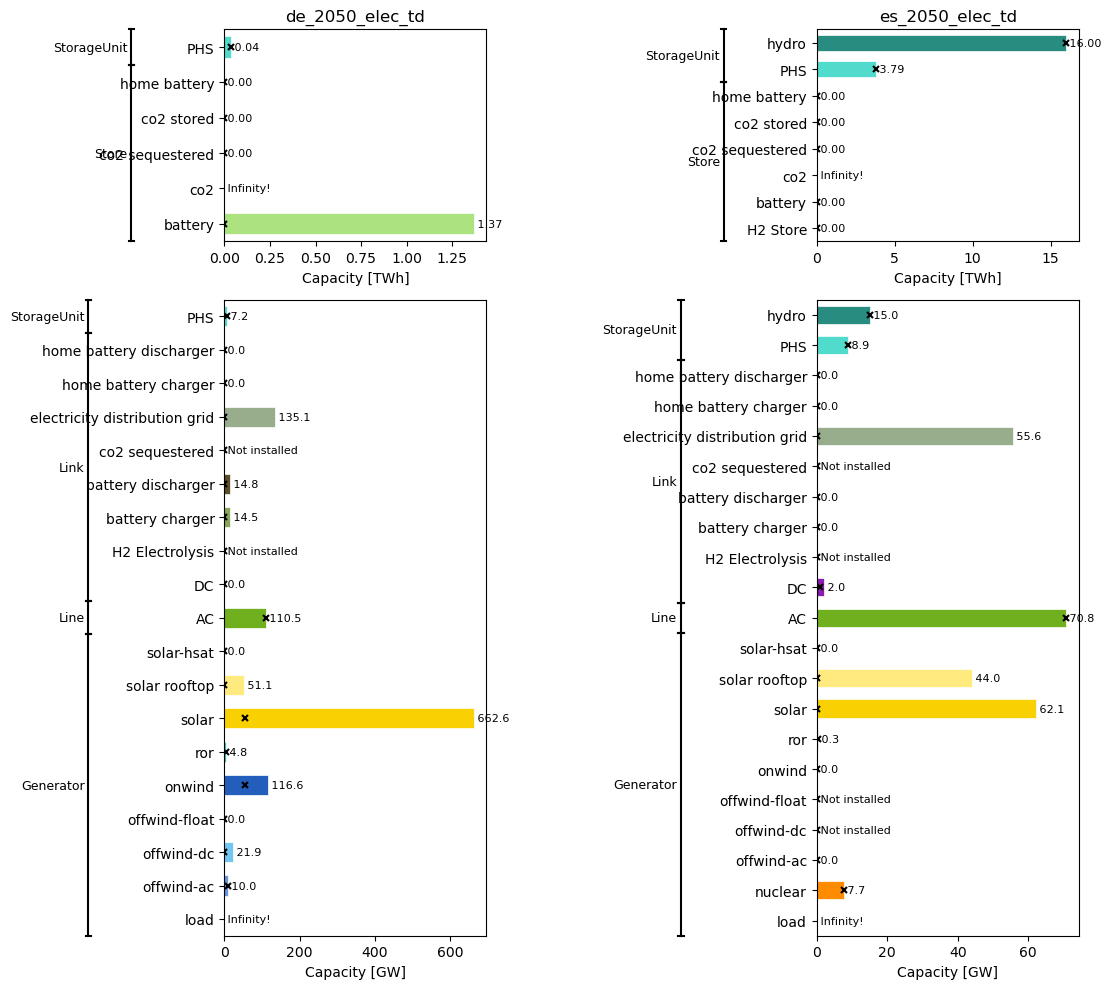

In [ ]:
runs = ["de_2050_elec_td", "es_2050_elec_td"]

fig, ax = plt.subplots(2, len(runs), figsize=(6 * len(runs), 10), gridspec_kw={"height_ratios": [1, 3]})

capacity_data = {}

for i, run in enumerate(runs):
    inst = stats[run].installed_capacity(drop_zero=False, nice_names=False, round=3, groupby="carrier", storage=True)
    opt = stats[run].optimal_capacity(drop_zero=False, nice_names=False, round=3, groupby="carrier", storage=True)
    energy_df = pd.DataFrame({"Installed Capacity": inst, "Optimal Capacity": opt})

    plot_comparison_barh(
        energy_df / 1e6,  # TWh
        ax[0, i],
        lower_col="Installed Capacity",
        upper_col="Optimal Capacity",
        tech_colors=tech_colors,
        xlabel="Capacity [TWh]",
        title=run,
        annotate_decimals=2,
        show_legend=False,
    )

    inst = stats[run].installed_capacity(drop_zero=False, nice_names=False, round=3, groupby="carrier").drop("Store")
    opt = stats[run].optimal_capacity(drop_zero=False, nice_names=False, round=3, groupby="carrier").drop("Store")
    power_df = pd.DataFrame({"Installed Capacity": inst, "Optimal Capacity": opt})

    plot_comparison_barh(
        power_df / 1e3,  # GW
        ax[1, i],
        lower_col="Installed Capacity",
        upper_col="Optimal Capacity",
        tech_colors=tech_colors,
        xlabel="Capacity [GW]",
        show_legend=False,
    )

plt.tight_layout()
plt.show()

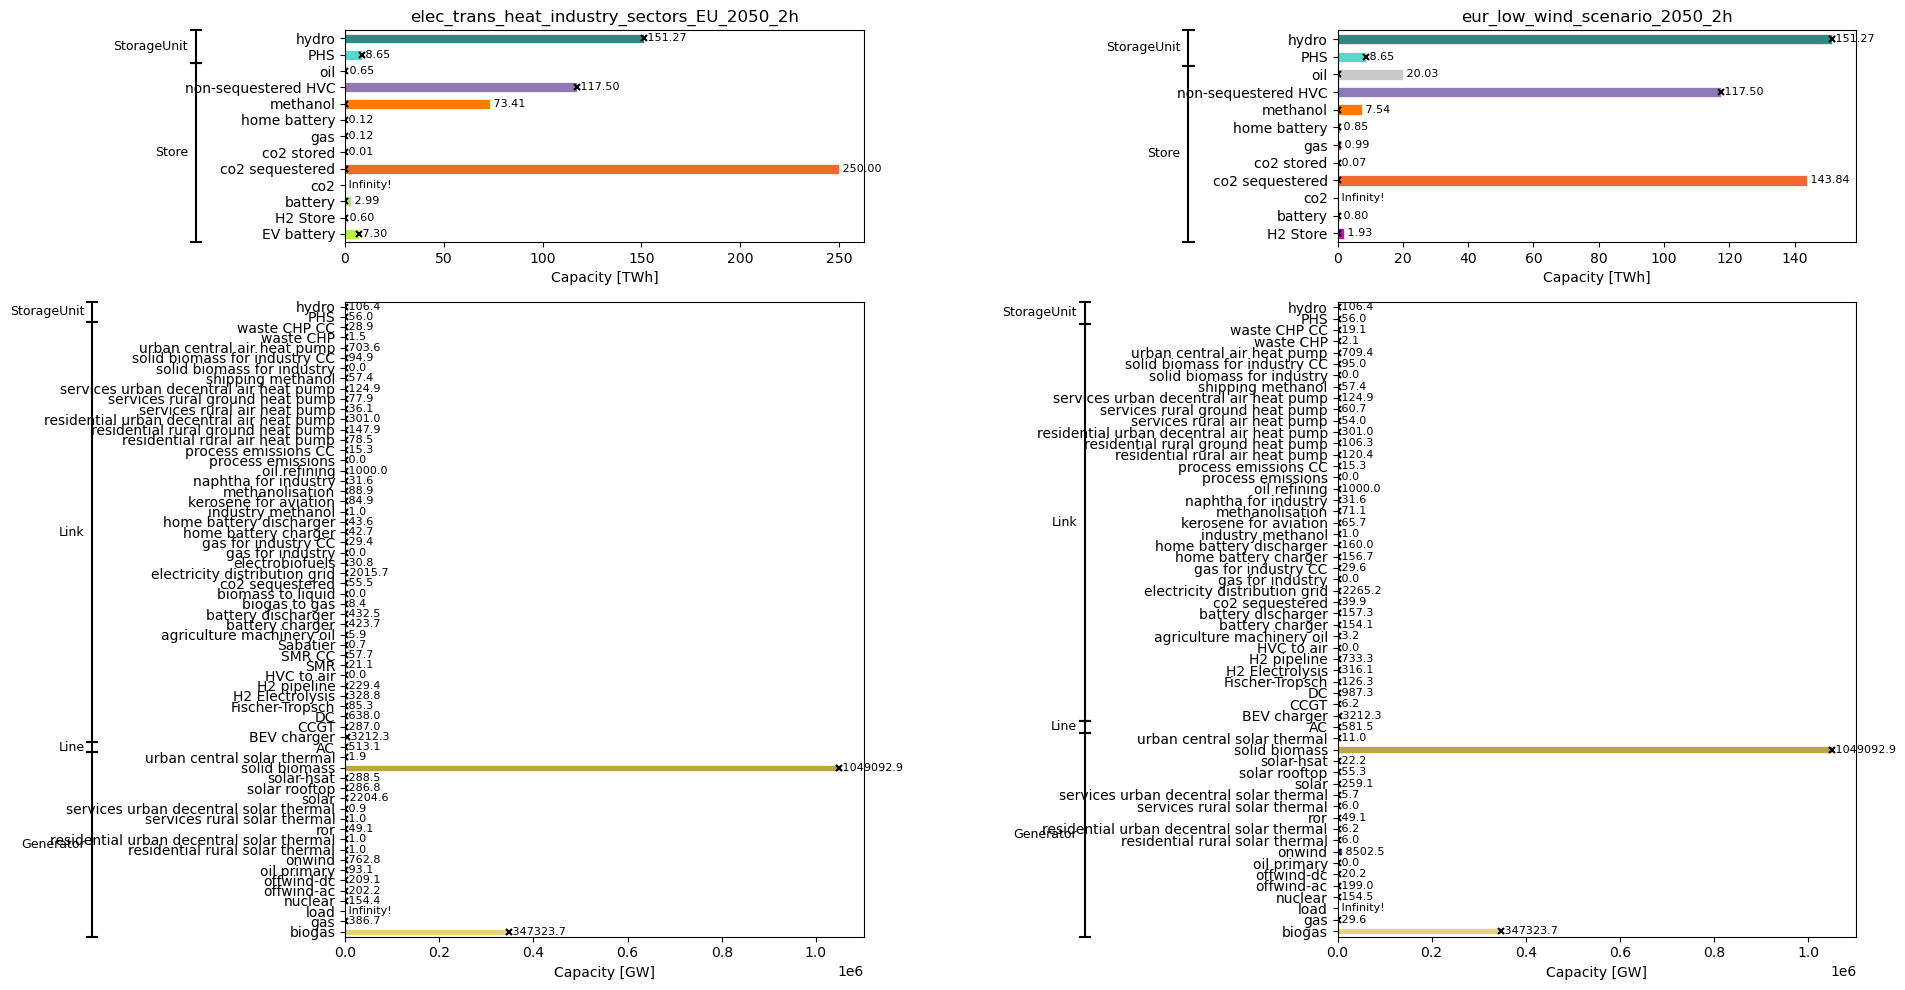

In [26]:
runs = [sample_2h, sample_low_wind_2h]

fig, ax = plt.subplots(2, len(runs), figsize=(10 * len(runs), 10), gridspec_kw={"height_ratios": [1, 3]})

capacity_data = {}

for i, run in enumerate(runs):
    inst = stats[run].installed_capacity(drop_zero=False, nice_names=False, round=3, groupby="carrier", storage=True)
    opt = stats[run].optimal_capacity(drop_zero=False, nice_names=False, round=3, groupby="carrier", storage=True)
    energy_df = pd.DataFrame({"Installed Capacity": inst, "Optimal Capacity": opt})

    plot_comparison_barh(
        energy_df / 1e6,  # TWh
        ax[0, i],
        lower_col="Installed Capacity",
        upper_col="Optimal Capacity",
        tech_colors=tech_colors,
        xlabel="Capacity [TWh]",
        title=run,
        annotate_decimals=2,
        show_legend=False,
    )

    inst = stats[run].installed_capacity(drop_zero=False, nice_names=False, round=3, groupby="carrier").drop("Store")
    opt = stats[run].optimal_capacity(drop_zero=False, nice_names=False, round=3, groupby="carrier").drop("Store")
    power_df = pd.DataFrame({"Installed Capacity": inst, "Optimal Capacity": opt})

    plot_comparison_barh(
        power_df / 1e3,  # GW
        ax[1, i],
        lower_col="Installed Capacity",
        upper_col="Optimal Capacity",
        tech_colors=tech_colors,
        xlabel="Capacity [GW]",
        show_legend=False,
    )

plt.tight_layout()
plt.show()

In [15]:
n[sample_base].statistics.optimal_capacity()

component    carrier                                                
Generator    Offshore Wind (AC)                                         9.008963e+03
             Offshore Wind (DC)                                         7.977593e+04
             Offshore Wind (Floating)                                   2.786990e+04
             Onshore Wind                                               1.434744e+05
             Run of River                                               1.647681e+04
             Solar                                                      1.381318e+06
             load                                                                inf
             nuclear                                                    1.520473e+05
Link         BEV charger                                                1.158773e+06
             battery charger                                            1.853094e+04
             battery discharger                                         1.891306e

In [22]:
print(n[sample_base].statistics.optimal_capacity()[n[sample_base].statistics.optimal_capacity().index.get_level_values('carrier').str.contains("Wind")].sum())
print(n[sample_mga_wind_min].statistics.optimal_capacity()[n[sample_mga_wind_min].statistics.optimal_capacity().index.get_level_values('carrier').str.contains("Wind")].sum())


260129.19738
44245.71806


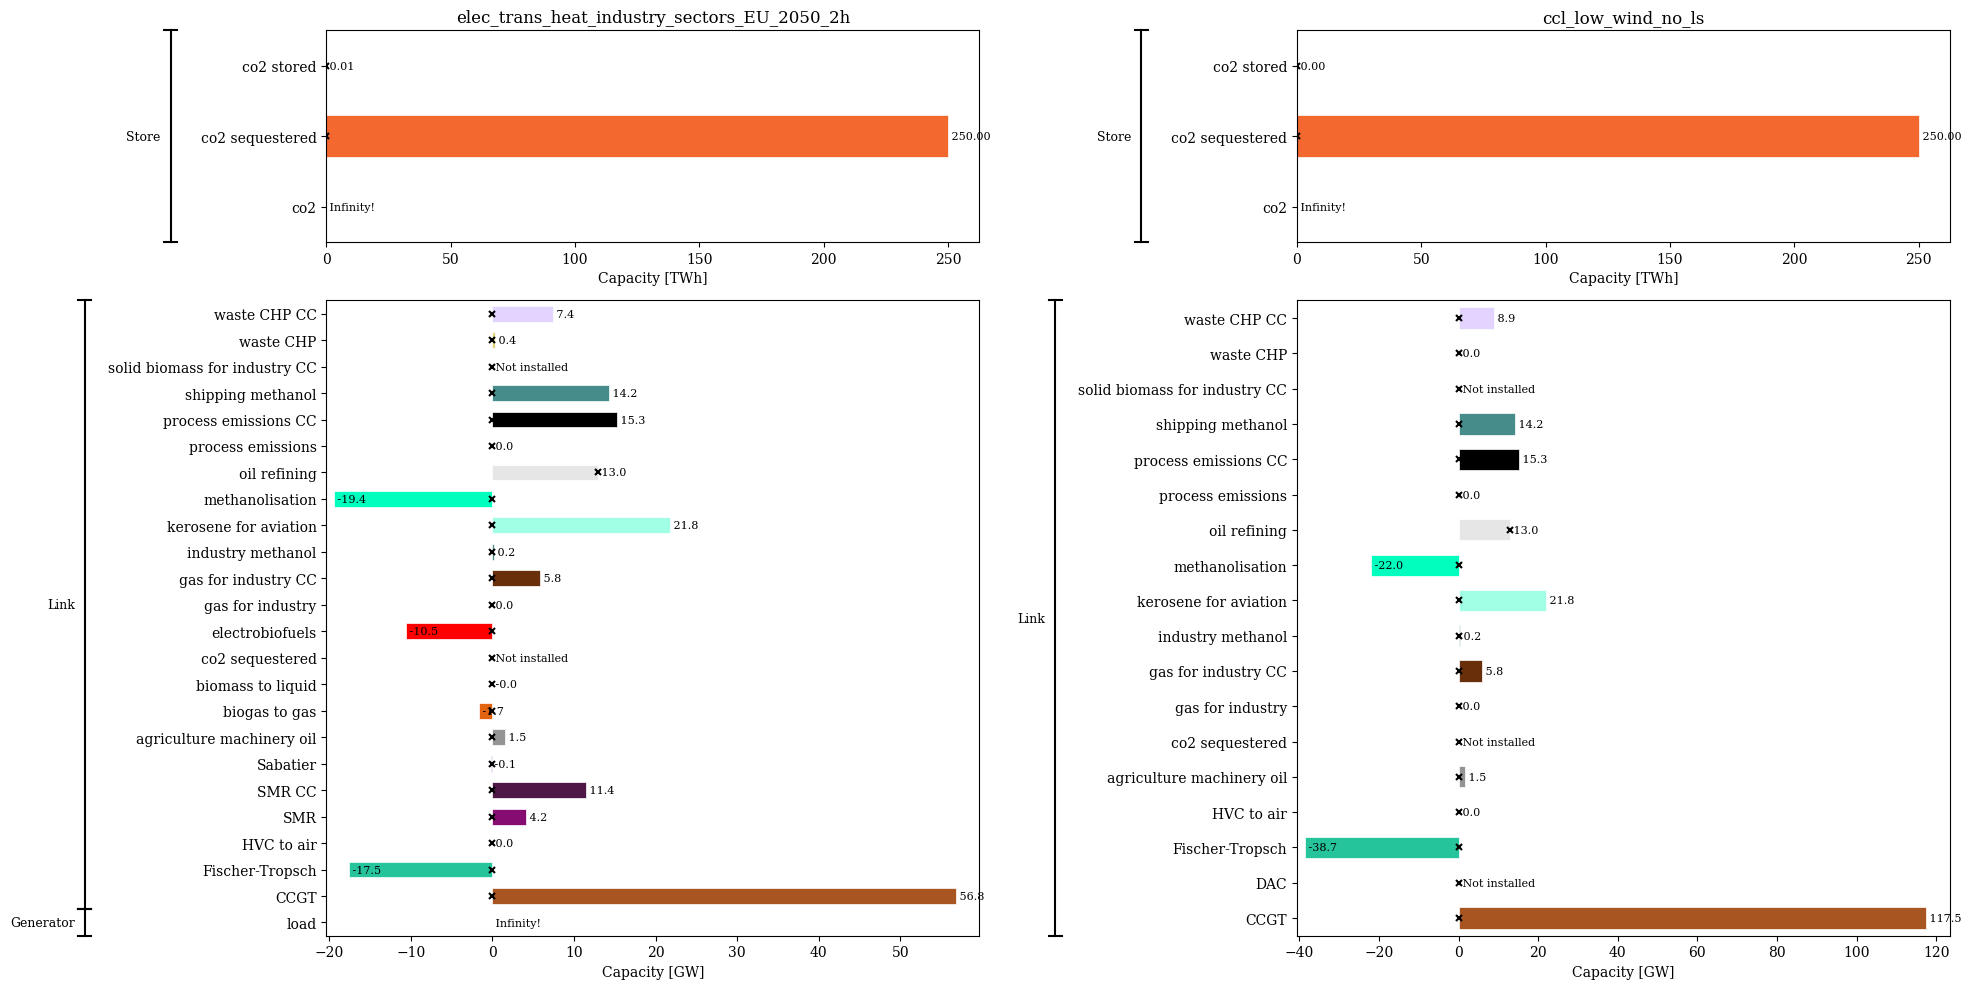

In [179]:
runs = [sample_new_2h_2050, sample_low_wind_no_ls]
co2_carriers = ['co2', 'co2 sequestered', 'co2 stored']

fig, ax = plt.subplots(2, len(runs), figsize=(10 * len(runs), 10), gridspec_kw={"height_ratios": [1, 3]})

capacity_data = {}

for i, run in enumerate(runs):
    inst = stats[run].installed_capacity(drop_zero=False, nice_names=False, round=3, groupby="carrier", storage=True, bus_carrier=co2_carriers)
    opt = stats[run].optimal_capacity(drop_zero=False, nice_names=False, round=3, groupby="carrier", storage=True, bus_carrier=co2_carriers)
    energy_df = pd.DataFrame({"Installed Capacity": inst, "Optimal Capacity": opt})

    plot_comparison_barh(
        energy_df / 1e6,  # TWh
        ax[0, i],
        lower_col="Installed Capacity",
        upper_col="Optimal Capacity",
        tech_colors=tech_colors,
        xlabel="Capacity [TWh]",
        title=run,
        annotate_decimals=2,
        show_legend=False,
    )

    inst = stats[run].installed_capacity(drop_zero=False, nice_names=False, round=3, groupby="carrier", bus_carrier=co2_carriers).drop("Store")
    opt = stats[run].optimal_capacity(drop_zero=False, nice_names=False, round=3, groupby="carrier", bus_carrier=co2_carriers).drop("Store")
    power_df = pd.DataFrame({"Installed Capacity": inst, "Optimal Capacity": opt})

    plot_comparison_barh(
        power_df / 1e3,  # GW
        ax[1, i],
        lower_col="Installed Capacity",
        upper_col="Optimal Capacity",
        tech_colors=tech_colors,
        xlabel="Capacity [GW]",
        show_legend=False,
    )

plt.tight_layout()
plt.show()

battery storage: 2.4 GWh

### Power capacities

In [211]:
# n[sample_base_2h].buses[n[sample_base_2h].buses['carrier']=='H2']

In [212]:
pd.set_option('display.max_rows', None)
# n[sample_base_2h].links[(n[sample_base_2h].links['bus0'].str.contains("H2")) | (n[sample_base_2h].links['bus1'].str.contains("H2")) | (n[sample_base_2h].links['bus2'].str.contains("H2"))]

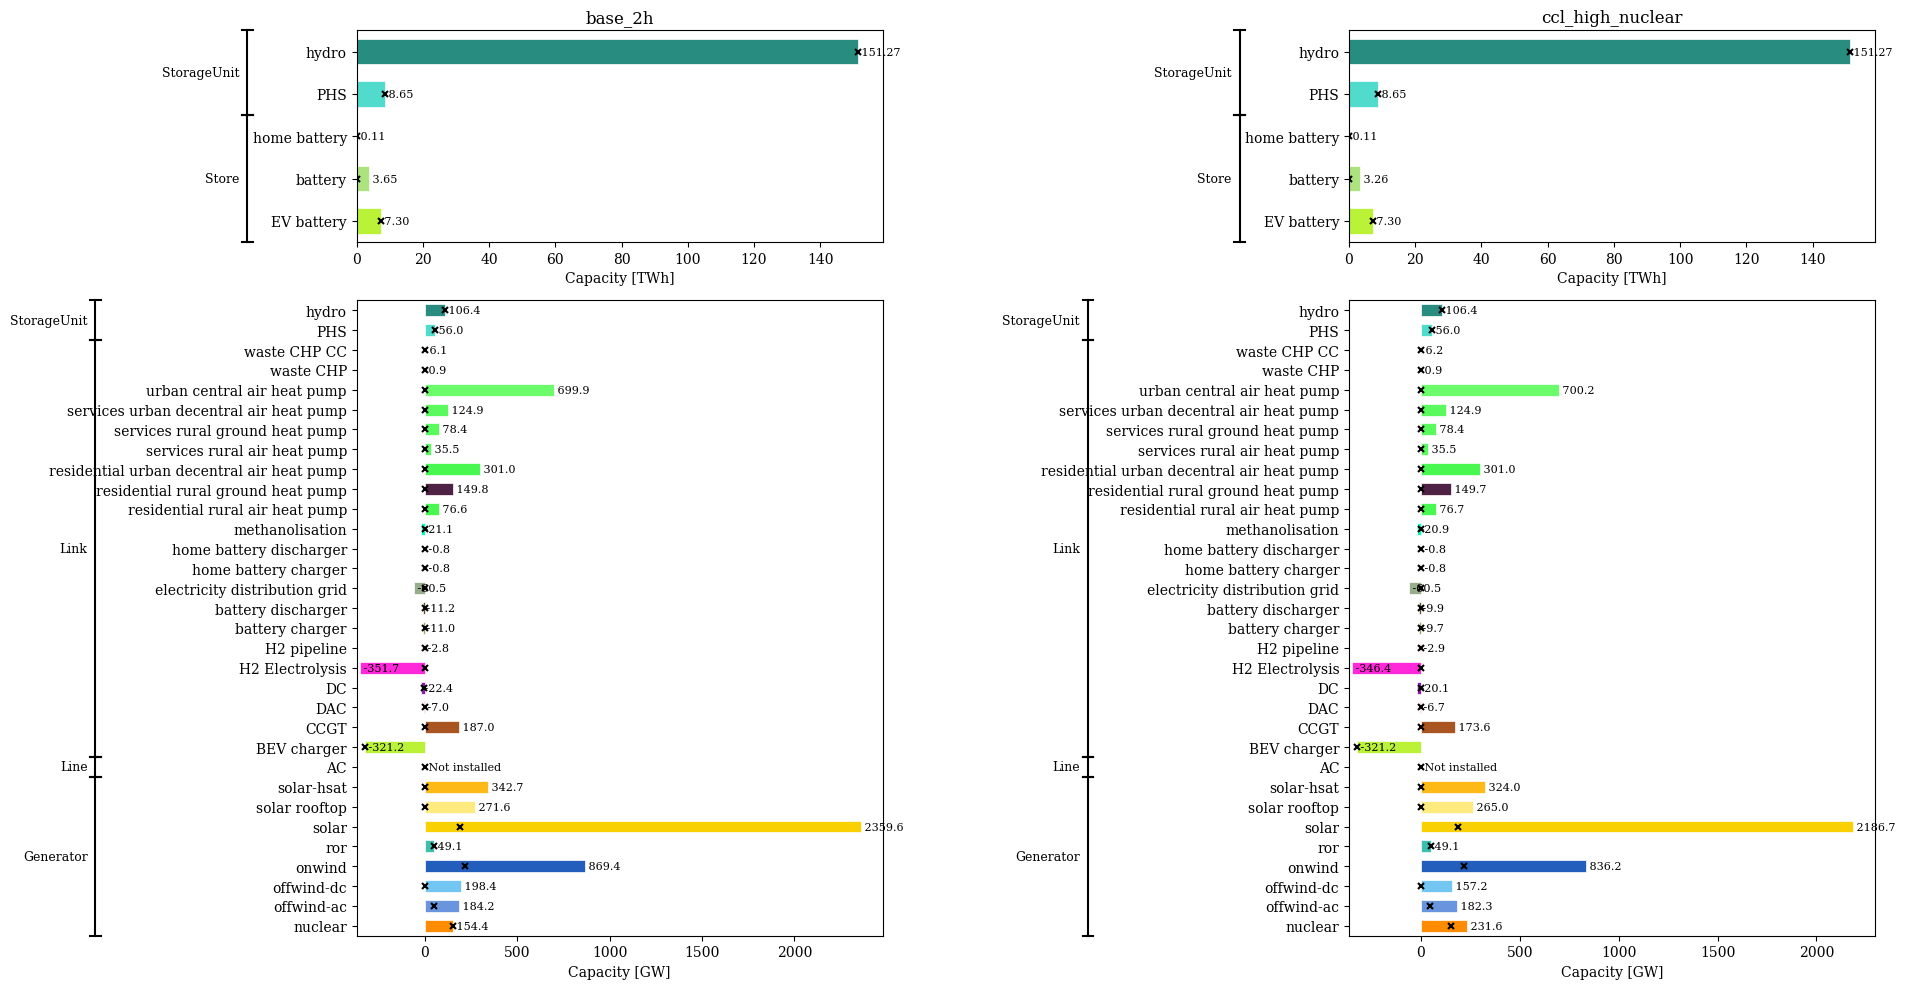

In [54]:
runs = [sample_base_2h, sample_high_nuclear]
elec_carriers = ['AC', 'DC', 'Battery Storage', 'home battery', 'low voltage', 'EV battery', 'Battery Storage', 'battery']

fig, ax = plt.subplots(2, len(runs), figsize=(10 * len(runs), 10), gridspec_kw={"height_ratios": [1, 3]})

capacity_data = {}

for i, run in enumerate(runs):
    inst = stats[run].installed_capacity(drop_zero=False, nice_names=False, round=3, groupby="carrier", storage=True, bus_carrier=elec_carriers)
    opt = stats[run].optimal_capacity(drop_zero=False, nice_names=False, round=3, groupby="carrier", storage=True, bus_carrier=elec_carriers)
    energy_df = pd.DataFrame({"Installed Capacity": inst, "Optimal Capacity": opt})

    plot_comparison_barh(
        energy_df / 1e6,  # TWh
        ax[0, i],
        lower_col="Installed Capacity",
        upper_col="Optimal Capacity",
        tech_colors=tech_colors,
        xlabel="Capacity [TWh]",
        title=run,
        annotate_decimals=2,
        show_legend=False,
    )

    inst = stats[run].installed_capacity(drop_zero=False, nice_names=False, round=3, groupby="carrier", bus_carrier=elec_carriers).drop("Store")
    opt = stats[run].optimal_capacity(drop_zero=False, nice_names=False, round=3, groupby="carrier", bus_carrier=elec_carriers).drop("Store")
    power_df = pd.DataFrame({"Installed Capacity": inst, "Optimal Capacity": opt})

    plot_comparison_barh(
        power_df / 1e3,  # GW
        ax[1, i],
        lower_col="Installed Capacity",
        upper_col="Optimal Capacity",
        tech_colors=tech_colors,
        xlabel="Capacity [GW]",
        show_legend=False,
    )

plt.tight_layout()
plt.show()

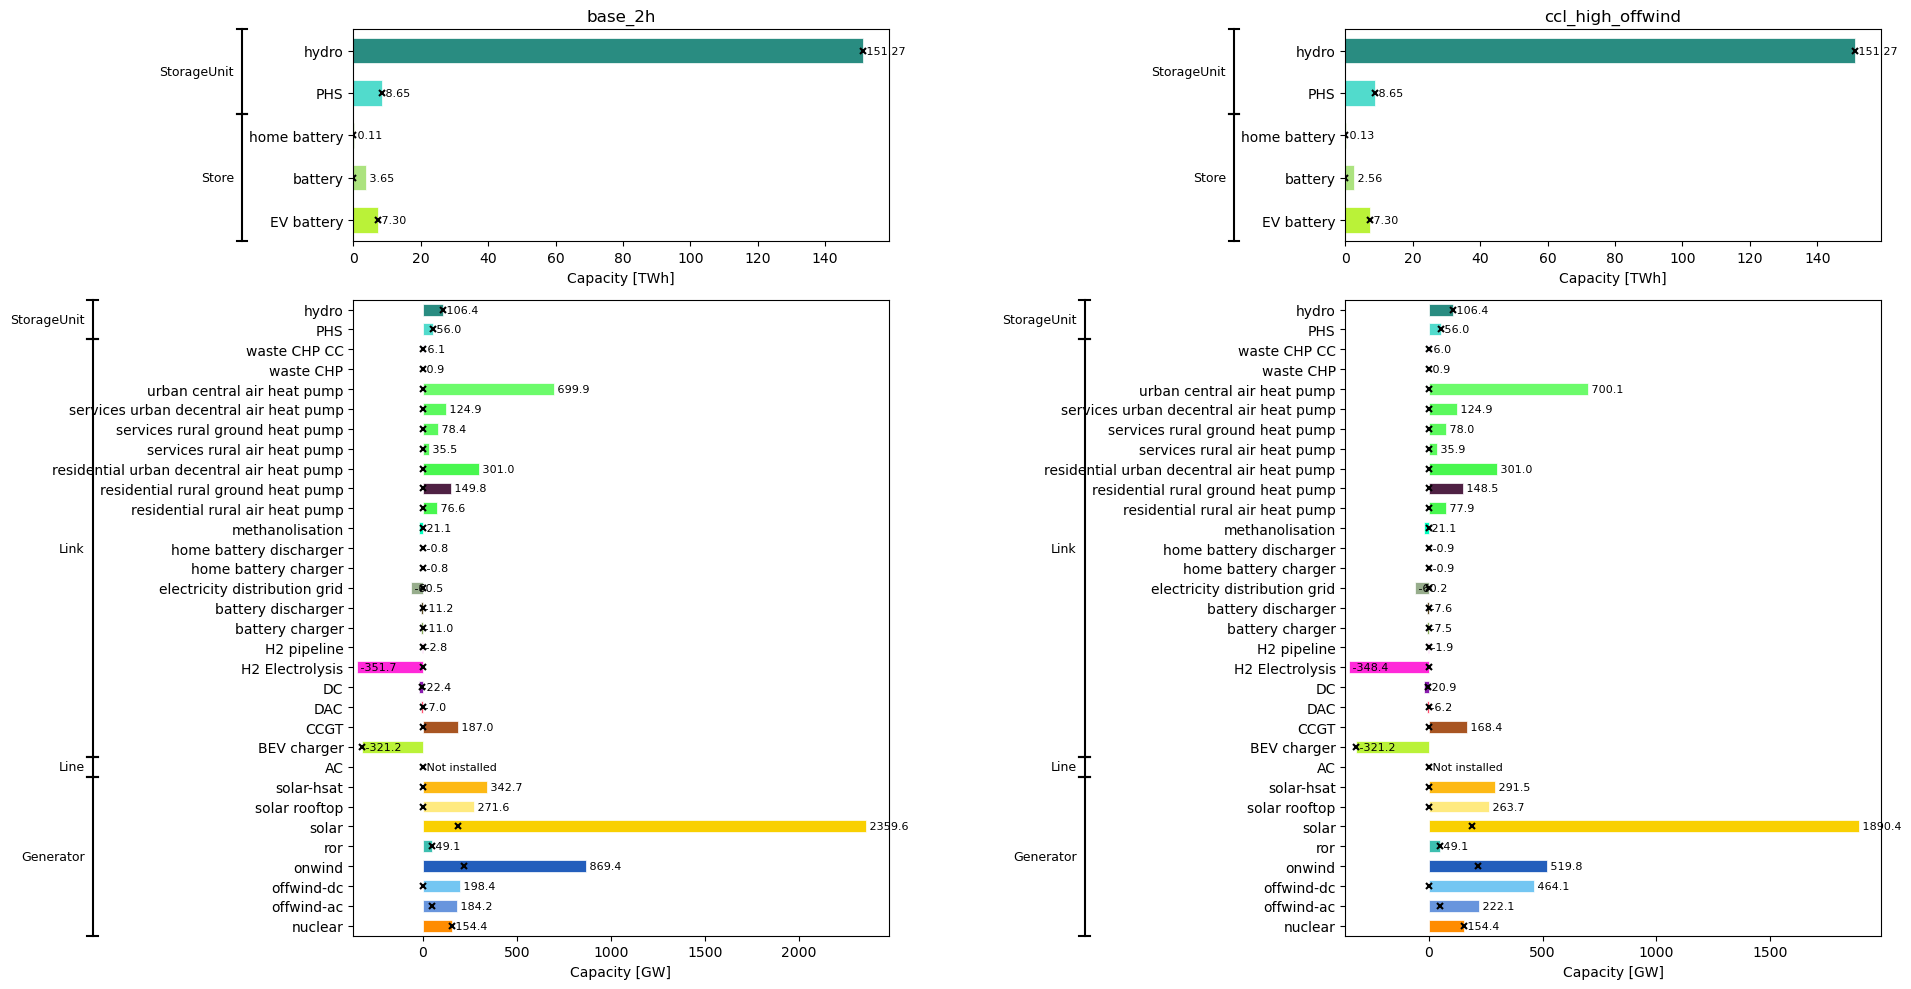

In [12]:
runs = [sample_base_2h, sample_high_offwind]
elec_carriers = ['AC', 'DC', 'Battery Storage', 'home battery', 'low voltage', 'EV battery', 'Battery Storage', 'battery']

fig, ax = plt.subplots(2, len(runs), figsize=(10 * len(runs), 10), gridspec_kw={"height_ratios": [1, 3]})

capacity_data = {}

for i, run in enumerate(runs):
    inst = stats[run].installed_capacity(drop_zero=False, nice_names=False, round=3, groupby="carrier", storage=True, bus_carrier=elec_carriers)
    opt = stats[run].optimal_capacity(drop_zero=False, nice_names=False, round=3, groupby="carrier", storage=True, bus_carrier=elec_carriers)
    energy_df = pd.DataFrame({"Installed Capacity": inst, "Optimal Capacity": opt})

    plot_comparison_barh(
        energy_df / 1e6,  # TWh
        ax[0, i],
        lower_col="Installed Capacity",
        upper_col="Optimal Capacity",
        tech_colors=tech_colors,
        xlabel="Capacity [TWh]",
        title=run,
        annotate_decimals=2,
        show_legend=False,
    )

    inst = stats[run].installed_capacity(drop_zero=False, nice_names=False, round=3, groupby="carrier", bus_carrier=elec_carriers).drop("Store")
    opt = stats[run].optimal_capacity(drop_zero=False, nice_names=False, round=3, groupby="carrier", bus_carrier=elec_carriers).drop("Store")
    power_df = pd.DataFrame({"Installed Capacity": inst, "Optimal Capacity": opt})

    plot_comparison_barh(
        power_df / 1e3,  # GW
        ax[1, i],
        lower_col="Installed Capacity",
        upper_col="Optimal Capacity",
        tech_colors=tech_colors,
        xlabel="Capacity [GW]",
        show_legend=False,
    )

plt.tight_layout()
plt.show()

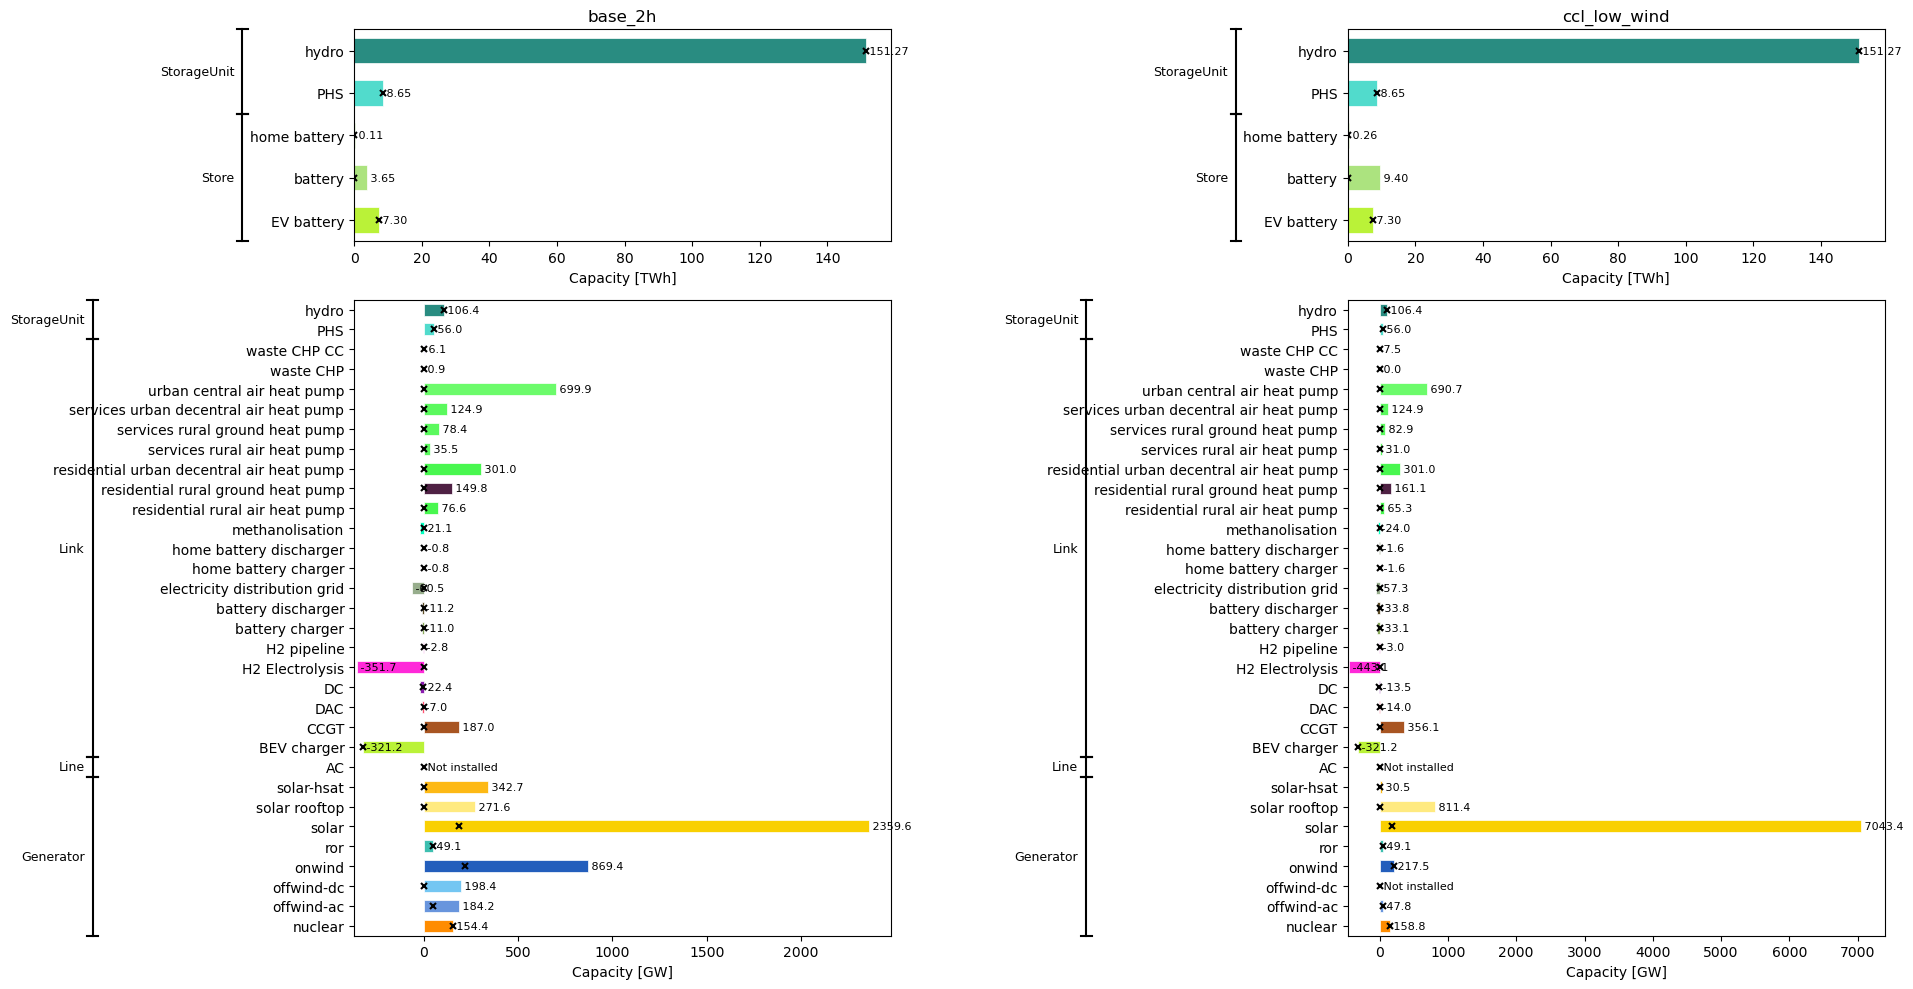

In [15]:
runs = [sample_base_2h, sample_low_wind]
elec_carriers = ['AC', 'DC', 'Battery Storage', 'home battery', 'low voltage', 'EV battery', 'Battery Storage', 'battery']

fig, ax = plt.subplots(2, len(runs), figsize=(10 * len(runs), 10), gridspec_kw={"height_ratios": [1, 3]})

capacity_data = {}

for i, run in enumerate(runs):
    inst = stats[run].installed_capacity(drop_zero=False, nice_names=False, round=3, groupby="carrier", storage=True, bus_carrier=elec_carriers)
    opt = stats[run].optimal_capacity(drop_zero=False, nice_names=False, round=3, groupby="carrier", storage=True, bus_carrier=elec_carriers)
    energy_df = pd.DataFrame({"Installed Capacity": inst, "Optimal Capacity": opt})

    plot_comparison_barh(
        energy_df / 1e6,  # TWh
        ax[0, i],
        lower_col="Installed Capacity",
        upper_col="Optimal Capacity",
        tech_colors=tech_colors,
        xlabel="Capacity [TWh]",
        title=run,
        annotate_decimals=2,
        show_legend=False,
    )

    inst = stats[run].installed_capacity(drop_zero=False, nice_names=False, round=3, groupby="carrier", bus_carrier=elec_carriers).drop("Store")
    opt = stats[run].optimal_capacity(drop_zero=False, nice_names=False, round=3, groupby="carrier", bus_carrier=elec_carriers).drop("Store")
    power_df = pd.DataFrame({"Installed Capacity": inst, "Optimal Capacity": opt})

    plot_comparison_barh(
        power_df / 1e3,  # GW
        ax[1, i],
        lower_col="Installed Capacity",
        upper_col="Optimal Capacity",
        tech_colors=tech_colors,
        xlabel="Capacity [GW]",
        show_legend=False,
    )

plt.tight_layout()
plt.show()

In [13]:
(198.4+184.2)*2

765.2

In [14]:
464.1+222.1

686.2

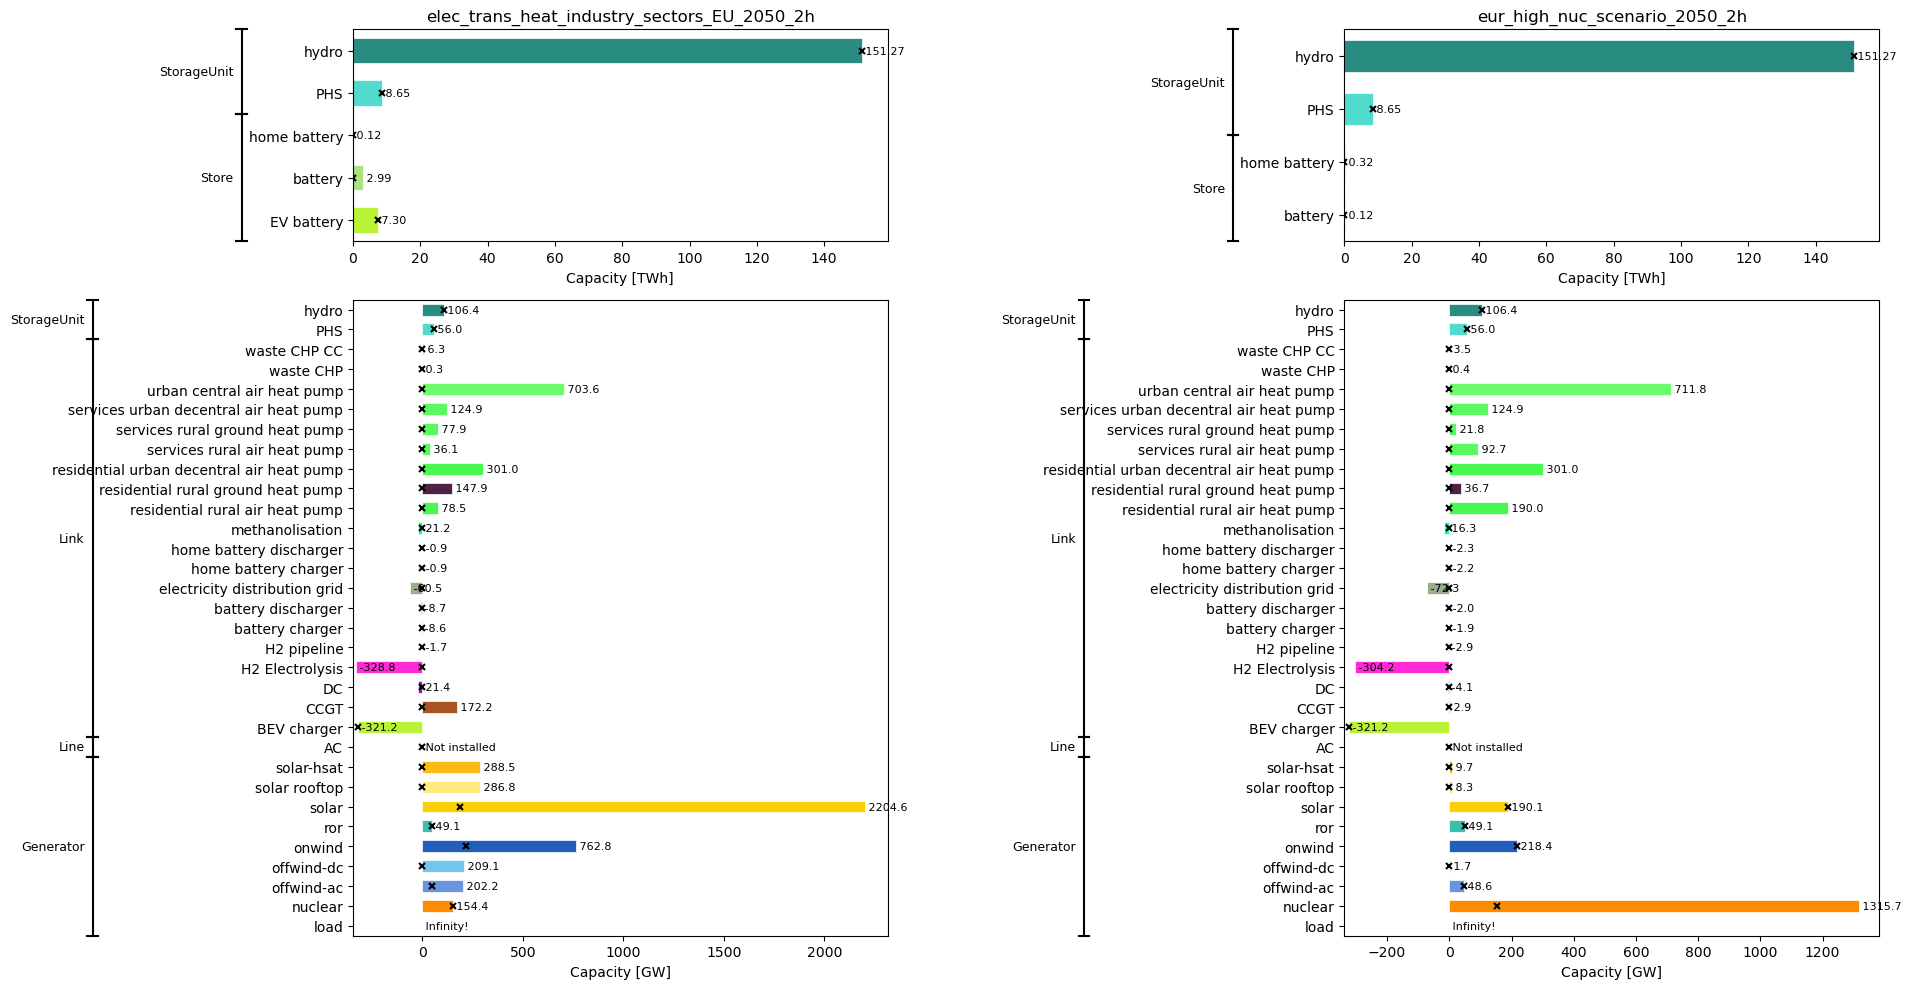

In [28]:
runs = [sample_2h, sample_high_nuc_2h]
elec_carriers = ['AC', 'DC', 'Battery Storage', 'home battery', 'low voltage', 'EV battery', 'Battery Storage', 'battery']

fig, ax = plt.subplots(2, len(runs), figsize=(10 * len(runs), 10), gridspec_kw={"height_ratios": [1, 3]})

capacity_data = {}

for i, run in enumerate(runs):
    inst = stats[run].installed_capacity(drop_zero=False, nice_names=False, round=3, groupby="carrier", storage=True, bus_carrier=elec_carriers)
    opt = stats[run].optimal_capacity(drop_zero=False, nice_names=False, round=3, groupby="carrier", storage=True, bus_carrier=elec_carriers)
    energy_df = pd.DataFrame({"Installed Capacity": inst, "Optimal Capacity": opt})

    plot_comparison_barh(
        energy_df / 1e6,  # TWh
        ax[0, i],
        lower_col="Installed Capacity",
        upper_col="Optimal Capacity",
        tech_colors=tech_colors,
        xlabel="Capacity [TWh]",
        title=run,
        annotate_decimals=2,
        show_legend=False,
    )

    inst = stats[run].installed_capacity(drop_zero=False, nice_names=False, round=3, groupby="carrier", bus_carrier=elec_carriers).drop("Store")
    opt = stats[run].optimal_capacity(drop_zero=False, nice_names=False, round=3, groupby="carrier", bus_carrier=elec_carriers).drop("Store")
    power_df = pd.DataFrame({"Installed Capacity": inst, "Optimal Capacity": opt})

    plot_comparison_barh(
        power_df / 1e3,  # GW
        ax[1, i],
        lower_col="Installed Capacity",
        upper_col="Optimal Capacity",
        tech_colors=tech_colors,
        xlabel="Capacity [GW]",
        show_legend=False,
    )

plt.tight_layout()
plt.show()

## Yearly energy generation

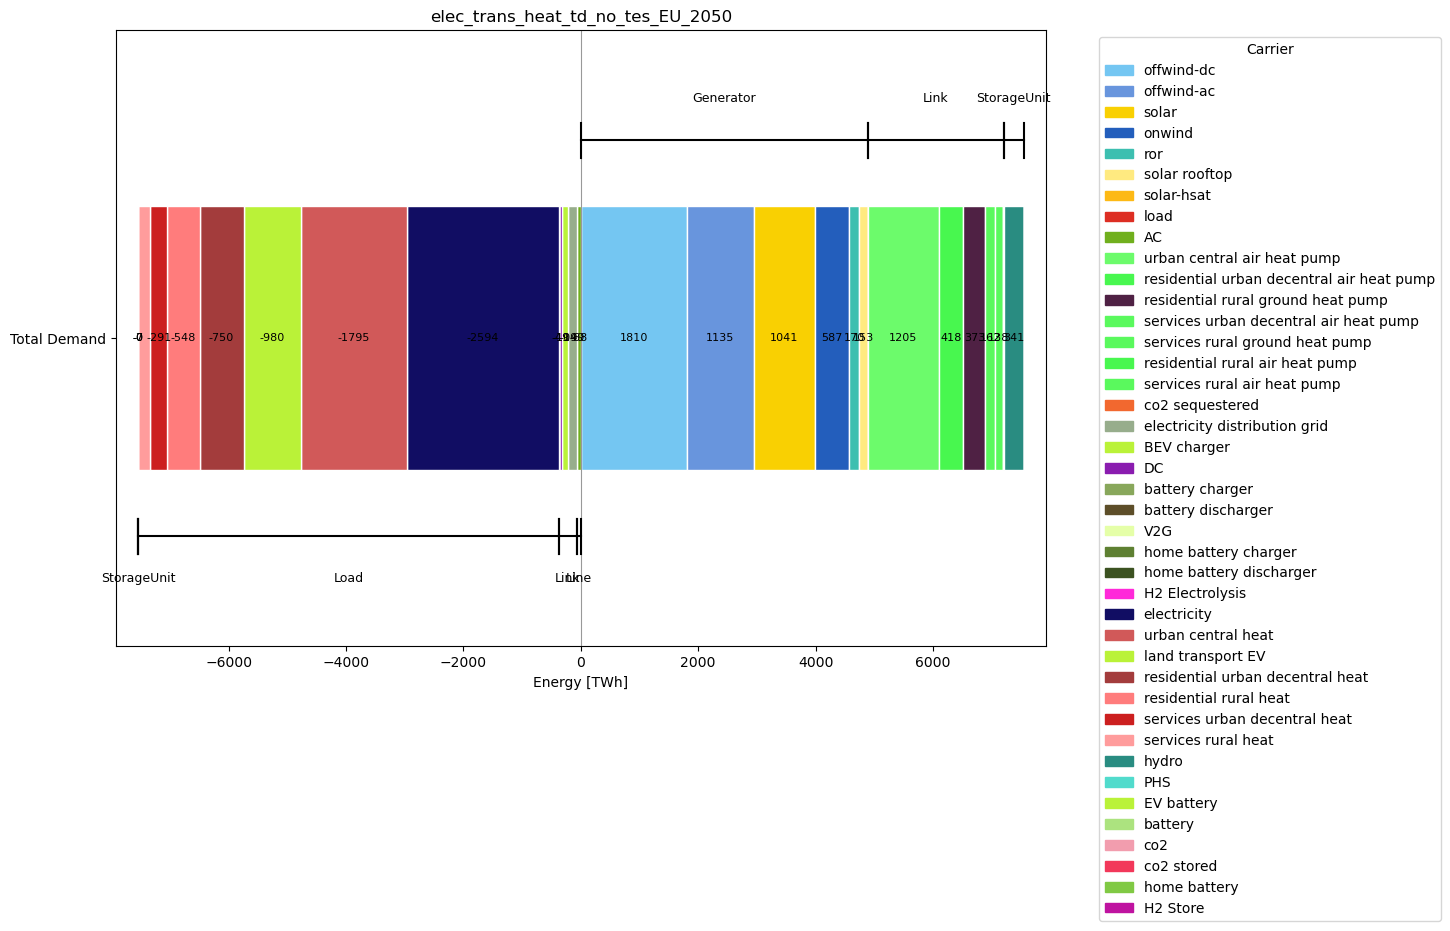

In [ ]:
runs = ["elec_trans_heat_td_no_tes_EU_2050"]
fig, ax = plt.subplots(1, len(runs), figsize=(12 * len(runs), 8))

eb = {}

for i, run in enumerate(runs):
    eb = stats[run].energy_balance(drop_zero=False, nice_names=False, round=3, groupby="carrier")
    # mask = eb.index.get_level_values(1).str.contains("heat")
    # eb_filt = eb[mask]

    stacked_barh_signed(
        eb / 1e6,  # TWh
        ax,
        tech_colors=tech_colors,
        y_label="Total Demand",
    )

    ax.set_title(f"{run}")
    ax.set_xlabel("Energy [TWh]")

plt.show()


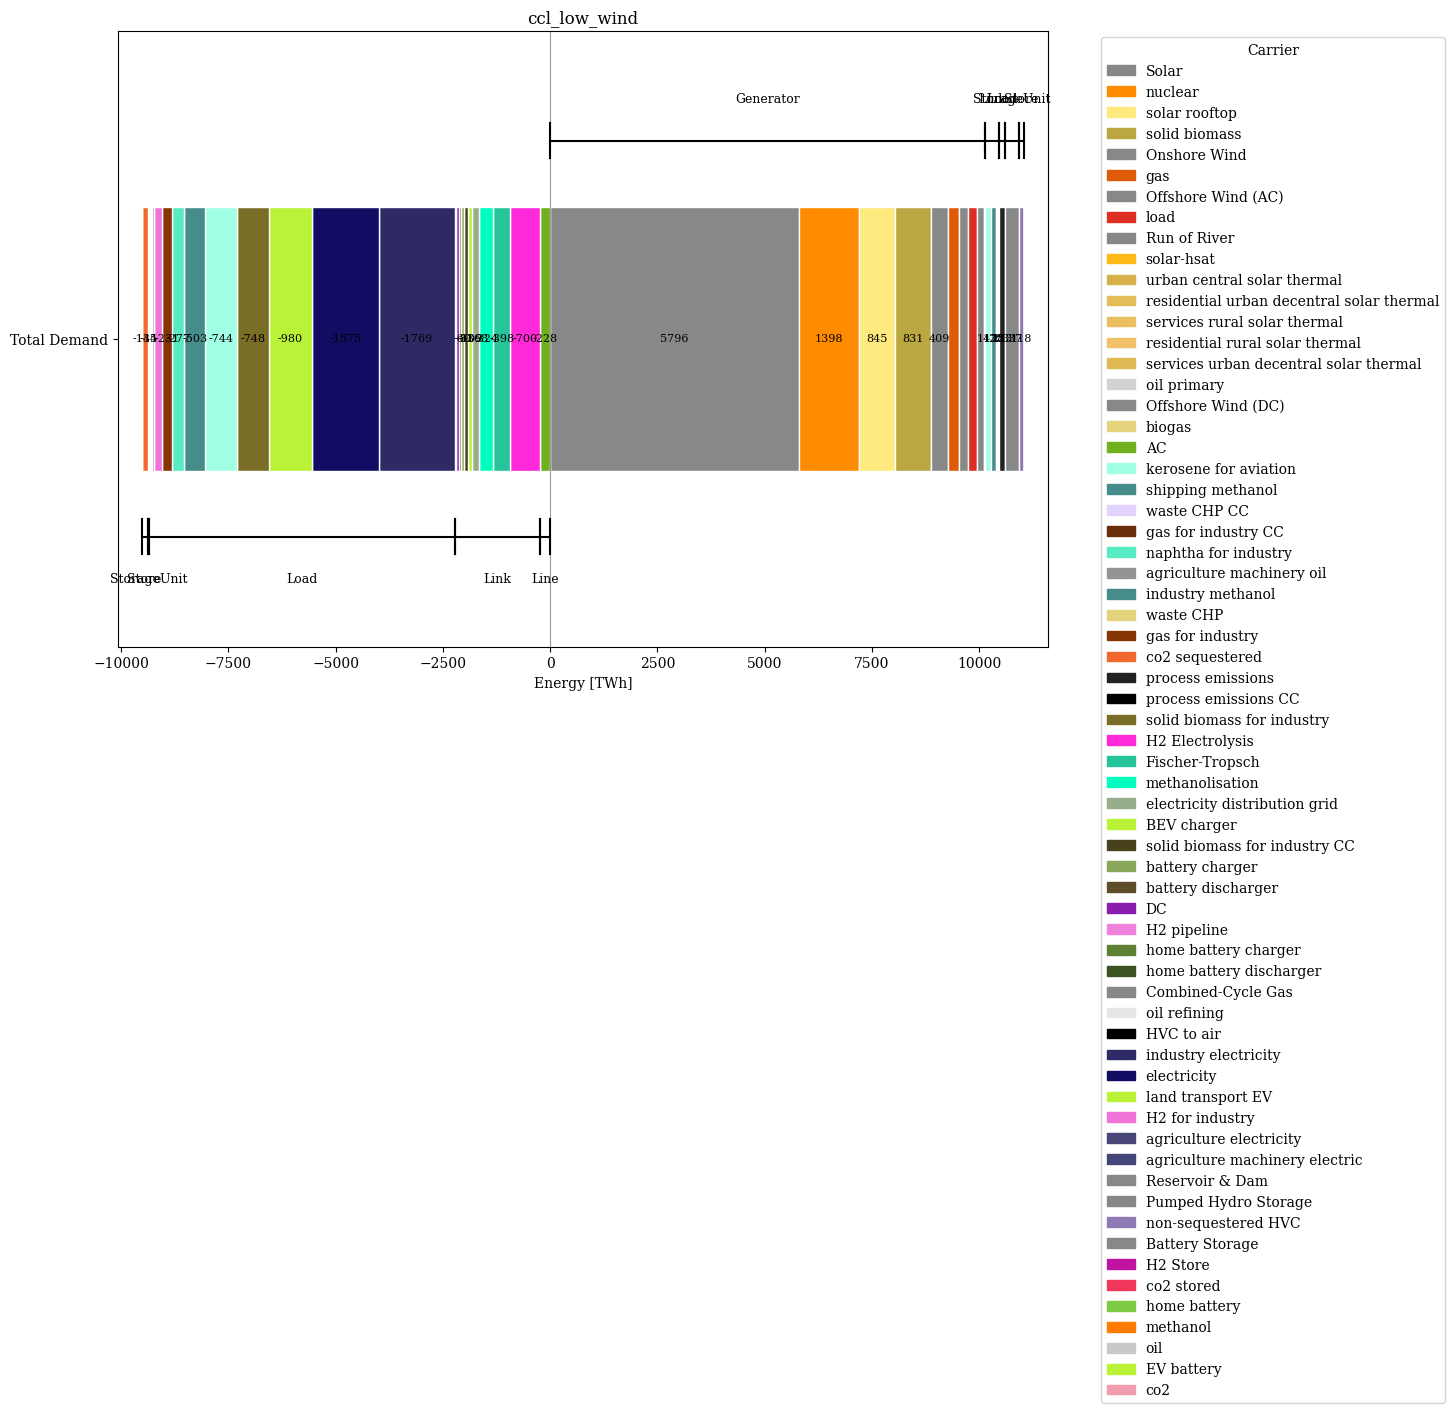

In [176]:
runs = [sample_low_wind]
fig, ax = plt.subplots(1, len(runs), figsize=(12 * len(runs), 8))

eb = {}

for i, run in enumerate(runs):
    eb = stats[run].energy_balance(drop_zero=False, nice_names=True, round=3, groupby="carrier")
    mask = eb.index.get_level_values(1).str.contains("heat")
    eb_filt = eb[~mask]

    stacked_barh_signed(
        eb_filt / 1e6,  # TWh
        ax,
        tech_colors=tech_colors,
        y_label="Total Demand",
    )

    ax.set_title(f"{run}")
    ax.set_xlabel("Energy [TWh]")

plt.show()

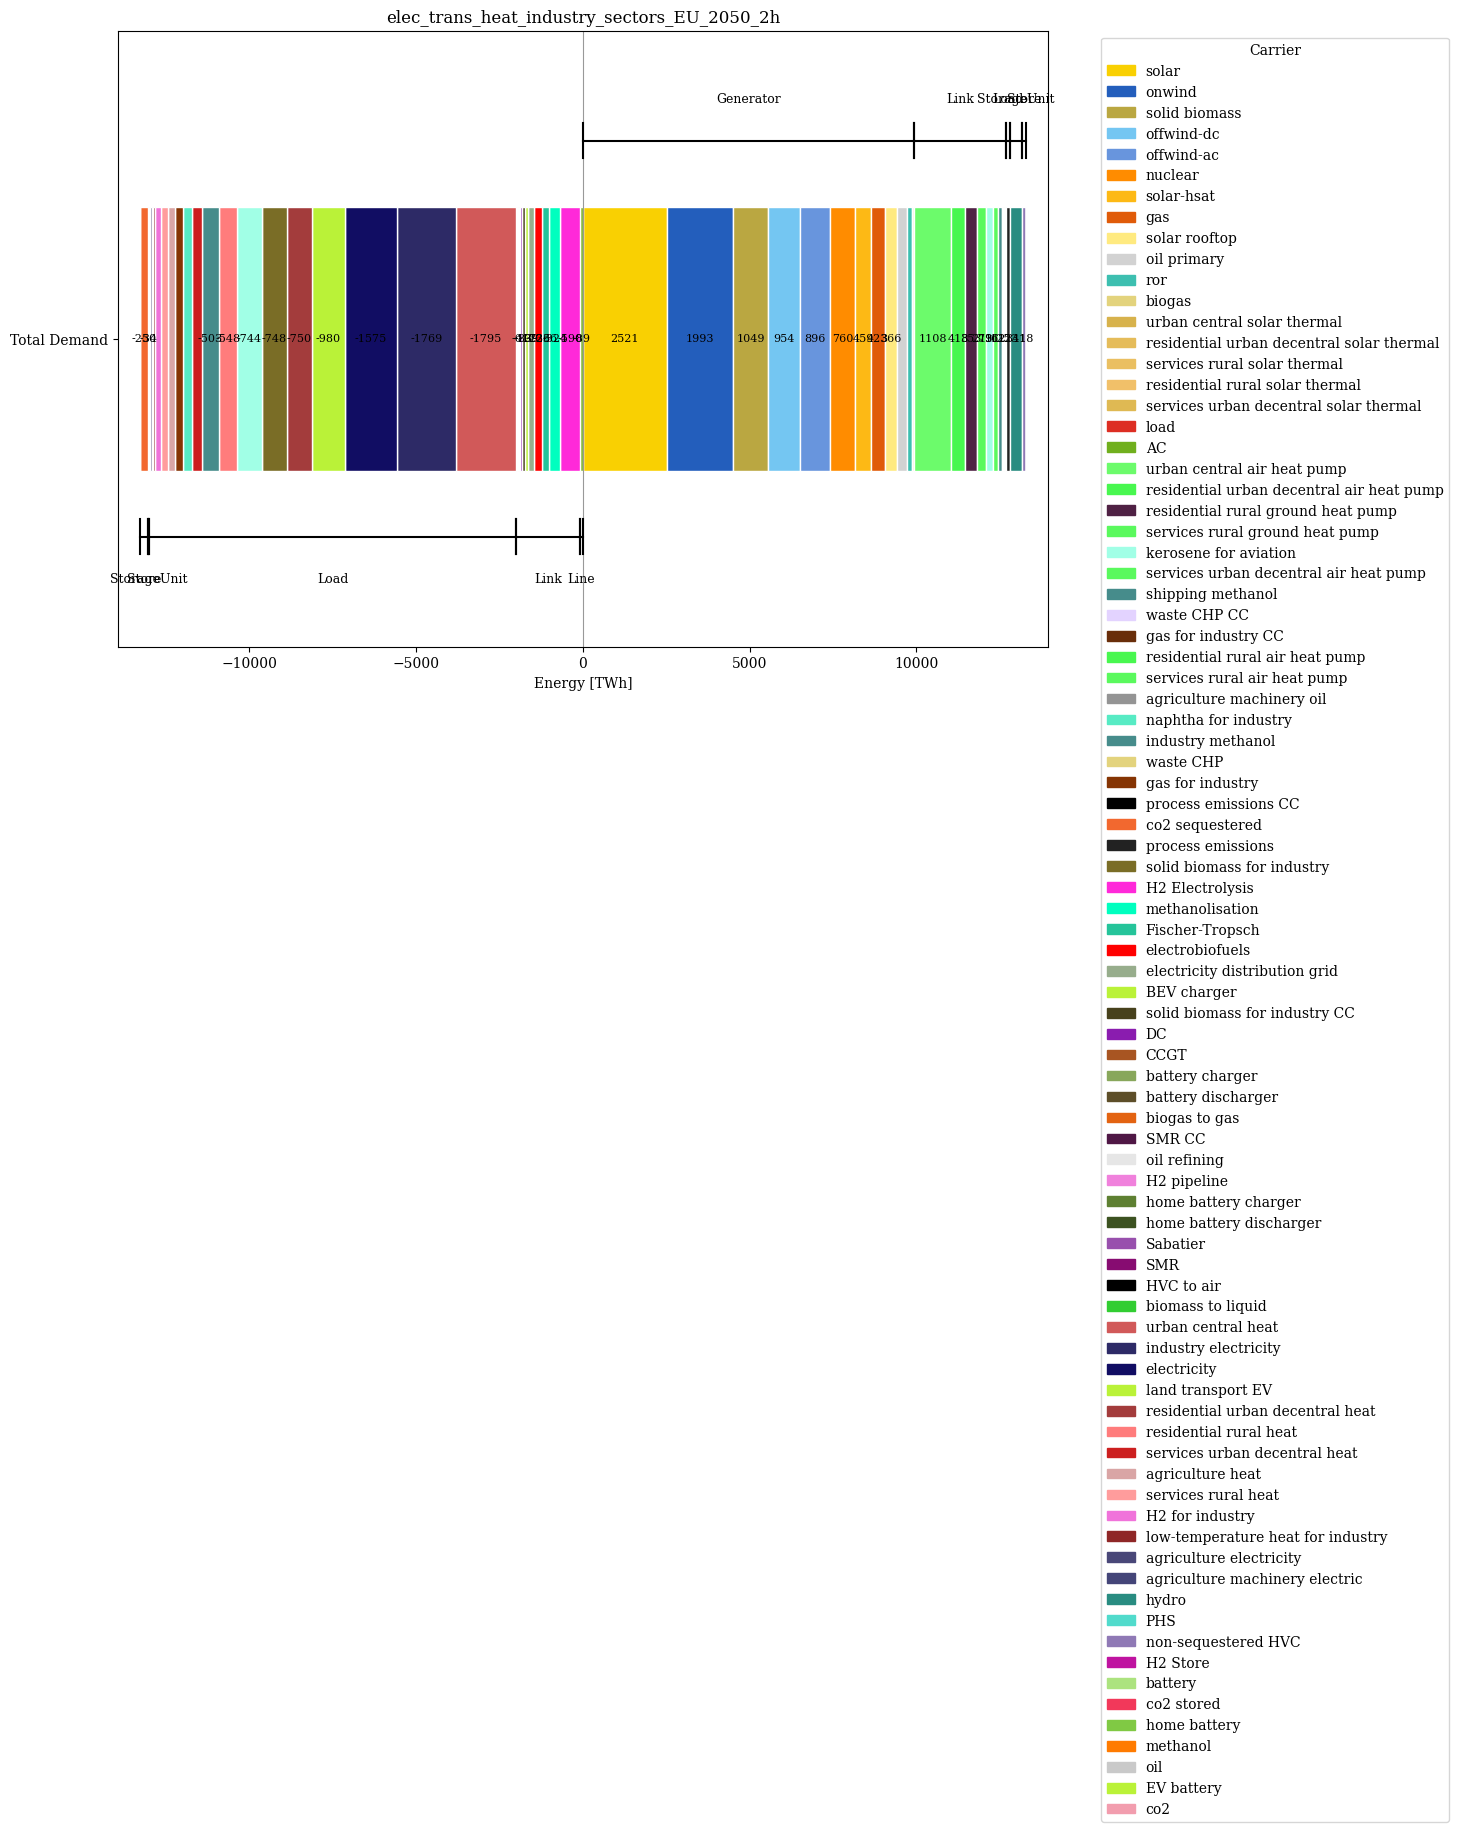

In [169]:
runs = [sample_new_2h_2050]
fig, ax = plt.subplots(1, len(runs), figsize=(12 * len(runs), 8))

eb = {}

for i, run in enumerate(runs):
    eb = stats[run].energy_balance(drop_zero=False, nice_names=False, round=3, groupby="carrier")
    # mask = eb.index.get_level_values(1).str.contains("heat")
    # eb_filt = eb[mask]

    stacked_barh_signed(
        eb / 1e6,  # TWh
        ax,
        tech_colors=tech_colors,
        y_label="Total Demand",
    )

    ax.set_title(f"{run}")
    ax.set_xlabel("Energy [TWh]")

plt.show()

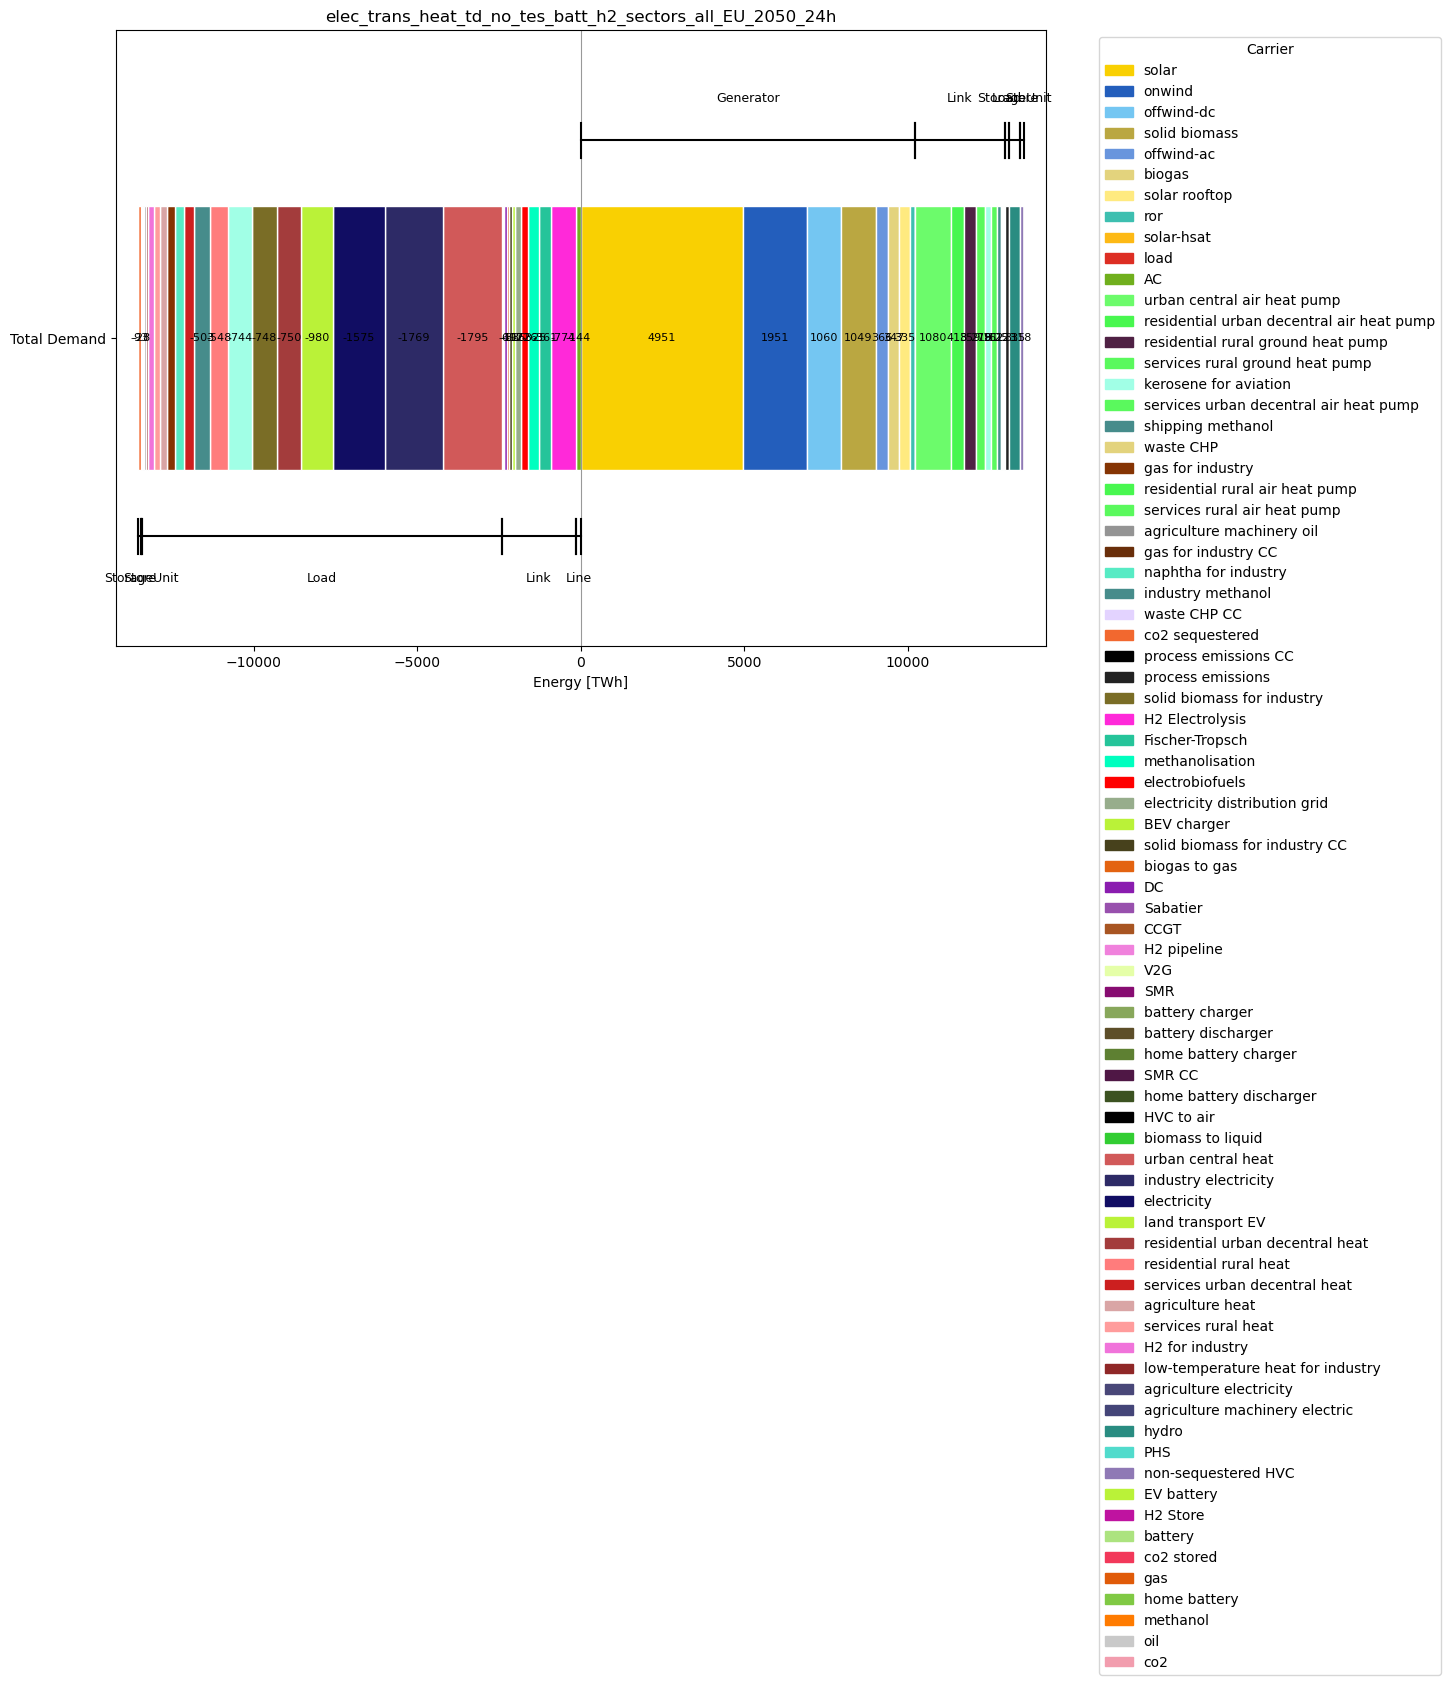

In [ ]:
runs = ["elec_trans_heat_td_no_tes_batt_h2_sectors_all_EU_2050_24h"]
fig, ax = plt.subplots(1, len(runs), figsize=(12 * len(runs), 8))

eb = {}

for i, run in enumerate(runs):
    eb = stats[run].energy_balance(drop_zero=False, nice_names=False, round=3, groupby="carrier")
    # mask = eb.index.get_level_values(1).str.contains("heat")
    # eb_filt = eb[mask]

    stacked_barh_signed(
        eb / 1e6,  # TWh
        ax,
        tech_colors=tech_colors,
        y_label="Total Demand",
    )

    ax.set_title(f"{run}")
    ax.set_xlabel("Energy [TWh]")

plt.show()


## Mineral intensities

In [12]:
def mineral_supply_comparison(networks, network, minerals, scenario, ):
    network_key = sample_new_2h_2050
    time_diff = 24
    df_merged, totals_Mt = compute_mineral_usage(network_key, n, rare_earths, "Market share current", mineral_intensities, tech_scenarios)
    total_REEs = pd.Series(data = {'REE': totals_Mt.sum()}, index=['REE'])
    total_REEs_yearly = total_REEs/time_diff


    # s = expanded_capacities[minerals].sum()   # example Series, index = mineral names
    ax = total_REEs_yearly.plot.bar(figsize=(10,5), color="C0")
    ax.set_ylabel("Amount (Mt)")        # change units/label as needed
    ax.set_xlabel("")              # remove x-label if redundant
    ax.set_title(f"Mineral use in scenario: {network_key}")

    supply_pce = mineral_alloc_tidy[mineral_alloc_tidy['Method'] == 'Per capita share corrected for energy use'].set_index('metal')['Supply (Mt)']
    supply_gdp = mineral_alloc_tidy[mineral_alloc_tidy['Method'] == 'GDP share'].set_index('metal')['Supply (Mt)']
    supply_pc = mineral_alloc_tidy[mineral_alloc_tidy['Method'] == 'Per capita share'].set_index('metal')['Supply (Mt)']

    # read current tick positions & labels from the existing axis `ax`
    positions = ax.get_xticks()
    labels = [t.get_text() for t in ax.get_xticklabels()]

    xs = []
    ys = []

    xs1 = []
    ys1 = []

    xs2 = []
    ys2 = []

    xs6 = []
    ys6 = []
    bottom = []

    for x_pos, lab in zip(positions, labels):
        print(lab)
        if lab in supply_pce.index:
            xs.append(x_pos)
            ys.append(supply_pce.loc[lab])
        if lab in supply_gdp.index:
            xs1.append(x_pos)
            ys1.append(supply_gdp.loc[lab])
        if lab in supply_pc.index:
            xs2.append(x_pos)
            ys2.append(supply_pc.loc[lab])
        if lab in non_energy_demand.index: 
            print("test")
            xs6.append(x_pos)
            ys6.append(non_energy_demand.loc[lab]["Value entso-e (Mt)"])
            bottom.append(total_REEs_yearly.loc[lab])

    ax.bar(xs6, ys6, bottom = bottom, label="Demand from other sectors", color="red", width=0.5)

    # plot points on top of the bars
    ax.scatter(xs1, ys1, color='red', marker='D', s=80, edgecolor='k', zorder=10, label='GDP share')
    ax.scatter(xs2, ys2, color='blue', marker='D', s=80, edgecolor='k', zorder=10, label='Per capita share')
    ax.scatter(xs, ys, color='C2', marker='D', s=80, edgecolor='k', zorder=10, label='Per capita supply adjusted for current energy use')


    # optional: annotate numeric values
    for x, y in zip(xs, ys):
        ax.text(x, y, f"{y:.3f}", ha='center', va='bottom', fontsize=8)

    for x, y in zip(xs1, ys1):
        ax.text(x, y, f"{y:.3f}", ha='center', va='bottom', fontsize=8)

    for x, y in zip(xs2, ys2):
        ax.text(x, y, f"{y:.3f}", ha='center', va='bottom', fontsize=8)


    plt.legend(loc="upper right")
    plt.tight_layout()
    plt.show()

Compare overall mineral usage

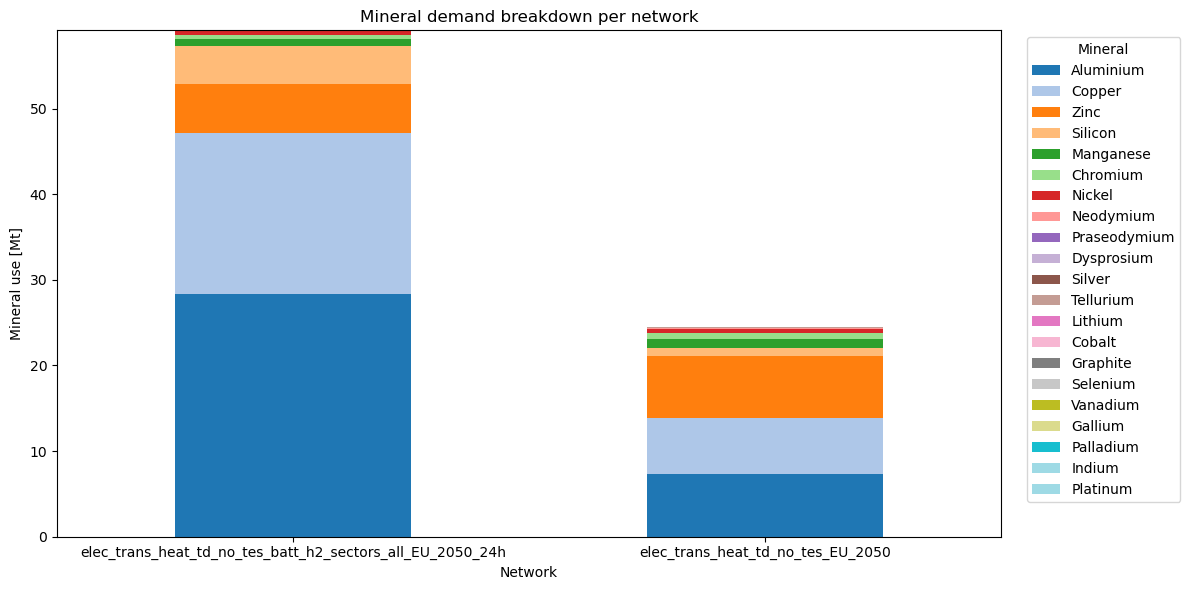

(              elec_trans_heat_td_no_tes_batt_h2_sectors_all_EU_2050_24h  \
 Aluminium                                          2.837834e+01           
 Copper                                             1.879615e+01           
 Zinc                                               5.746403e+00           
 Silicon                                            4.407310e+00           
 Manganese                                          8.223272e-01           
 Chromium                                           5.316603e-01           
 Nickel                                             3.861580e-01           
 Neodymium                                          7.511909e-02           
 Praseodymium                                       1.245959e-02           
 Dysprosium                                         7.865972e-03           
 Silver                                             4.964023e-03           
 Tellurium                                          1.224768e-03           
 Lithium    

In [225]:
compare_networks(["elec_trans_heat_td_no_tes_batt_h2_sectors_all_EU_2050_24h", "elec_trans_heat_td_no_tes_EU_2050"], n, minerals, tech_scenarios, mineral_intensities)

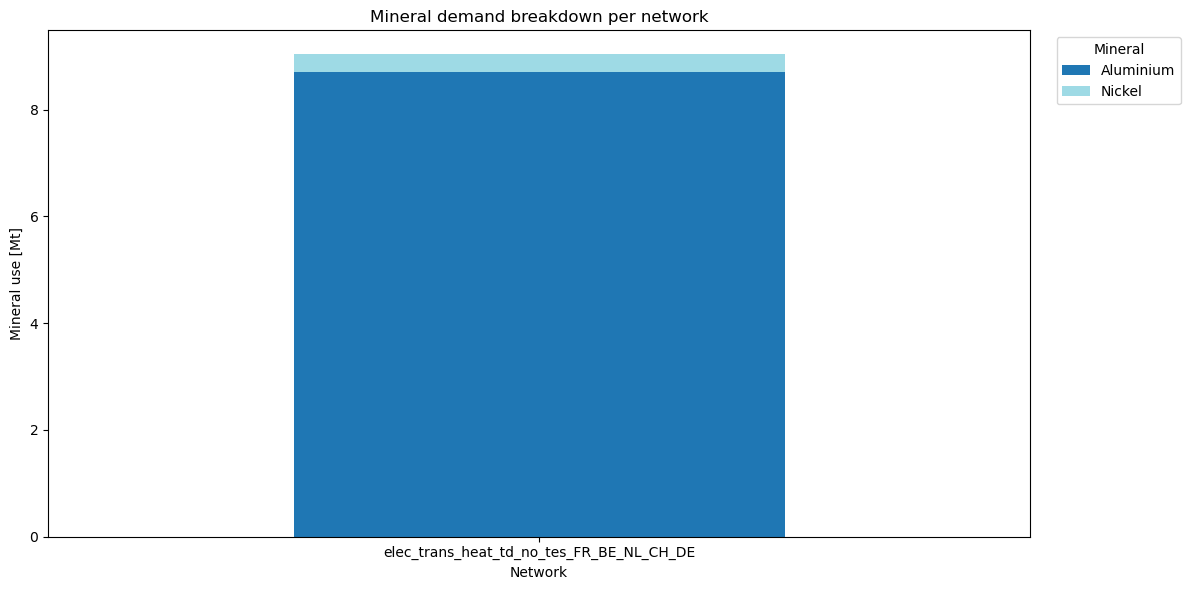

(           elec_trans_heat_td_no_tes_FR_BE_NL_CH_DE
 Aluminium                                  8.714465
 Nickel                                     0.322852,
 {'elec_trans_heat_td_no_tes_FR_BE_NL_CH_DE':     component             carrier  carrier capacity    PyPSA technology  \
  0   Generator  Offshore Wind (AC)      9.010338e+03  Offshore Wind (AC)   
  1   Generator  Offshore Wind (AC)      9.010338e+03  Offshore Wind (AC)   
  2   Generator  Offshore Wind (AC)      9.010338e+03  Offshore Wind (AC)   
  3   Generator  Offshore Wind (AC)      9.010338e+03  Offshore Wind (AC)   
  4   Generator  Offshore Wind (DC)      3.271383e+05  Offshore Wind (DC)   
  5   Generator  Offshore Wind (DC)      3.271383e+05  Offshore Wind (DC)   
  6   Generator  Offshore Wind (DC)      3.271383e+05  Offshore Wind (DC)   
  7   Generator  Offshore Wind (DC)      3.271383e+05  Offshore Wind (DC)   
  8   Generator        Onshore Wind      5.479940e+05        Onshore Wind   
  9   Generator        Ons

In [ ]:
compare_networks(["elec_trans_heat_td_no_tes_FR_BE_NL_CH_DE"], n, ["Nickel", "Aluminium"], tech_scenarios, mineral_intensities)

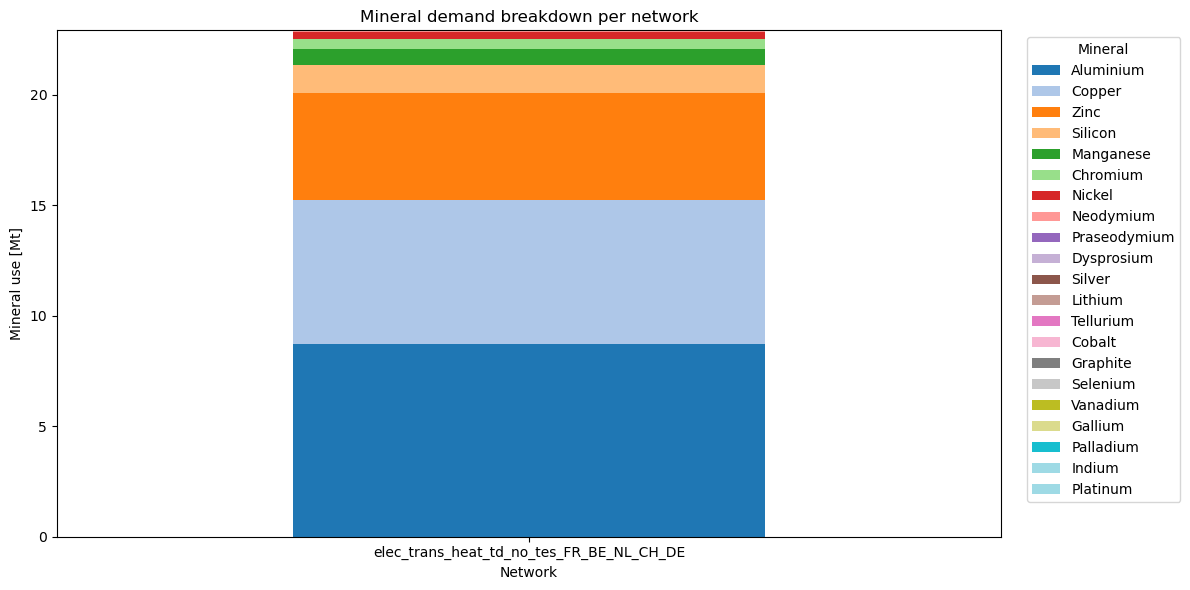

(              elec_trans_heat_td_no_tes_FR_BE_NL_CH_DE
 Aluminium                                 8.714465e+00
 Copper                                    6.507232e+00
 Zinc                                      4.863864e+00
 Silicon                                   1.255571e+00
 Manganese                                 6.969385e-01
 Chromium                                  4.529347e-01
 Nickel                                    3.228516e-01
 Neodymium                                 6.829297e-02
 Praseodymium                              1.146151e-02
 Dysprosium                                7.078133e-03
 Silver                                    1.414722e-03
 Lithium                                   5.888797e-04
 Tellurium                                 3.476473e-04
 Cobalt                                    3.238262e-04
 Graphite                                  2.196382e-05
 Selenium                                  2.759256e-06
 Vanadium                                  1.104

In [ ]:
compare_networks(["elec_trans_heat_td_no_tes_FR_BE_NL_CH_DE"], n, minerals, tech_scenarios, mineral_intensities)

In [127]:
pd.set_option('display.max_rows', 500)

n[sample_new_2h_2050].statistics.expanded_capacity()

component    carrier                                  
Generator    Offshore Wind (AC)                           1.679217e+05
             Offshore Wind (DC)                           4.938259e+05
             Onshore Wind                                 6.370688e+05
             Run of River                                 0.000000e+00
             Solar                                        1.597403e+06
             biogas                                       0.000000e+00
             gas                                          2.945555e+04
             load                                         0.000000e+00
             nuclear                                      1.069380e+02
             oil primary                                  4.610000e-01
             residential rural solar thermal              2.674264e+03
             residential urban decentral solar thermal    2.781223e+03
             services rural solar thermal                 2.702725e+03
             services 

### Sankey diagrams

In [157]:

network_key = sample_low_wind
df_merged, totals_Mt = compute_mineral_usage(network_key, n, all_minerals, "Market share current", mineral_intensities, tech_scenarios)

# assuming `criticality` DataFrame exists and includes
# "GeoPolRisk Characterization Factor [eq. Kg-Cu/Kg]" and a mineral name column
plot_mineral_to_tech_sankey(
    df_merged,
    all_minerals,
    tech_col=None,
    network_name=network_key,
    mode='mass',
    # criticality_df=criticality,
    criticality_min_col=None,   # or the actual mineral name column in your `criticality` DF
    criticality_score_col="GeoPolRisk Characterization Factor [eq. Kg-Cu/Kg]",
    fmt_decimals=3
)

In [237]:

network_key = sample_base_2h
df_merged, totals_Mt = compute_mineral_usage(network_key, n, all_minerals, "Market share current", mineral_intensities, tech_scenarios)

# assuming `criticality` DataFrame exists and includes
# "GeoPolRisk Characterization Factor [eq. Kg-Cu/Kg]" and a mineral name column
plot_mineral_to_tech_sankey(
    df_merged,
    ['Gallium'],
    tech_col=None,
    network_name=network_key,
    mode='mass',
    # criticality_df=criticality,
    criticality_min_col=None,   # or the actual mineral name column in your `criticality` DF
    criticality_score_col="GeoPolRisk Characterization Factor [eq. Kg-Cu/Kg]",
    fmt_decimals=3
)

In [164]:

network_key = sample_base_2h
df_merged, totals_Mt = compute_mineral_usage(network_key, n, all_minerals, "Market share current", mineral_intensities, tech_scenarios)

# assuming `criticality` DataFrame exists and includes
# "GeoPolRisk Characterization Factor [eq. Kg-Cu/Kg]" and a mineral name column
plot_mineral_to_tech_sankey(
    df_merged,
    ['Germanium', 'Indium', 'Iridium'],
    tech_col=None,
    network_name=network_key,
    mode='mass',
    # criticality_df=criticality,
    criticality_min_col=None,   # or the actual mineral name column in your `criticality` DF
    criticality_score_col="GeoPolRisk Characterization Factor [eq. Kg-Cu/Kg]",
    fmt_decimals=3
)

In [ ]:

network_key = sample_low_offwind
df_merged, totals_Mt = compute_mineral_usage(network_key, n, all_minerals, "Scenario EV SiB", mineral_intensities, tech_scenarios)

# assuming `criticality` DataFrame xexists and includes
# "GeoPolRisk Characterization Factor [eq. Kg-Cu/Kg]" and a mineral name column
plot_mineral_to_tech_sankey(
    df_merged,
    all_minerals,
    tech_col=None,
    network_name=network_key,
    mode='mass',
    # criticality_df=criticality,
    criticality_min_col=None,   # or the actual mineral name column in your `criticality` DF
    criticality_score_col="GeoPolRisk Characterization Factor [eq. Kg-Cu/Kg]",
    fmt_decimals=3
)

In [225]:
battery_minerals = ["Iridium", "Platinum", "Palladium"]
network_key = sample_base_2h
df_merged, totals_Mt = compute_mineral_usage(network_key, n, battery_minerals, "Scenario EV SiB", mineral_intensities, tech_scenarios)

# assuming `criticality` DataFrame exists and includes
# "GeoPolRisk Characterization Factor [eq. Kg-Cu/Kg]" and a mineral name column
plot_mineral_to_tech_sankey(
    df_merged,
    battery_minerals,
    tech_col=None,
    network_name=network_key,
    mode='mass',
    # criticality_df=criticality,
    criticality_min_col=None,   # or the actual mineral name column in your `criticality` DF
    criticality_score_col="GeoPolRisk Characterization Factor [eq. Kg-Cu/Kg]",
    fmt_decimals=3
)

In [158]:
battery_minerals = ["Lithium", "Cobalt", "Graphite"]
network_key = sample_new_2h_2050
df_merged, totals_Mt = compute_mineral_usage(network_key, n, battery_minerals, "Scenario EV SiB", mineral_intensities, tech_scenarios)

# assuming `criticality` DataFrame exists and includes
# "GeoPolRisk Characterization Factor [eq. Kg-Cu/Kg]" and a mineral name column
plot_mineral_to_tech_sankey(
    df_merged,
    battery_minerals,
    tech_col=None,
    network_name=network_key,
    mode='mass',
    # criticality_df=criticality,
    criticality_min_col=None,   # or the actual mineral name column in your `criticality` DF
    criticality_score_col="GeoPolRisk Characterization Factor [eq. Kg-Cu/Kg]",
    fmt_decimals=3
)

In [159]:
network_key = sample_base_2h
df_merged, totals_Mt = compute_mineral_usage(network_key, n, rare_earths, "Market share current", mineral_intensities, tech_scenarios)

# assuming `criticality` DataFrame exists and includes
# "GeoPolRisk Characterization Factor [eq. Kg-Cu/Kg]" and a mineral name column
plot_mineral_to_tech_sankey(
    df_merged,
    rare_earths,
    tech_col=None,
    network_name=network_key,
    mode='mass',
    # criticality_df=criticality,
    criticality_min_col=None,   # or the actual mineral name column in your `criticality` DF
    criticality_score_col="GeoPolRisk Characterization Factor [eq. Kg-Cu/Kg]",
    fmt_decimals=3
)

To do: 
- Try criticality scores with different countries to validate scores. 


- Note: for supply comparison, we are comparing *yearly* supply (from IEA) to total cumulative demand from energy system until 2050

### Cumulative mineral use

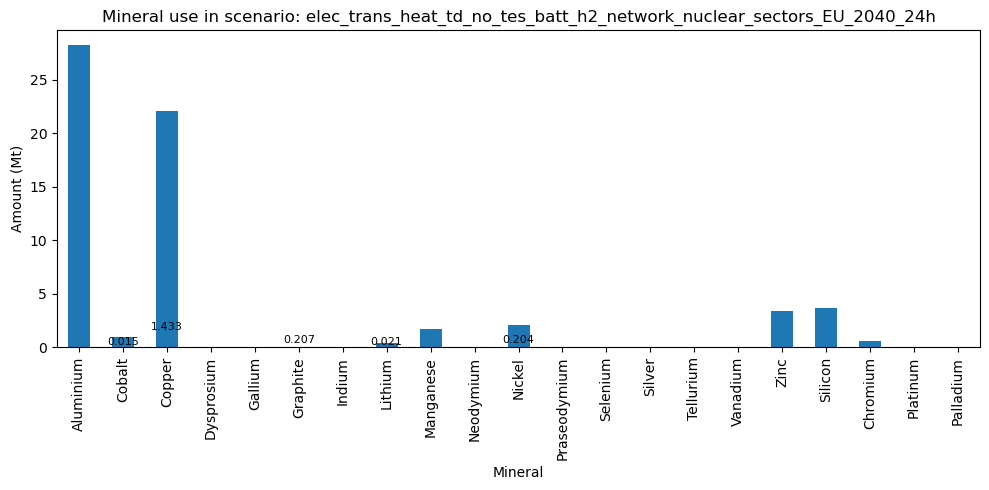

In [ ]:
network_key = "elec_trans_heat_td_no_tes_batt_h2_network_nuclear_sectors_EU_2040_24h"
df_merged, totals_Mt = compute_mineral_usage(network_key, n, all_minerals, "Market share current", mineral_intensities, tech_scenarios)


# s = expanded_capacities[minerals].sum()   # example Series, index = mineral names
ax = totals_Mt.plot.bar(figsize=(10,5), color="C0")
ax.set_ylabel("Amount (Mt)")        # change units/label as needed
ax.set_xlabel("Mineral")              # remove x-label if redundant
ax.set_title(f"Mineral use in scenario: {network_key}")


# optional: annotate numeric values
for x, y in zip(xs, ys):
    ax.text(x, y, f"{y:.3f}", ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

### Cumulative mineral use as a % of reserves

In [127]:
totals_Mt

Neodymium       0.078608
Praseodymium    0.013790
Dysprosium      0.007870
dtype: float64

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11],
 [Text(0, 0, 'Aluminium'),
  Text(1, 0, 'Cobalt'),
  Text(2, 0, 'Copper'),
  Text(3, 0, 'Graphite'),
  Text(4, 0, 'Lithium'),
  Text(5, 0, 'Manganese'),
  Text(6, 0, 'Nickel'),
  Text(7, 0, 'Selenium'),
  Text(8, 0, 'Silver'),
  Text(9, 0, 'Tellurium'),
  Text(10, 0, 'Vanadium'),
  Text(11, 0, 'Zinc')])

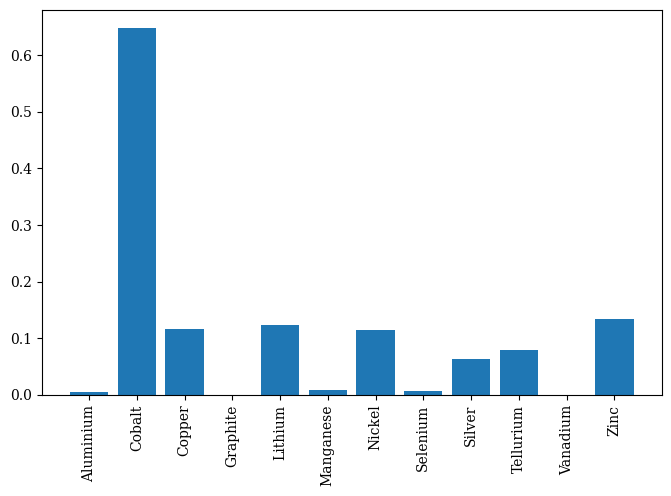

In [76]:
# start with cumulative energy-only supply compared to reserves
network_key = sample_new_2h_2050
df_merged, totals_Mt = compute_mineral_usage(network_key, n, all_minerals, "Market share current", mineral_intensities, tech_scenarios)

demand_df = totals_Mt.reset_index()
demand_df.columns = ['Mineral', 'Demand (Mt)']
reserves = mineral_avail[mineral_avail['Estimate method']=="Reserves"]
merged = pd.merge(reserves,
                  demand_df,
                  on='Mineral',
                  how='outer') 
merged["GDP-allocated reserves"] =merged["Value (Mt)"] * mineral_alloc_factors["GDP share"]

merged["Eur transition demand per total reserves"] = merged["Demand (Mt)"]/merged["Value (Mt)"]
merged["Eur transition demand per total allocated reserves"] = merged["Demand (Mt)"]/merged["GDP-allocated reserves"]

fig, ax = plt.subplots(figsize=(8, 5))

to_plot = merged[(~merged["Value (Mt)"].isna()) & (~merged["Demand (Mt)"].isna())]
# to_plot
ax.bar(to_plot["Mineral"], to_plot["Eur transition demand per total allocated reserves"])
plt.xticks(rotation=90)

In [98]:

# Add REE as sum of the three elements in a pandas Series `s`
totals_Mt.loc['REE'] = totals_Mt.loc[['Praseodymium', 'Neodymium', 'Dysprosium']].sum()
totals_Mt

Aluminium       28.269604
Cobalt           1.517576
Copper          24.338985
Dysprosium       0.007665
Gallium          0.000173
Germanium        0.000140
Graphite         0.027114
Iridium          0.000005
Lithium          0.791483
Manganese        2.906491
Neodymium        0.077082
Nickel           3.151070
Praseodymium     0.013604
Selenium         0.000146
Silver           0.008723
Tellurium        0.000594
Vanadium         0.001658
Zinc             6.547831
Silicon          2.402023
Chromium         0.749709
Platinum         0.000005
Palladium        0.000073
REE              0.098351
dtype: float64

In [15]:
totals_Mt

Aluminium       28.269604
Cobalt           1.517576
Copper          24.338985
Dysprosium       0.007665
Gallium          0.000173
Germanium        0.000140
Graphite         0.027114
Iridium          0.000005
Lithium          0.791483
Manganese        2.906491
Neodymium        0.077082
Nickel           3.151070
Praseodymium     0.013604
Selenium         0.000146
Silver           0.008723
Tellurium        0.000594
Vanadium         0.001658
Zinc             6.547831
Silicon          2.402023
Chromium         0.749709
Platinum         0.000005
Palladium        0.000073
REE              0.098351
dtype: float64

In [16]:
non_energy_demand_cumulative

,Mineral,GDP-adjusted value entso-e (Mt)
42,Copper,102.568532
43,Cobalt,0.972108
44,Lithium,0.616579
45,Nickel,15.384349
46,REE,0.525524
47,Graphite,34.223222


In [151]:
df_merged, totals_Mt = compute_mineral_usage(network_key, n, all_minerals, "Market share current", mineral_intensities, tech_scenarios)
totals_Mt

Aluminium       33.859809
Cobalt           1.522585
Copper          27.646562
Dysprosium       0.012474
Gallium          0.001895
Germanium        0.000140
Graphite         0.035941
Iridium          0.000005
Lithium          0.791483
Manganese        3.298926
Neodymium        0.136307
Nickel           4.004042
Praseodymium     0.031633
Selenium         0.000223
Silver           0.009872
Tellurium        0.001058
Vanadium         0.001660
Zinc             6.993402
Silicon          2.404958
Chromium         0.758401
Platinum         0.000008
Palladium        0.000078
dtype: float64

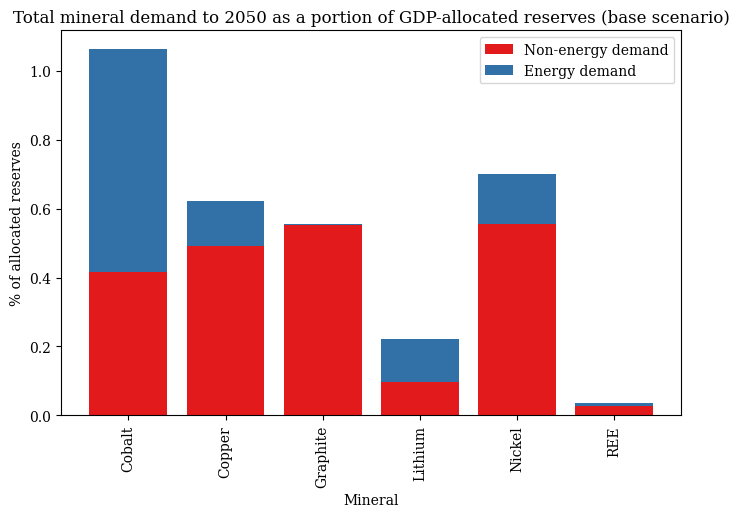

In [150]:
# now compare total demand to reserves
network_key = sample_new_2h_2050
df_merged, totals_Mt = compute_mineral_usage(network_key, n, all_minerals, "Market share current", mineral_intensities, tech_scenarios)
totals_Mt.loc['REE'] = totals_Mt.loc[['Praseodymium', 'Neodymium', 'Dysprosium']].sum()
non_energy_demand_cumulative = non_energy_demand[non_energy_demand["Year"] == "Cumulative"][["Mineral", "GDP-adjusted value entso-e (Mt)"]]

demand_df = totals_Mt.reset_index()
demand_df.columns = ['Mineral', 'Demand (Mt)']
reserves = mineral_avail[mineral_avail['Estimate method']=="Reserves"]
merged = pd.merge(reserves,
                  demand_df,
                  on='Mineral',
                  how='outer') 
merged = pd.merge(merged,
                  non_energy_demand_cumulative, 
                  on="Mineral", 
                  how="inner")
merged.rename(columns={"GDP-adjusted value entso-e (Mt)":"Non-energy demand (Mt)"}, inplace=True)
merged["GDP-allocated reserves"] =merged["Value (Mt)"] * mineral_alloc_factors["GDP share"]

merged["Eur transition demand per total reserves"] = merged["Demand (Mt)"]/merged["Value (Mt)"]
merged["Eur transition demand per total allocated reserves"] = merged["Demand (Mt)"]/merged["GDP-allocated reserves"]

merged["Eur other demand per total reserves"] = merged["Non-energy demand (Mt)"]/merged["Value (Mt)"]
merged["Eur other demand per total allocated reserves"] = merged["Non-energy demand (Mt)"]/merged["GDP-allocated reserves"]

fig, ax = plt.subplots(figsize=(8, 5))

to_plot = merged[(~merged["Value (Mt)"].isna()) & (~merged["Demand (Mt)"].isna())]
# to_plot

ax.bar(to_plot["Mineral"], to_plot["Eur other demand per total allocated reserves"], color="#e31a1c", label="Non-energy demand")
ax.bar(to_plot["Mineral"], to_plot["Eur transition demand per total allocated reserves"], bottom=to_plot["Eur other demand per total allocated reserves"], color="#3271a8", label="Energy demand")

ax.set_ylabel("% of allocated reserves")
ax.set_xlabel("Mineral")

plt.xticks(rotation=90)
plt.title("Total mineral demand to 2050 as a portion of GDP-allocated reserves (base scenario)")
plt.legend(loc="upper right")

plt.show()

In [94]:
merged

,Mineral,Estimate method,Estimate year,Value (kt),Percentage change,Percentage change period,Source,Notes,Value (Mt),Demand (Mt),Non-energy demand (Mt),GDP-allocated reserves,Eur transition demand per total reserves,Eur transition demand per total allocated reserves,Eur other demand per total reserves,Eur other demand per total allocated reserves
0,Cobalt,Reserves,2025.0,11000.0,NaN,NaN,US Mineral Commodity Summaries 2025,NaN,11.0,1.517576,0.972108,2.343,0.137961,0.647706,0.088373,0.414899
1,Copper,Reserves,2025.0,980000.0,NaN,NaN,US Mineral Commodity Summaries 2025,NaN,980.0,24.338985,102.568532,208.740,0.024836,0.116600,0.104662,0.491370
2,Graphite,Reserves,2025.0,290000.0,NaN,NaN,US Mineral Commodity Summaries 2025,NaN,290.0,0.027114,34.223222,61.770,0.000093,0.000439,0.118011,0.554043
3,Lithium,Reserves,2025.0,30000.0,NaN,NaN,US Mineral Commodity Summaries 2025,NaN,30.0,0.791483,0.616579,6.390,0.026383,0.123863,0.020553,0.096491
4,Nickel,Reserves,2025.0,130000.0,NaN,NaN,US Mineral Commodity Summaries 2025,Lower bound,130.0,3.151070,15.384349,27.690,0.024239,0.113798,0.118341,0.555592
5,REE,Reserves,2025.0,90000.0,NaN,NaN,US Mineral Commodity Summaries 2025,Lower bound,90.0,NaN,0.525524,19.170,NaN,NaN,0.005839,0.027414


Add *current* non-energy supply extrapolated to 2050? conservative estimate neglecting demand growth 

### Yearly mineral use

Red: GDP share
Green: per capita share corrected for energy use

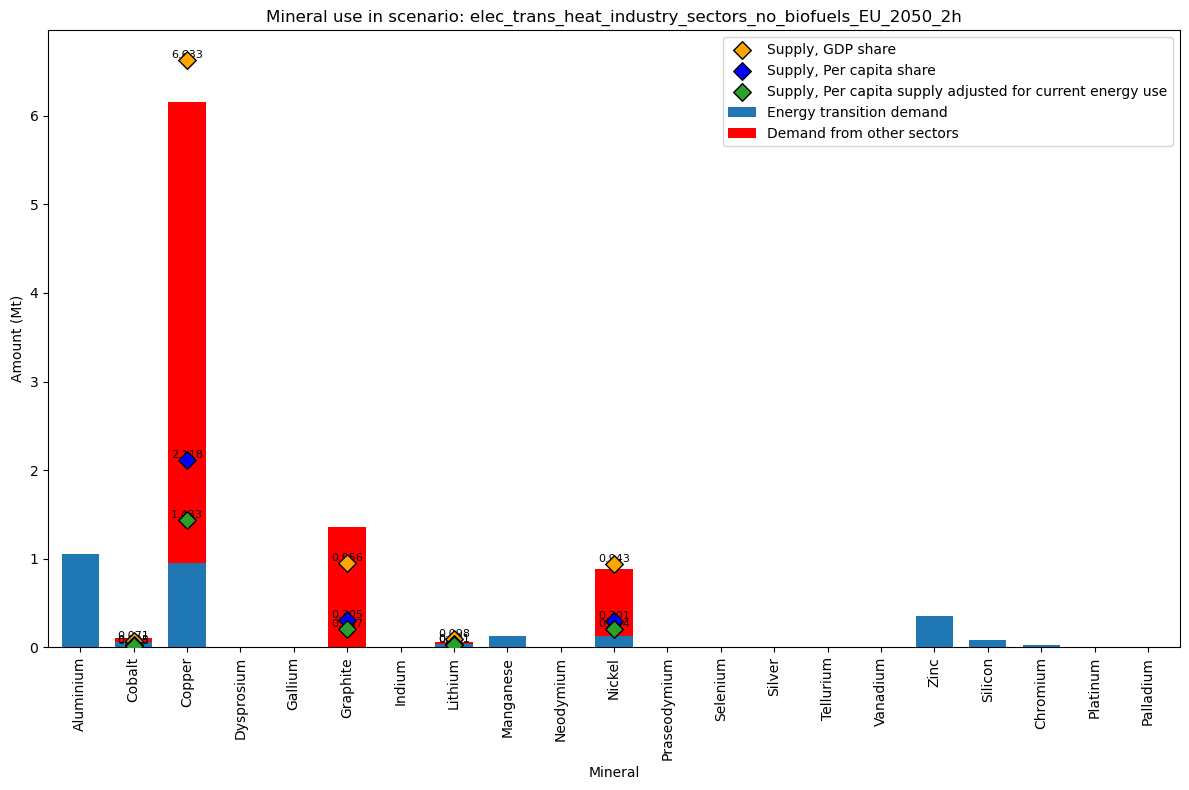

In [ ]:
network_key = sample_new_2h_2050
time_diff = 24
df_merged, totals_Mt = compute_mineral_usage(network_key, n, all_minerals, "Market share current", mineral_intensities, tech_scenarios)
totals_Mt_yearly = totals_Mt/time_diff


# s = expanded_capacities[minerals].sum()   # example Series, index = mineral names
ax = totals_Mt_yearly.plot.bar(figsize=(12,8), color="C0", width = 0.7, label="Energy transition demand")
ax.set_ylabel("Amount (Mt)")        # change units/label as needed
ax.set_xlabel("Mineral")              # remove x-label if redundant
ax.set_title(f"Mineral use in scenario: {network_key}")


# read current tick positions & labels from the existing axis `ax`
positions = ax.get_xticks()
labels = [t.get_text() for t in ax.get_xticklabels()]

xs = []
ys = []

xs1 = []
ys1 = []

xs2 = []
ys2 = []

xs3 = []
ys3 = []

xs6 = []
ys6 = []
bottom = []

for x_pos, lab in zip(positions, labels):
    if lab in supply.index:
        xs.append(x_pos)
        ys.append(supply_pce.loc[lab])

        xs1.append(x_pos)
        ys1.append(supply_gdp.loc[lab])

        xs2.append(x_pos)
        ys2.append(supply_pc.loc[lab])
    if lab in prod.index: 
        xs3.append(x_pos)
        ys3.append(prod_pce.loc[lab])
    if lab in non_energy_demand.index: 
        xs6.append(x_pos)
        ys6.append(non_energy_demand.loc[lab]["Value entso-e (Mt)"])
        bottom.append(totals_Mt_yearly.loc[lab])

ax.bar(xs6, ys6, bottom = bottom, color="red", width=0.7, label="Demand from other sectors")

# plot supply points on top of the bars
ax.scatter(xs1, ys1, color='orange', marker='D', s=80, edgecolor='k', zorder=10, label='Supply, GDP share')
ax.scatter(xs2, ys2, color='blue', marker='D', s=80, edgecolor='k', zorder=10, label='Supply, Per capita share')
ax.scatter(xs, ys, color='C2', marker='D', s=80, edgecolor='k', zorder=10, label='Supply, Per capita supply adjusted for current energy use')

# plot production points on top of the bars
# ax.scatter(xs3, ys3, color='red', marker='o', s=80, edgecolor='k', zorder=10, label='Current production, GDP share')
# ax.scatter(xs4, ys4, color='blue', marker='o', s=80, edgecolor='k', zorder=10, label='Current production, Per capita share')
# ax.scatter(xs5, ys5, color='C2', marker='o', s=80, edgecolor='k', zorder=10, label='Current production, Per capita supply adjusted for current energy use')



# optional: annotate numeric values
for x, y in zip(xs, ys):
    ax.text(x, y, f"{y:.3f}", ha='center', va='bottom', fontsize=8)

for x, y in zip(xs1, ys1):
    ax.text(x, y, f"{y:.3f}", ha='center', va='bottom', fontsize=8)

for x, y in zip(xs2, ys2):
    ax.text(x, y, f"{y:.3f}", ha='center', va='bottom', fontsize=8)


plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

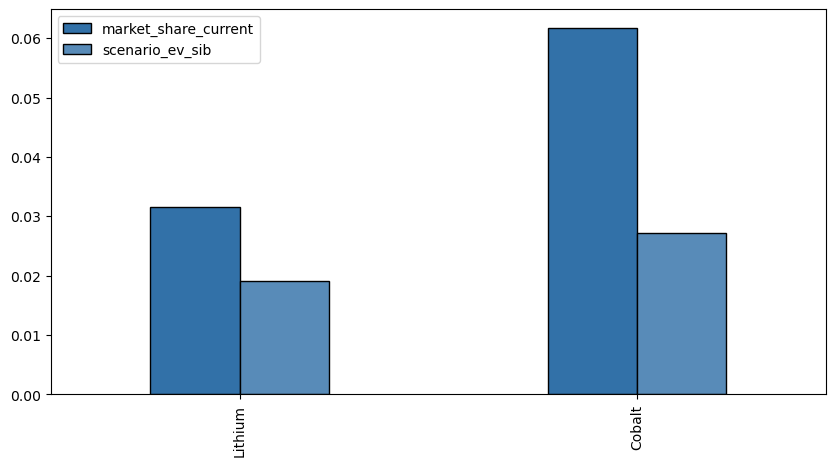

In [192]:
s1 = "Market share current"
s2 = "Scenario EV SiB"
df_merged_s1, totals_Mt_s1 = compute_mineral_usage(network_key, n, ["Lithium", "Cobalt"], s1, mineral_intensities, tech_scenarios)
df_merged_s2, totals_Mt_s2 = compute_mineral_usage(network_key, n, ["Lithium", "Cobalt"], s2, mineral_intensities, tech_scenarios)

totals_Mt_yearly_s1 = totals_Mt_s1/time_diff
totals_Mt_yearly_s2 = totals_Mt_s2/time_diff

scenarios_df = pd.DataFrame(dict(market_share_current = totals_Mt_yearly_s1, scenario_ev_sib = totals_Mt_yearly_s2))

ax = scenarios_df.plot.bar(figsize=(10,5),  color=["#3271a8", "#588bb8" ], width = 0.45, label="Energy transition demand", edgecolor='black', linewidth=1)


In [74]:
non_energy_demand.loc[(non_energy_demand["Mineral"]=="Lithium") & (non_energy_demand["Year"]==DNEA_year) & (non_energy_demand["Source"]==DNEA_source)]["GDP-adjusted value entso-e (Mt)"]

Series([], Name: GDP-adjusted value entso-e (Mt), dtype: float64)

IEA-based supply and non-energy demand

Lithium
{'DNEA': array([0.03195, 0.03195, 0.03195, 0.03195, 0.03195, 0.03195, 0.03195,
       0.03195]), 'Energy': array([0.03496236, 0.05220822, 0.03755157, 0.0337681 , 0.01102977,
       0.02452009, 0.03172791, 0.03496236])}
Copper
{'DNEA': array([4.600374, 4.600374, 4.600374, 4.600374, 4.600374, 4.600374,
       4.600374, 4.600374]), 'Energy': array([1.20318993, 2.12535485, 1.31615806, 1.1587189 , 0.96193385,
       1.16441783, 1.06722245, 1.02384723])}
Cobalt
{'DNEA': array([0.045156, 0.045156, 0.045156, 0.045156, 0.045156, 0.045156,
       0.045156, 0.045156]), 'Energy': array([0.06532071, 0.08167484, 0.06778374, 0.06420281, 0.0144473 ,
       0.03747155, 0.01118296, 0.06532071])}
Nickel
{'DNEA': array([0.663495, 0.663495, 0.663495, 0.663495, 0.663495, 0.663495,
       0.663495, 0.663495]), 'Energy': array([0.17144156, 0.18765815, 0.18079587, 0.17901287, 0.14279819,
       0.18169507, 0.09343761, 0.17144156])}
Graphite (natural and synthetic)
{'DNEA': array([1.808157, 1.808157, 1.

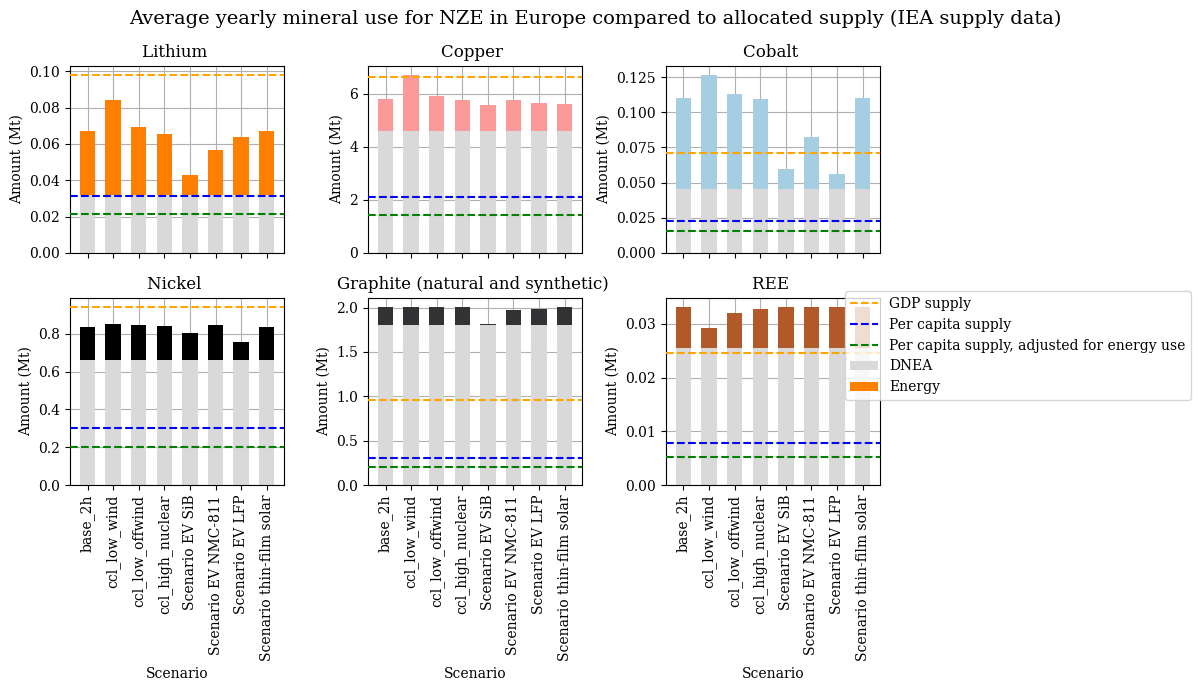

In [193]:
bar_width = 0.6

base_scenario = sample_base_2h
network_scenarios = [base_scenario, sample_low_wind, sample_low_offwind, sample_high_nuclear]
market_scenarios = ["Scenario EV SiB", "Scenario EV NMC-811", "Scenario EV LFP", "Scenario thin-film solar"]
minerals = ["Lithium", "Copper", "Cobalt", "Nickel", "Graphite (natural and synthetic)", "REE"]
DNEA_source = "IEA CM explorer (net zero scenario)"
DNEA_year = "2050"

time_diff = 24

all_scenarios_len = len(network_scenarios) + len(market_scenarios)

fig, axs = plt.subplots(math.ceil(len(minerals)/3), 3, 
                        figsize=(12, 7) )
# fig.tight_layout()

axes = axs.flatten()
colors = ['r', 'g', 'b']

for idx, mineral in enumerate(minerals): 
    # print(i)
    # axes[i].plot(range(10), colors[i])
    print(mineral)

    DNEA_vals = []
    energy_vals = []
    all_scenario_names = []

    for scenario in network_scenarios: 
        if mineral == "REE": 
            df_merged, totals_Mt = compute_mineral_usage(scenario, n, rare_earths, "Market share current", mineral_intensities, tech_scenarios)
            total_REEs = pd.Series(data = {'REE': totals_Mt.sum()}, index=['REE'])
            total_REEs_yearly = total_REEs/time_diff
            
            energy_vals.append(total_REEs_yearly.values[0])
            all_scenario_names.append(scenario)
        elif mineral == "Graphite (natural and synthetic)": 
            df_merged, totals_Mt = compute_mineral_usage(scenario, n, ["Graphite", "Graphite (synthetic)"], "Market share current", mineral_intensities, tech_scenarios)
            total_graphite = pd.Series(data = {'Graphite (natural and synthetic)': totals_Mt.sum()}, index=['Graphite (natural and synthetic)'])
            total_graphite_yearly = total_graphite/time_diff
            
            energy_vals.append(total_graphite_yearly.values[0])
            all_scenario_names.append(scenario)
        else: 
            df_merged, totals_Mt = compute_mineral_usage(scenario, n, mineral, "Market share current", mineral_intensities, tech_scenarios)
            totals_Mt_yearly = totals_Mt/time_diff
            energy_vals.append(totals_Mt_yearly)
            all_scenario_names.append(scenario)

    for scenario in market_scenarios: 
        if mineral == "REE": 
            df_merged, totals_Mt = compute_mineral_usage(base_scenario, n, rare_earths, scenario, mineral_intensities, tech_scenarios)
            total_REEs = pd.Series(data = {'REE': totals_Mt.sum()}, index=['REE'])
            total_REEs_yearly = total_REEs/time_diff
            
            energy_vals.append(total_REEs_yearly.values[0])
            all_scenario_names.append(scenario)
        elif mineral == "Graphite (natural and synthetic)": 
            df_merged, totals_Mt = compute_mineral_usage(base_scenario, n, ["Graphite", "Graphite (synthetic)"], scenario, mineral_intensities, tech_scenarios)
            total_graphite = pd.Series(data = {'Graphite (natural and synthetic)': totals_Mt.sum()}, index=['Graphite (natural and synthetic)'])
            total_graphite_yearly = total_graphite/time_diff
            
            energy_vals.append(total_graphite_yearly.values[0])
            all_scenario_names.append(scenario)
        else: 
            df_merged, totals_Mt = compute_mineral_usage(base_scenario, n, mineral, scenario, mineral_intensities, tech_scenarios)
            totals_Mt_yearly = totals_Mt/time_diff
            energy_vals.append(totals_Mt_yearly)
            all_scenario_names.append(scenario)

    amounts = {
        "DNEA": np.full(all_scenarios_len, non_energy_demand.loc[(non_energy_demand["Mineral"]==mineral) & (non_energy_demand["Year"]==DNEA_year) & (non_energy_demand["Source"]==DNEA_source)]["GDP-adjusted value entso-e (Mt)"]), 
        "Energy": np.array(energy_vals)
    }

    print(amounts)


    bottom = np.zeros(all_scenarios_len)
    colors = ["#d9d9d9", minerals_color_map[mineral]]
    i = 0
    for boolean, val in amounts.items():
        p = axes[idx].bar(all_scenario_names, val, bar_width, label=boolean, bottom=bottom, color = colors[i], zorder=2)
        bottom += val
        i +=1
    

    min_supply_pce = supply_pce.loc[mineral]
    min_supply_gdp = supply_gdp.loc[mineral]
    min_supply_pc = supply_pc.loc[mineral]

    axes[idx].axhline(y=min_supply_gdp, linestyle="--", linewidth=1.5, zorder=3, color="orange", label='GDP supply')
    axes[idx].axhline(y=min_supply_pc, linestyle="--", linewidth=1.5, zorder=3, color="blue", label='Per capita supply')
    axes[idx].axhline(y=min_supply_pce, linestyle="--", linewidth=1.5, zorder=3, color="green", label='Per capita supply, adjusted for energy use')

    axes[idx].set_ylabel("Amount (Mt)")        # change units/label as needed
    axes[idx].set_xlabel("Scenario")              # remove x-label if redundant

    axes[idx].set_title(f"{mineral} ")
    # axes[idx].legend(loc="upper right")
    axes[idx].grid(zorder=0)
    axes[idx].tick_params(axis='x', labelrotation=90)


n_rows, n_cols = axs.shape

for i, ax in enumerate(axs.flat):
    row = i // n_cols

    if row < n_rows - 1:  # not bottom row
        ax.set_xlabel("")                 # remove x-axis label
        ax.tick_params(axis='x', labelbottom=False)  # remove tick labels

handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="center right"     # choose position
    # frameon=False
)

fig.suptitle("Average yearly mineral use for NZE in Europe compared to allocated supply (IEA supply data)", fontsize=14)
fig.tight_layout(rect=[0, 0, 0.75, 1]) 

# plt.xticks(rotation=45, ha="right")
plt.show()



In [182]:
df_merged, totals_Mt = compute_mineral_usage(sample_base_2h, n, ["Graphite", "Graphite (synthetic)"], "Market share current", mineral_intensities, tech_scenarios)
totals_Mt/24

Graphite                0.001570
Graphite (synthetic)    0.199376
dtype: float64

In [26]:
non_energy_demand.loc[(non_energy_demand["Mineral"]==mineral) & (non_energy_demand["Year"]==DNEA_year) & (non_energy_demand["Source"]==DNEA_source)]["GDP-adjusted value entso-e (Mt)"]

Series([], Name: GDP-adjusted value entso-e (Mt), dtype: float64)

In [227]:
all_minerals

['Aluminium',
 'Cobalt',
 'Copper',
 'Dysprosium',
 'Gallium',
 'Germanium',
 'Graphite',
 'Iridium',
 'Lithium',
 'Manganese',
 'Neodymium',
 'Nickel',
 'Praseodymium',
 'Selenium',
 'Silver',
 'Tellurium',
 'Vanadium',
 'Zinc',
 'Silicon',
 'Chromium',
 'Platinum',
 'Palladium']

Gallium
Germanium
Indium
Iridium
Manganese
Platinum
Vanadium


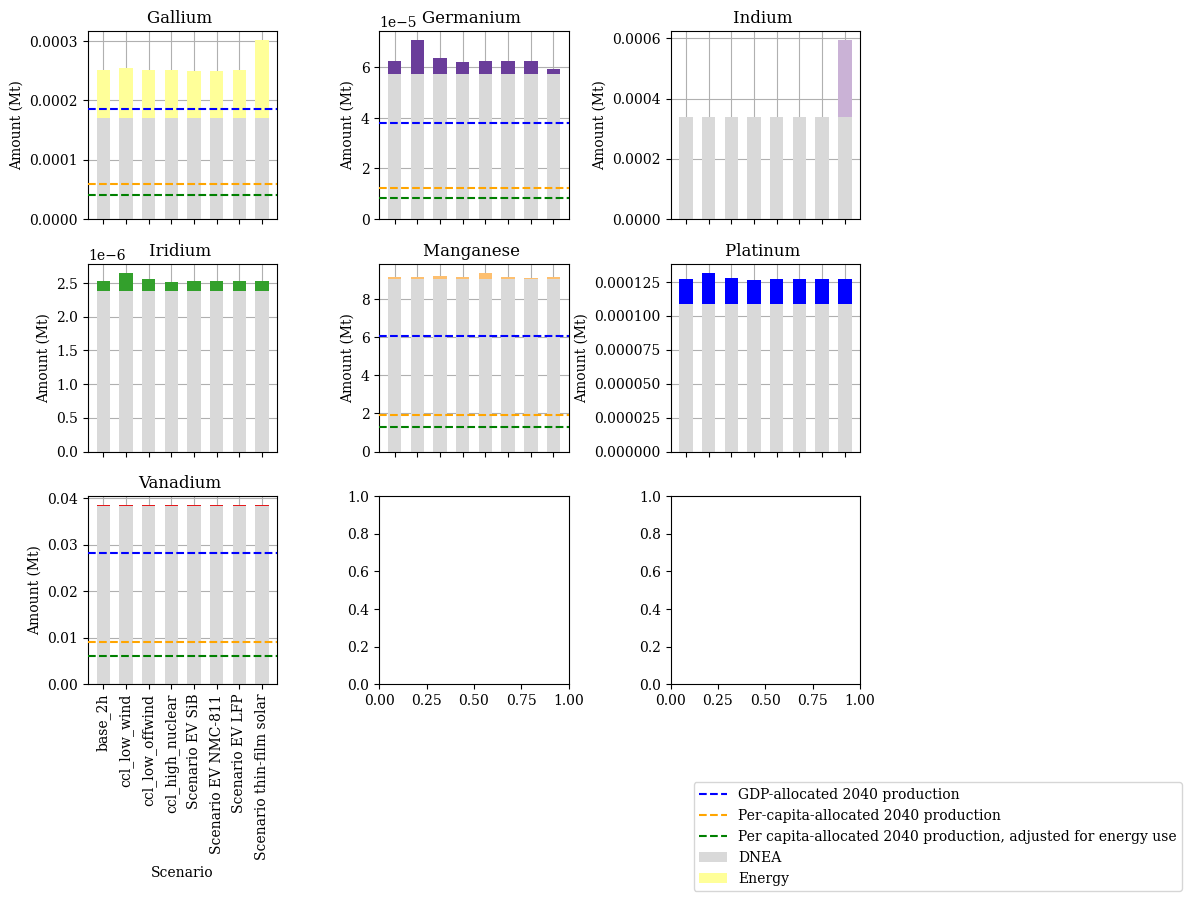

In [ ]:
bar_width = 0.6

base_scenario = sample_base_2h
network_scenarios = [base_scenario, sample_low_wind, sample_low_offwind, sample_high_nuclear]
market_scenarios = ["Scenario EV SiB", "Scenario EV NMC-811", "Scenario EV LFP", "Scenario thin-film solar"]
minerals = [ "Gallium", "Germanium", "Indium", "Iridium", "Manganese", "Platinum", "Vanadium"]
DNEA_source = "Schlichenmaier and Naegler 2022"
DNEA_year = "2030"

avail_source = "USGS (extrapolated using CAGR)"
avail_year = 2040
avail_method = "Production"

avail_global = mineral_avail[(mineral_avail['Estimate method']== avail_method)&(mineral_avail['Estimate year']== avail_year)&(mineral_avail['Source']== avail_source)].set_index('Mineral')['Value (Mt)']
avail_gdp = avail_global*mineral_alloc_factors["GDP share"]
avail_pce = avail_global*mineral_alloc_factors["Per capita share corrected for energy use"]
avail_pc = avail_global*mineral_alloc_factors["Per capita share"]


time_diff = 24

all_scenarios_len = len(network_scenarios) + len(market_scenarios)

fig, axs = plt.subplots(math.ceil(len(minerals)/3), 3, 
                        figsize=(12, math.ceil(len(minerals)/3)*3) )
# fig.tight_layout()

axes = axs.flatten()


for idx, mineral in enumerate(minerals): 
    print(mineral)

    DNEA_vals = []
    energy_vals = []
    all_scenario_names = []

    for scenario in network_scenarios: 
        if mineral == "REE": 
            df_merged, totals_Mt = compute_mineral_usage(scenario, n, rare_earths, "Market share current", mineral_intensities, tech_scenarios)
            total_REEs = pd.Series(data = {'REE': totals_Mt.sum()}, index=['REE'])
            total_REEs_yearly = total_REEs/time_diff
            
            energy_vals.append(total_REEs_yearly.values[0])
            all_scenario_names.append(scenario)
        else: 
            df_merged, totals_Mt = compute_mineral_usage(scenario, n, mineral, "Market share current", mineral_intensities, tech_scenarios)
            totals_Mt_yearly = totals_Mt/time_diff
            energy_vals.append(totals_Mt_yearly)
            all_scenario_names.append(scenario)

    for scenario in market_scenarios: 
        if mineral == "REE": 
            df_merged, totals_Mt = compute_mineral_usage(base_scenario, n, rare_earths, scenario, mineral_intensities, tech_scenarios)
            total_REEs = pd.Series(data = {'REE': totals_Mt.sum()}, index=['REE'])
            total_REEs_yearly = total_REEs/time_diff
            
            energy_vals.append(total_REEs_yearly.values[0])
            all_scenario_names.append(scenario)
        else: 
            df_merged, totals_Mt = compute_mineral_usage(base_scenario, n, mineral, scenario, mineral_intensities, tech_scenarios)
            totals_Mt_yearly = totals_Mt/time_diff
            energy_vals.append(totals_Mt_yearly)
            all_scenario_names.append(scenario)

    amounts = {
        "DNEA": np.full(all_scenarios_len, non_energy_demand.loc[(non_energy_demand["Mineral"]==mineral) & (non_energy_demand["Year"]==DNEA_year) & (non_energy_demand["Source"]==DNEA_source)]["GDP-adjusted value entso-e (Mt)"]), 
        "Energy": np.array(energy_vals)
    }


    bottom = np.zeros(all_scenarios_len)
    colors = ["#d9d9d9", minerals_color_map[mineral]]
    i = 0
    for boolean, val in amounts.items():
        p = axes[idx].bar(all_scenario_names, val, bar_width, label=boolean, bottom=bottom, color = colors[i], zorder=2)
        bottom += val
        i +=1
    
    if mineral in avail_global.index: 
        min_prod_pce = avail_pce.loc[mineral]
        min_prod_gdp = avail_gdp.loc[mineral]
        min_prod_pc = avail_pc.loc[mineral]

        axes[idx].axhline(y=min_prod_gdp, linestyle="--", linewidth=1.5, zorder=3, color="blue", label='GDP-allocated 2040 production')
        axes[idx].axhline(y=min_prod_pc, linestyle="--", linewidth=1.5, zorder=3, color="orange", label='Per-capita-allocated 2040 production')
        axes[idx].axhline(y=min_prod_pce, linestyle="--", linewidth=1.5, zorder=3, color="green", label='Per capita-allocated 2040 production, adjusted for energy use')

    axes[idx].set_ylabel("Amount (Mt)")        # change units/label as needed
    axes[idx].set_xlabel("Scenario")              # remove x-label if redundant

    axes[idx].set_title(f"{mineral} ")
    # axes[idx].legend(loc="upper right")
    axes[idx].grid(zorder=0)
    axes[idx].tick_params(axis='x', labelrotation=90)


n_rows, n_cols = axs.shape

for i, ax in enumerate(axs.flat):
    row = i // n_cols

    if row < n_rows - 1:  # not bottom row
        ax.set_xlabel("")                 # remove x-axis label
        ax.tick_params(axis='x', labelbottom=False)  # remove tick labels

handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="lower right"     # choose position
    # frameon=False
)

fig.tight_layout(rect=[0, 0, 0.75, 1]) 

# plt.xticks(rotation=45, ha="right")
plt.show()


In [43]:
mineral_avail[(mineral_avail['Estimate method']== avail_method)&(mineral_avail['Estimate year']== avail_year)&(mineral_avail['Source']== avail_source)]

,Mineral,Estimate method,Estimate year,Value (kt),Percentage change,Percentage change period,Source,Notes,Value (Mt)


Neodymium
Dysprosium


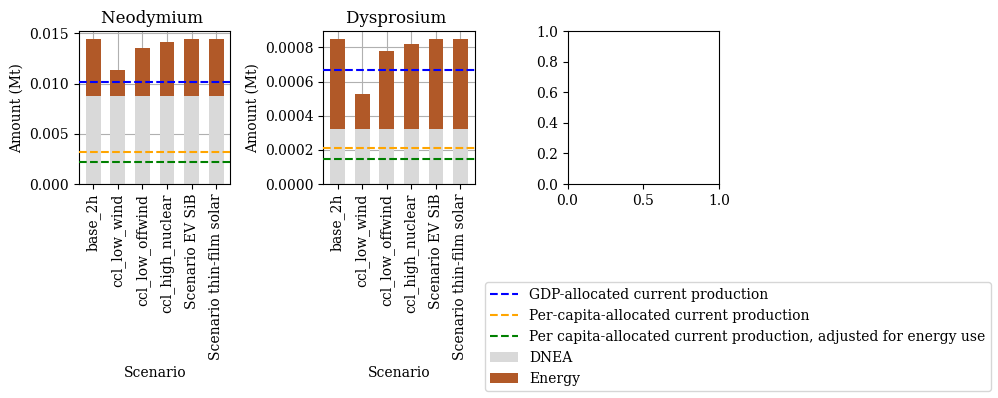

In [160]:
bar_width = 0.6

base_scenario = sample_base_2h
network_scenarios = [base_scenario, sample_low_wind, sample_low_offwind, sample_high_nuclear]
market_scenarios = ["Scenario EV SiB", "Scenario thin-film solar"]
minerals = ["Neodymium", "Dysprosium"]
DNEA_source = "Schlichenmaier and Naegler 2022"
DNEA_year = "2030"

avail_source = "European Commission Raw Materials Information System"
avail_year = 2021
avail_method = "Production"

avail_global = mineral_avail[(mineral_avail['Estimate method']== avail_method)&(mineral_avail['Estimate year']== avail_year)&(mineral_avail['Source']== avail_source)].set_index('Mineral')['Value (Mt)']
avail_gdp = avail_global*mineral_alloc_factors["GDP share"]
avail_pce = avail_global*mineral_alloc_factors["Per capita share corrected for energy use"]
avail_pc = avail_global*mineral_alloc_factors["Per capita share"]


time_diff = 24

all_scenarios_len = len(network_scenarios) + len(market_scenarios)

fig, axs = plt.subplots(math.ceil(len(minerals)/3), 3, 
                        figsize=(10, 4) )
# fig.tight_layout()

axes = axs.flatten()


for idx, mineral in enumerate(minerals): 
    print(mineral)

    DNEA_vals = []
    energy_vals = []
    all_scenario_names = []

    for scenario in network_scenarios: 
        if mineral == "REE": 
            df_merged, totals_Mt = compute_mineral_usage(scenario, n, rare_earths, "Market share current", mineral_intensities, tech_scenarios)
            total_REEs = pd.Series(data = {'REE': totals_Mt.sum()}, index=['REE'])
            total_REEs_yearly = total_REEs/time_diff
            
            energy_vals.append(total_REEs_yearly.values[0])
            all_scenario_names.append(scenario)
        else: 
            df_merged, totals_Mt = compute_mineral_usage(scenario, n, mineral, "Market share current", mineral_intensities, tech_scenarios)
            totals_Mt_yearly = totals_Mt/time_diff
            energy_vals.append(totals_Mt_yearly)
            all_scenario_names.append(scenario)

    for scenario in market_scenarios: 
        if mineral == "REE": 
            df_merged, totals_Mt = compute_mineral_usage(base_scenario, n, rare_earths, scenario, mineral_intensities, tech_scenarios)
            total_REEs = pd.Series(data = {'REE': totals_Mt.sum()}, index=['REE'])
            total_REEs_yearly = total_REEs/time_diff
            
            energy_vals.append(total_REEs_yearly.values[0])
            all_scenario_names.append(scenario)
        else: 
            df_merged, totals_Mt = compute_mineral_usage(base_scenario, n, mineral, scenario, mineral_intensities, tech_scenarios)
            totals_Mt_yearly = totals_Mt/time_diff
            energy_vals.append(totals_Mt_yearly)
            all_scenario_names.append(scenario)

    amounts = {
        "DNEA": np.full(all_scenarios_len, non_energy_demand.loc[(non_energy_demand["Mineral"]==mineral) & (non_energy_demand["Year"]==DNEA_year) & (non_energy_demand["Source"]==DNEA_source)]["GDP-adjusted value entso-e (Mt)"]), 
        "Energy": np.array(energy_vals)
    }


    bottom = np.zeros(all_scenarios_len)
    colors = ["#d9d9d9", minerals_color_map[mineral]]
    i = 0
    for boolean, val in amounts.items():
        p = axes[idx].bar(all_scenario_names, val, bar_width, label=boolean, bottom=bottom, color = colors[i], zorder=2)
        bottom += val
        i +=1
    
    if mineral in avail_global.index: 
        min_prod_pce = avail_pce.loc[mineral]
        min_prod_gdp = avail_gdp.loc[mineral]
        min_prod_pc = avail_pc.loc[mineral]

        axes[idx].axhline(y=min_prod_gdp, linestyle="--", linewidth=1.5, zorder=3, color="blue", label='GDP-allocated current production')
        axes[idx].axhline(y=min_prod_pc, linestyle="--", linewidth=1.5, zorder=3, color="orange", label='Per-capita-allocated current production')
        axes[idx].axhline(y=min_prod_pce, linestyle="--", linewidth=1.5, zorder=3, color="green", label='Per capita-allocated current production, adjusted for energy use')
    
    
    # if mineral in prod_50.index: 
    #     min_prod_gdp = prod_50_gdp.loc[mineral]

    #     axes[idx].axhline(y=min_prod_gdp, linestyle="--", linewidth=1.5, zorder=3, color="yellow", label='GDP-allocated 2050 production, high estimate')
        

    axes[idx].set_ylabel("Amount (Mt)")        # change units/label as needed
    axes[idx].set_xlabel("Scenario")              # remove x-label if redundant

    axes[idx].set_title(f"{mineral} ")
    # axes[idx].legend(loc="upper right")
    axes[idx].grid(zorder=0)
    axes[idx].tick_params(axis='x', labelrotation=90)

axs = np.atleast_2d(axs)
n_rows, n_cols = axs.shape

for i, ax in enumerate(axs.flat):
    row = i // n_cols

    if row < n_rows - 1:  # not bottom row
        ax.set_xlabel("")                 # remove x-axis label
        ax.tick_params(axis='x', labelbottom=False)  # remove tick labels

handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="lower right"     # choose position
    # frameon=False
)

fig.tight_layout(rect=[0, 0, 0.75, 1]) 

# plt.xticks(rotation=45, ha="right")
plt.show()



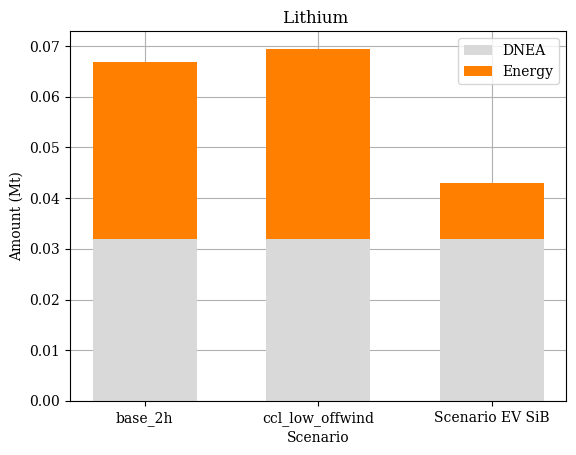

In [ ]:
bar_width = 0.6

base_scenario = sample_base_2h
network_scenarios = [base_scenario, sample_low_offwind]
market_scenarios = ["Scenario EV SiB"]
mineral = "Lithium"

all_scenarios_len = len(network_scenarios) + len(market_scenarios)

DNEA_vals = []
energy_vals = []
all_scenario_names = []

for scenario in network_scenarios: 
    df_merged, totals_Mt = compute_mineral_usage(scenario, n, mineral, "Market share current", mineral_intensities, tech_scenarios)
    totals_Mt_yearly = totals_Mt/24
    energy_vals.append(totals_Mt_yearly)
    all_scenario_names.append(scenario)

for scenario in market_scenarios: 
    df_merged, totals_Mt = compute_mineral_usage(base_scenario, n, mineral, scenario, mineral_intensities, tech_scenarios)
    totals_Mt_yearly = totals_Mt/24
    energy_vals.append(totals_Mt_yearly)
    all_scenario_names.append(scenario)

amounts = {
    "DNEA": np.full(all_scenarios_len, non_energy_demand.loc[mineral]["Value entso-e (Mt)"]), 
    "Energy": np.array(energy_vals)
}

fig, ax = plt.subplots()


bottom = np.zeros(all_scenarios_len)
colors = ["#d9d9d9", "#ff7f00"]
i = 0
for boolean, val in amounts.items():
    p = ax.bar(all_scenario_names, val, bar_width, label=boolean, bottom=bottom, color = colors[i], zorder=2)
    bottom += val
    i +=1

ax.set_ylabel("Amount (Mt)")        # change units/label as needed
ax.set_xlabel("Scenario")              # remove x-label if redundant

ax.set_title(f"{mineral} ")
ax.legend(loc="upper right")
ax.grid(zorder=0)

plt.show()

In [ ]:
network_key = sample_new_2h_2050
time_diff = 24
s1 = "Market share current"
s2 = "Scenario EV SiB"
mineral = "Lithium"
df_merged_s1, totals_Mt_s1 = compute_mineral_usage(network_key, n, mineral, s1, mineral_intensities, tech_scenarios)
df_merged_s2, totals_Mt_s2 = compute_mineral_usage(network_key, n, mineral, s2, mineral_intensities, tech_scenarios)

totals_Mt_yearly_s1 = totals_Mt_s1/time_diff
totals_Mt_yearly_s2 = totals_Mt_s2/time_diff

scenarios_df = pd.DataFrame(dict(market_share_current = totals_Mt_yearly_s1, scenario_ev_sib = totals_Mt_yearly_s2))

# s = expanded_capacities[minerals].sum()   # example Series, index = mineral names
# ax = scenarios_df.plot.bar(figsize=(10,5), color="C0", width = 0.5, label="Energy transition demand")
ax = scenarios_df.T.plot.bar(figsize=(10,5),  color=["#1c5180", "#6390b8" ], width = 0.45, label="Energy transition demand", edgecolor='black', linewidth=1, zorder=3)
ax.set_ylabel("Amount (Mt)")        # change units/label as needed
ax.set_xlabel("Mineral")              # remove x-label if redundant
ax.set_title(f"Mineral use in scenario: {network_key}")

# # read current tick positions & labels from the existing axis `ax`
# positions = ax.get_xticks()
# labels = [t.get_text() for t in ax.get_xticklabels()]

# xs = []
# ys = []

# xs1 = []
# ys1 = []

# xs2 = []
# ys2 = []

# xs6 = []
# ys6 = []
# bottom = []

# for x_pos, lab in zip(positions, labels):
#     if lab in supply_pce.index:
#         xs.append(x_pos)
#         ys.append(supply_pce.loc[lab])
#     if lab in supply_gdp.index:
#         xs1.append(x_pos)
#         ys1.append(supply_gdp.loc[lab])
#     if lab in supply_pc.index:
#         xs2.append(x_pos)
#         ys2.append(supply_pc.loc[lab])

# # ax.bar(xs6, ys6, bottom = bottom, label="Demand from other sectors", color="red", width=0.5)

# # plot points on top of the bars
# ax.scatter(xs1, ys1, color='orange', marker='D', s=80, edgecolor='k', zorder=10, label='GDP share')
# ax.scatter(xs2, ys2, color='blue', marker='D', s=80, edgecolor='k', zorder=10, label='Per capita share')
# ax.scatter(xs, ys, color='C2', marker='D', s=80, edgecolor='k', zorder=10, label='Per capita supply adjusted for current energy use')


# # optional: annotate numeric values
# for x, y in zip(xs, ys):
#     ax.text(x, y, f"{y:.3f}", ha='center', va='bottom', fontsize=8)

# for x, y in zip(xs1, ys1):
#     ax.text(x, y, f"{y:.3f}", ha='center', va='bottom', fontsize=8)

# for x, y in zip(xs2, ys2):
#     ax.text(x, y, f"{y:.3f}", ha='center', va='bottom', fontsize=8)

# # Add legend
# box = ax.get_position()
# ax.set_position([box.x0, box.y0, box.width * 0.8, box.height])

# handles, labels = ax.get_legend_handles_labels()

# # Dummy handles for subtitles
# supply_subtitle = Line2D([], [], linestyle="none", label="Supply estimate method")
# demand_subtitle = Line2D([], [], linestyle="none", label="Demand")

# # Build new legend structure
# new_handles = (
#     [supply_subtitle] +
#     handles[:-2] +          # supply-related items
#     [demand_subtitle] +
#     handles[-2:]            # demand-related items
# )

# new_labels = (
#     ["Supply allocation method"] +
#     labels[:-2] +
#     ["Demand scenario"] +
#     labels[-2:]
# )

# legend = ax.legend(new_handles, new_labels, loc='center left', bbox_to_anchor=(1, 0.5))

# # Style subtitles
# legend_texts = legend.get_texts()
# legend_texts[0].set_weight("bold")   # Supply subtitle
# legend_texts[4].set_weight("bold")   # Demand subtitle (index depends on count)

# ax.grid(zorder=0)





# plt.title(f"Yearly mineral use and projected supply for battery minerals (2050)")


# # plt.legend(loc="upper right")
# plt.tight_layout()

# plt.show()

ValueError: If using all scalar values, you must pass an index

In [120]:
# import matplotlib as mpl
# mpl.rc('font',family='Georgia')

plt.rcParams["font.family"] = "serif"
plt.rcParams["mathtext.fontset"] = "dejavuserif"


In [52]:
totals_Mt_s1

Neodymium       0.078608
Praseodymium    0.013790
Dysprosium      0.007870
dtype: float64

0
[0]
[-0.175]
1
[0]
[0.275]


/var/folders/q9/5t5dtq65121dv3jhymly158h0000gn/T/ipykernel_25798/2643960800.py:21: FutureWarning:

The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.



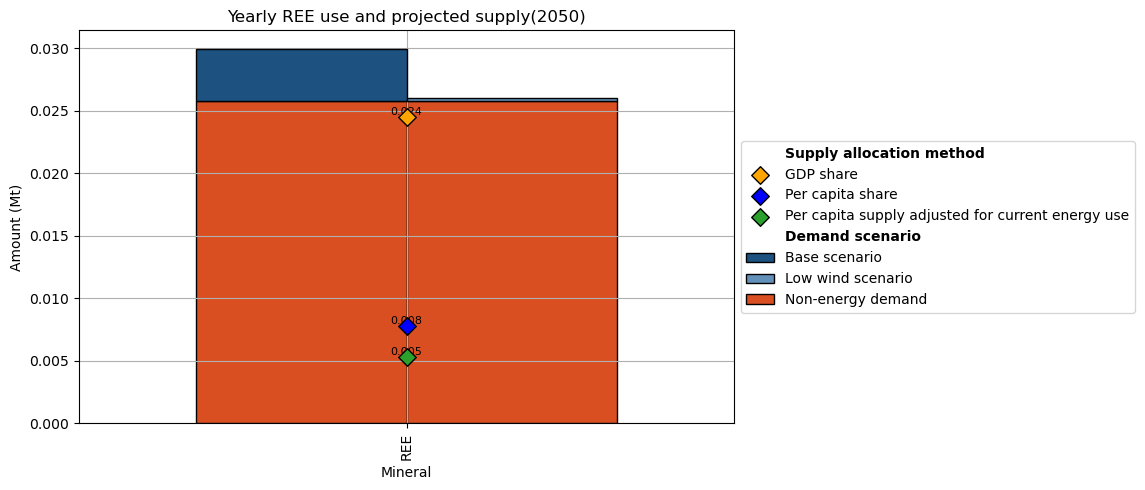

In [ ]:
network_key_s1 = sample_base_2h
network_key_s2 = sample_low_wind
time_diff = 24
s1 = "Market share current"
df_merged_s1, totals_Mt_s1 = compute_mineral_usage(network_key_s1, n, rare_earths, s1, mineral_intensities, tech_scenarios)
df_merged_s2, totals_Mt_s2 = compute_mineral_usage(network_key_s2, n, rare_earths, s1, mineral_intensities, tech_scenarios)


total_REEs_s1 = pd.Series(data = {'REE': totals_Mt_s1.sum()}, index=['REE'])
total_REEs_s2 = pd.Series(data = {'REE': totals_Mt_s2.sum()}, index=['REE'])

total_REEs_yearly_s1 = total_REEs_s1/time_diff
total_REEs_yearly_s2 = total_REEs_s2/time_diff

scenarios_df = pd.DataFrame({'Base scenario':total_REEs_yearly_s1, 'Low wind scenario': total_REEs_yearly_s2})

compare_yearly_minerals(scenarios_df)

0
[0 1 2]
[-0.175  0.825  1.825]
1
[0 1 2]
[0.275 1.275 2.275]


/var/folders/q9/5t5dtq65121dv3jhymly158h0000gn/T/ipykernel_3068/2643960800.py:21: FutureWarning:

The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.



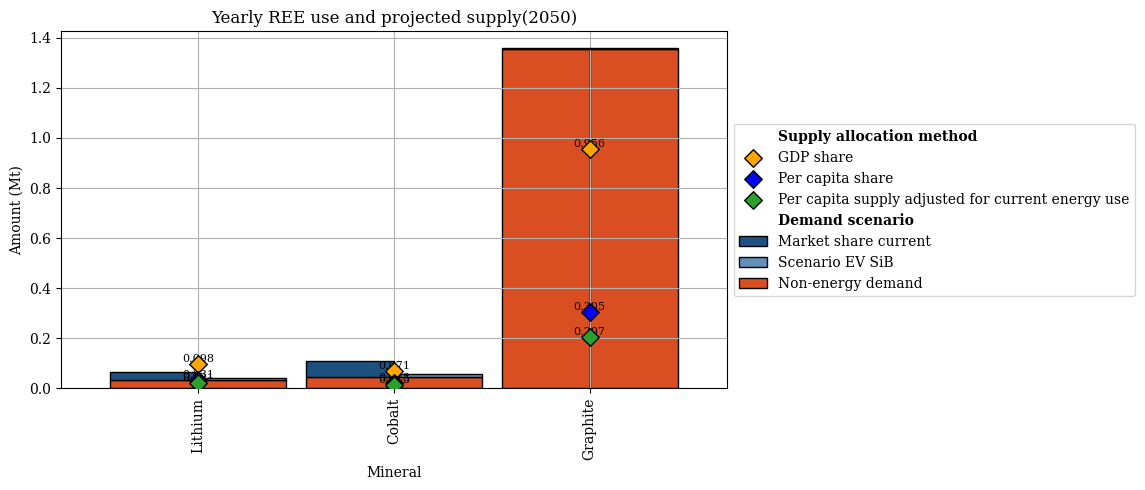

In [32]:
network_key = sample_new_2h_2050
time_diff = 24
s1 = "Market share current"
s2 = "Scenario EV SiB"
df_merged_s1, totals_Mt_s1 = compute_mineral_usage(network_key, n, ["Lithium", "Cobalt", "Graphite"], s1, mineral_intensities, tech_scenarios)
df_merged_s2, totals_Mt_s2 = compute_mineral_usage(network_key, n, ["Lithium", "Cobalt", "Graphite"], s2, mineral_intensities, tech_scenarios)

totals_Mt_yearly_s1 = totals_Mt_s1/time_diff
totals_Mt_yearly_s2 = totals_Mt_s2/time_diff

scenarios_df = pd.DataFrame({s1:totals_Mt_yearly_s1, s2: totals_Mt_yearly_s2})


compare_yearly_minerals(scenarios_df)

In [124]:
supply_pce

Mineral
Copper      1.432578
Cobalt      0.015318
Lithium     0.021206
Nickel      0.203688
Graphite    0.206540
REEs        0.005290
Name: Value (Mt), dtype: float64

### Scenario mineral comparison

In [172]:
comparison_df

,elec_trans_heat_td_no_tes_batt_h2_network_nuclear_no_dacsectors_EU_2040_24h,elec_trans_heat_td_no_tes_batt_h2_EU_2050
Aluminium,88.115227,23.960701
Cobalt,0.048546,0.020439
Copper,22.093709,8.156618
Dysprosium,0.001680,0.001669
Gallium,0.082193,0.021012
Graphite,2.875304,0.726282
Indium,0.000189,0.000097
Lithium,0.010892,0.004243
Manganese,7.194155,4.131562
Neodymium,0.015214,0.013457


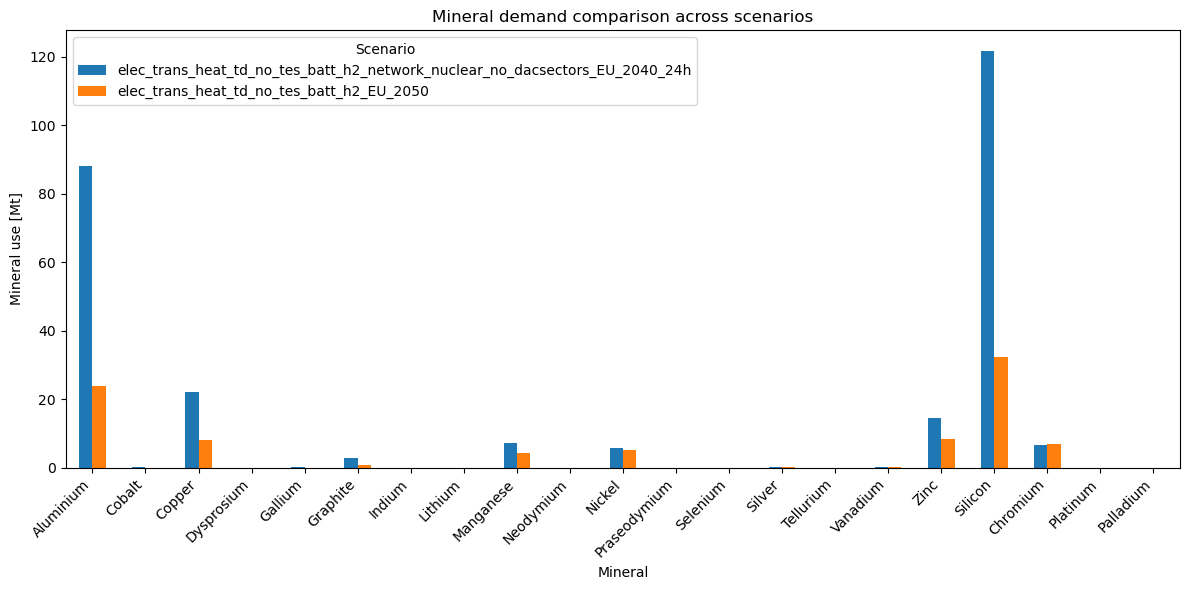

In [171]:
scenarios_to_compare = [sample3, sample_no_sectors]
mineral_data = {}

for scenario_name in scenarios_to_compare:
    expanded_capacities = pd.DataFrame(n[scenario_name].statistics.expanded_capacity().reset_index()).rename(columns={0: 'capacity'})
    
    expanded_capacities["lci_technology"] = expanded_capacities["carrier"].map(techs_map["technology_map"])
    expanded_capacities = pd.merge(expanded_capacities, mineral_intensities, left_on='lci_technology', right_on='Activity', how='inner')
    
    expanded_capacities[minerals] = expanded_capacities[minerals].mul(expanded_capacities.capacity, axis=0)
    
    mineral_data[scenario_name] = expanded_capacities[minerals].sum() / (1000*1000*1000)  # Mt

# Create DataFrame with both scenarios (minerals as rows, scenarios as columns)
comparison_df = pd.DataFrame(mineral_data)

# Plot side-by-side bars
ax = comparison_df.plot.bar(figsize=(12, 6), color=["C0", "C1"])
ax.set_ylabel("Mineral use [Mt]")
ax.set_xlabel("Mineral")
ax.set_title("Mineral demand comparison across scenarios")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Scenario")
plt.tight_layout()
plt.show()

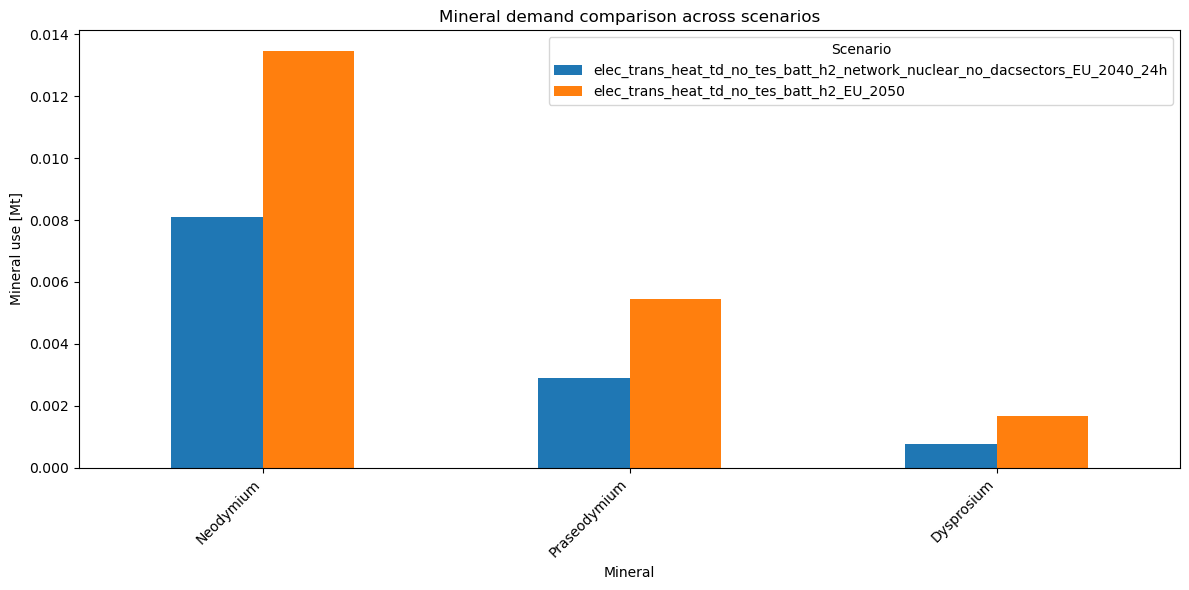

In [164]:
scenarios_to_compare = [sample3, sample_no_sectors]
mineral_data = {}

for scenario_name in scenarios_to_compare:
    expanded_capacities = pd.DataFrame(n[scenario_name].statistics.expanded_capacity().reset_index()).rename(columns={0: 'capacity'})
    
    expanded_capacities["lci_technology"] = expanded_capacities["carrier"].map(techs_map["technology_map"])
    expanded_capacities = pd.merge(expanded_capacities, mineral_intensities, left_on='lci_technology', right_on='Activity', how='inner')
    
    expanded_capacities[rare_earths] = expanded_capacities[rare_earths].mul(expanded_capacities.capacity, axis=0)
    
    mineral_data[scenario_name] = expanded_capacities[rare_earths].sum() / (1000*1000*1000)  # Mt

# Create DataFrame with both scenarios (minerals as rows, scenarios as columns)
comparison_df = pd.DataFrame(mineral_data)

# Plot side-by-side bars
ax = comparison_df.plot.bar(figsize=(12, 6), color=["C0", "C1"])
ax.set_ylabel("Mineral use [Mt]")
ax.set_xlabel("Mineral")
ax.set_title("Mineral demand comparison across scenarios")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Scenario")
plt.tight_layout()
plt.show()

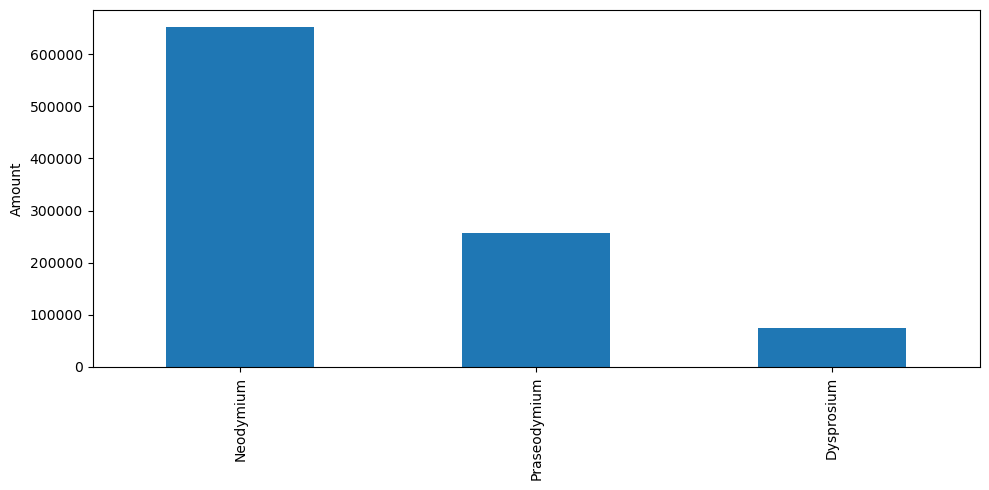

In [ ]:
s = expanded_capacities[rare_earths].sum()  # example Series, index = mineral names
ax = s.plot.bar(figsize=(10,5), color="C0")
ax.set_ylabel("Amount")        # change units/label as needed
ax.set_xlabel("")              # remove x-label if redundant
plt.tight_layout()
plt.show()

In [ ]:
expanded_capacities

,component,carrier,capacity,lci_technology,Activity,database,Friendly name,Activity long,Unit,Multiplier,...,Nickel,Palladium,Platinum,Praseodymium,Selenium,Silicon,Silver,Tellurium,Vanadium,Zinc
0,Generator,Offshore Wind (AC),0.00000,"wind power plant construction, 2MW, offshore, ...","wind power plant construction, 2MW, offshore, ...",ei_cutoff_3.10_image_SSP5-H_2050 2025-10-08,"Wind, offshore, moving parts (Bonus 2 MW)","wind power plant construction, 2MW, offshore, ...",MW,2.000,...,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,-0.000000,0.000000,0.000000e+00
1,Generator,Onshore Wind,0.00000,"wind turbine construction, 4.5MW, onshore","wind turbine construction, 4.5MW, onshore",ei_cutoff_3.10_image_SSP5-H_2050 2025-10-08,"Wind, onshore (Enercon E112)","wind turbine construction, 4.5MW, onshore (GLO)",MW,4.500,...,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,-0.000000,0.000000,0.000000e+00
2,Generator,Solar,0.00000,"photovoltaic plant construction, 570kWp, multi...","photovoltaic plant construction, 570kWp, multi...",ei_cutoff_3.10_image_SSP5-H_2050 2025-10-08,PV plant - multi-Si,"photovoltaic plant construction, 570kWp, multi...",MW,0.570,...,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000e+00
3,Generator,solar rooftop,73380.40552,"photovoltaic slanted-roof installation, 3kWp, ...","photovoltaic slanted-roof installation, 3kWp, ...",ei_cutoff_3.10_image_SSP5-H_2050 2025-10-08,Rooftop PV - single-Si,"photovoltaic slanted-roof installation, 3kWp, ...",MW,0.003,...,3.197127e+07,1152.015423,300.352898,8778.109657,193667.352914,1.285957e+09,1.509781e+06,-384.919339,150380.786201,9.363962e+07


In [ ]:
#

## Cost comparison

In [43]:
def rename_techs(label: str) -> str:
    """
    Rename technology labels for better readability.

    Removes some prefixes and renames if certain conditions defined in function body are met.

    Parameters
    ----------
    label: str
        Technology label to be renamed

    Returns
    -------
    str
        Renamed label
    """
    prefix_to_remove = [
        "residential ",
        "services ",
        "urban ",
        "rural ",
        "central ",
        "decentral ",
    ]

    rename_if_contains = [
        "CHP",
        "gas boiler",
        "biogas",
        "solar thermal",
        "air heat pump",
        "ground heat pump",
        "resistive heater",
        "Fischer-Tropsch",
    ]

    rename_if_contains_dict = {
        "water tanks": "hot water storage",
        "retrofitting": "building retrofitting",
        # "H2 Electrolysis": "hydrogen storage",
        # "H2 Fuel Cell": "hydrogen storage",
        # "H2 pipeline": "hydrogen storage",
        "battery": "battery storage",
        "H2 for industry": "H2 for industry",
        "land transport fuel cell": "land transport fuel cell",
        "land transport oil": "land transport oil",
        "oil shipping": "shipping oil",
        # "CC": "CC"
    }

    rename = {
        "solar": "solar PV",
        "Sabatier": "methanation",
        "offwind": "offshore wind",
        "offwind-ac": "offshore wind (AC)",
        "offwind-dc": "offshore wind (DC)",
        "offwind-float": "offshore wind (Float)",
        "onwind": "onshore wind",
        "ror": "hydroelectricity",
        "hydro": "hydroelectricity",
        "PHS": "hydroelectricity",
        "NH3": "ammonia",
        "co2 Store": "DAC",
        "co2 stored": "CO2 sequestration",
        "AC": "transmission lines",
        "DC": "transmission lines",
        "B2B": "transmission lines",
    }

    for ptr in prefix_to_remove:
        if label[: len(ptr)] == ptr:
            label = label[len(ptr) :]

    for rif in rename_if_contains:
        if rif in label:
            label = rif

    for old, new in rename_if_contains_dict.items():
        if old in label:
            label = new

    for old, new in rename.items():
        if old == label:
            label = new
    return label

In [44]:
def rename_techs_tyndp(tech):
    tech = rename_techs(tech)
    if "heat pump" in tech or "resistive heater" in tech:
        return "power-to-heat"
    elif tech in ["H2 Electrolysis"]:  # , "H2 liquefaction"]:
        return "power-to-hydrogen"
    elif "H2 pipeline" in tech:
        return "H2 pipeline"
    elif tech == "H2":
        return "H2 storage"
    elif tech in ["OCGT", "CHP", "gas boiler", "H2 Fuel Cell"]:
        return "gas-to-power/heat"
    # elif "solar" in tech:
    #    return "solar"
    elif tech in ["Fischer-Tropsch", "methanolisation"]:
        return "power-to-liquid"
    elif "offshore wind" in tech:
        return "offshore wind"
    elif "SMR" in tech:
        return tech.replace("SMR", "steam methane reforming")
    elif "DAC" in tech:
        return "direct air capture"
    elif "CC" in tech or "sequestration" in tech:
        return "carbon capture"
    elif tech == "oil" or tech == "gas":
        return "fossil oil and gas"
    else:
        return tech


In [45]:
def rename_techs_carbon_balances(tech):
    prefix_to_remove = [
        "residential ",
        "services ",
        "urban ",
        "rural ",
        "central ",
        "decentral ",
    ]
    for ptr in prefix_to_remove:
        if tech[: len(ptr)] == ptr:
            tech = tech[len(ptr) :]
    if tech == "biogas to gas":
        return "biogas upgrading"
    elif tech == "agriculture machinery oil emissions":
        return "agriculture machinery"
    elif tech == "shipping methanol emissions":
        return "shipping fuels"
    elif tech == "DAC":
        return "direct air capture"
    elif "SMR" in tech:
        return tech.replace("SMR", "steam methane reforming")
    else:
        return tech

In [46]:
def rename_techs_tyndp(tech):
    tech = rename_techs(tech)
    if "heat pump" in tech or "resistive heater" in tech:
        return "power-to-heat"
    elif tech in ["H2 Electrolysis"]:  # , "H2 liquefaction"]:
        return "power-to-hydrogen"
    elif "H2 pipeline" in tech:
        return "H2 pipeline"
    elif tech == "H2":
        return "H2 storage"
    elif tech in ["OCGT", "CHP", "gas boiler", "H2 Fuel Cell"]:
        return "gas-to-power/heat"
    # elif "solar" in tech:
    #    return "solar"
    elif tech in ["Fischer-Tropsch", "methanolisation"]:
        return "power-to-liquid"
    elif "offshore wind" in tech:
        return "offshore wind"
    elif "SMR" in tech:
        return tech.replace("SMR", "steam methane reforming")
    elif "DAC" in tech:
        return "direct air capture"
    elif "CC" in tech or "sequestration" in tech:
        return "carbon capture"
    elif tech == "oil" or tech == "gas":
        return "fossil oil and gas"
    elif tech in ["HVC to air", 
    "agriculture machinery oil", 
    "naphtha for industry", 
    "non-sequestered HVC", 
    "co2", 
    "process emissions", 
    "solid biomass for industry", 
    "gas for industry",
    "industry methanol", 
    "solar thermal", 
    "oil refining", 
    "kerosene for aviation", 
    "shipping methanol"]: 
        return "other"
    else:
        return tech



In [ ]:
sc = n[sample_base_2h].statistics.system_cost().droplevel(level=0)

sc = sc.groupby(rename_techs_tyndp).sum()



In [ ]:
sc.sort_values()

carrier
HVC to air                       1.680000e-03
co2                              3.766800e-01
process emissions                3.488960e+00
solid biomass for industry       9.967970e+00
gas for industry                 3.923059e+01
industry methanol                8.687983e+04
agriculture machinery oil        4.884027e+05
non-sequestered HVC              1.075082e+06
naphtha for industry             2.779628e+06
oil refining                     2.809194e+06
solar thermal                    3.159404e+06
shipping methanol                4.897285e+06
kerosene for aviation            8.100342e+06
BEV charger                      1.086434e+07
methanol                         4.473484e+08
H2 Store                         1.581970e+09
H2 pipeline                      2.102639e+09
battery storage                  6.830146e+09
direct air capture               7.371386e+09
co2 sequestered                  7.525254e+09
solar rooftop                    9.499011e+09
Pumped Hydro Storage      

In [ ]:
["HVC to air", 
 "agriculture machinery oil", 
 "naphtha for industry", 
 "non-sequestered HVC", 
 "co2", 
 "process emissions", 
 "solid biomass for industry", 
 "gas for industry",
 "industry methanol"]

['HVC to air',
 'agriculture machinery oil',
 'naphtha for industry',
 'non-sequestered HVC']

System cost of base_2h: 822585089124.9075
System cost of ccl_low_wind: 914596216361.0048
System cost of ccl_high_offwind: 829759558593.2664
System cost of ccl_low_offwind: 830123067765.8983
System cost of ccl_high_nuclear: 860723217103.7133


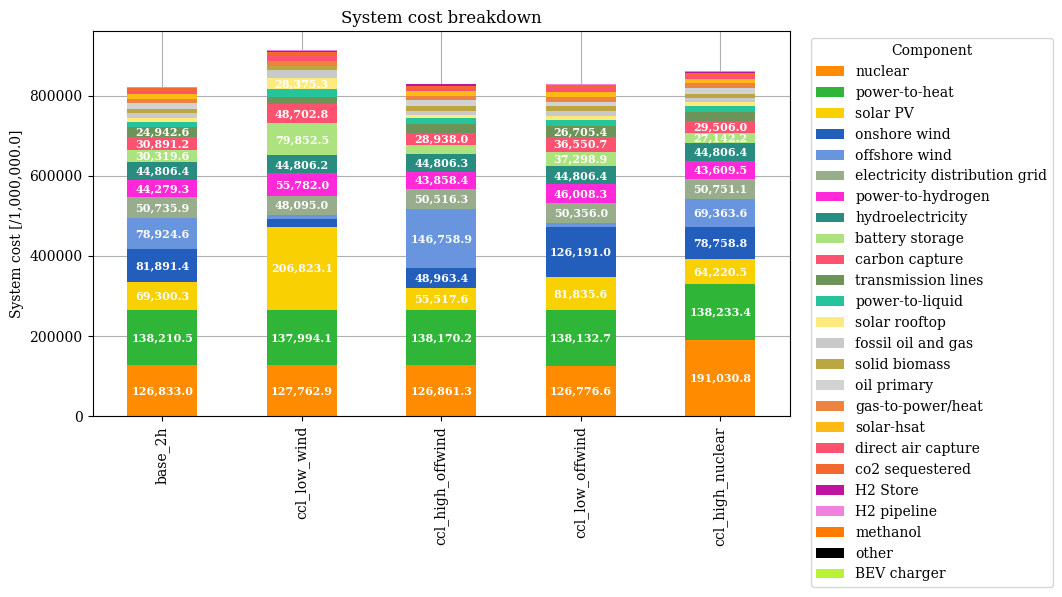

In [56]:
network_keys = [sample_base_2h, sample_low_wind, sample_high_offwind, sample_low_offwind, sample_high_nuclear] 
for network in network_keys: 
    print(f"System cost of {network}: {n[network].statistics.system_cost().sum()}") 
ax, shown_df = plot_system_cost_compare(n, network_keys, cost_divisor=1e6, figsize=(9,5))

/var/folders/q9/5t5dtq65121dv3jhymly158h0000gn/T/ipykernel_3068/1887214051.py:62: UserWarning:

Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.



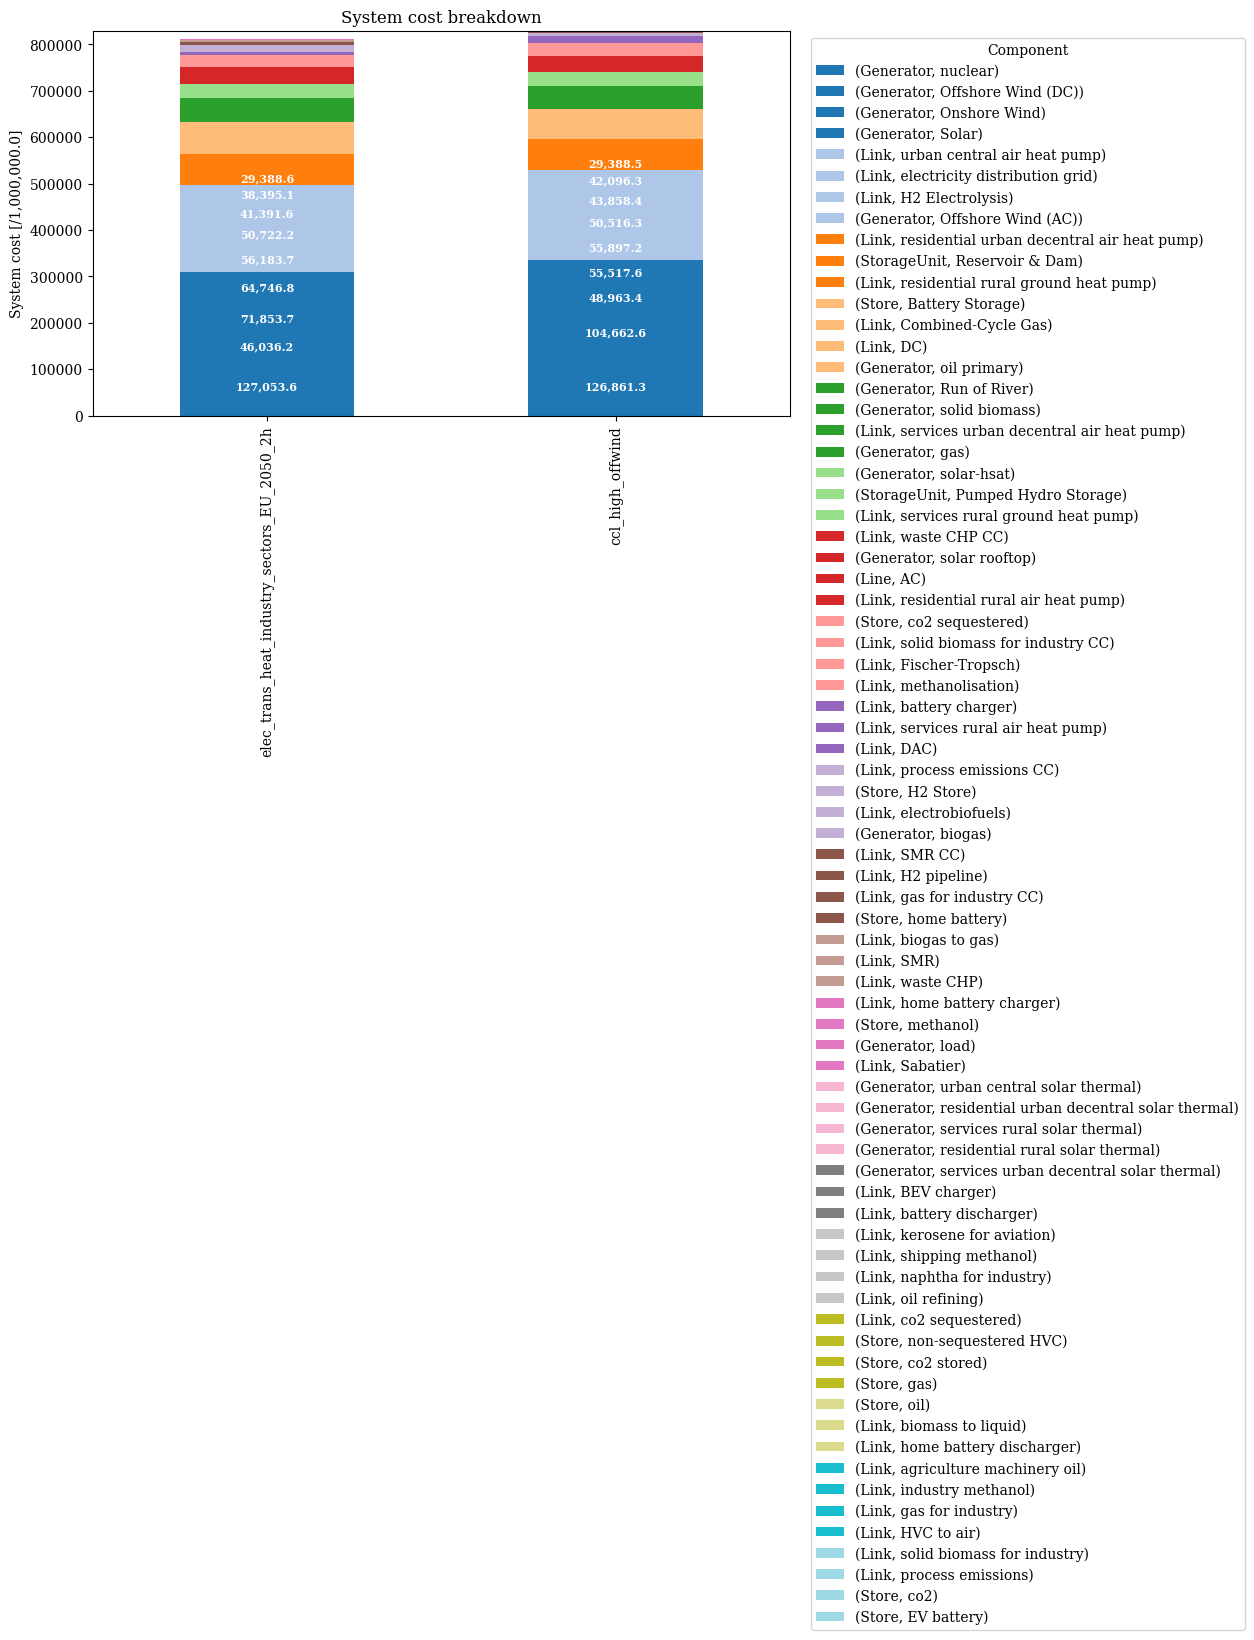

In [38]:
network_keys = [sample_new_2h_2050, sample_high_offwind]  # replace with your actual keys in `n`
ax, shown_df = plot_system_cost_compare(n, network_keys, cost_divisor=1e6, figsize=(9,5))

In [183]:
pd.set_option('display.max_rows', 75)
n[sample_new_2h_2050].statistics.system_cost()

component    carrier                                  
Generator    Offshore Wind (AC)                           3.839510e+10
             Offshore Wind (DC)                           4.603617e+10
             Onshore Wind                                 7.185367e+10
             Run of River                                 1.512337e+10
             Solar                                        6.474676e+10
             biogas                                       4.574333e+09
             gas                                          1.040611e+10
             load                                         4.411202e+08
             nuclear                                      1.270536e+11
             oil primary                                  1.508066e+10
             residential rural solar thermal              2.628866e+07
             residential urban decentral solar thermal    2.818839e+07
             services rural solar thermal                 2.651957e+07
             services 

In [184]:
n[sample_low_wind_no_ls].statistics.system_cost()

component    carrier                                  
Generator    Offshore Wind (AC)                           9.073600e+09
             Onshore Wind                                 2.048034e+10
             Run of River                                 1.512337e+10
             Solar                                        2.068233e+11
             gas                                          1.949798e+10
             nuclear                                      1.277668e+11
             oil primary                                  2.006104e+06
             residential rural solar thermal              8.332193e+05
             residential urban decentral solar thermal    8.135081e+05
             services rural solar thermal                 8.335392e+05
             services urban decentral solar thermal       8.668180e+05
             solar rooftop                                2.837533e+10
             solar-hsat                                   1.084471e+09
             solid bio

In [167]:
n[sample_low_wind].generators.groupby('carrier')[['p_nom_opt']].sum()

,p_nom_opt
carrier,
biogas,3.473237e+08
gas,2.965290e+04
load,inf
nuclear,3.439134e+05
offwind-ac,4.782060e+04
offwind-dc,0.000000e+00
oil primary,1.489976e-01
onwind,2.174735e+05
residential rural solar thermal,2.942177e+03


In [166]:
n[sample_new_2h_2050].generators.groupby('carrier')[['p_nom_opt']].sum()

,p_nom_opt
carrier,
biogas,3.473237e+08
gas,3.867363e+05
load,inf
nuclear,1.544214e+05
offwind-ac,2.021605e+05
offwind-dc,2.091037e+05
oil primary,9.306628e+04
onwind,7.628180e+05
residential rural solar thermal,9.660091e+02


## BEV manual calculation

from transport_data file 

number_cars = 292030477.6



Notes 

IEA says in 2023 there were 40 million EVs on the road globally

In 2023, there was an average of approximately 0.55 to 0.57 passenger cars per inhabitant in the EU, or roughly 560–574 cars per 1,000 people. While the overall trend shows increasing car ownership, regional rates differ significantly, with Italy, Luxembourg, and Finland leading in density. 

Chatgpt says: For typical electric passenger cars, battery sizes are usually: ~0.04–0.10 MWh

In [ ]:
# from transport_data file 
# e_nom = (
#     number_cars
#     * options["bev_energy"]
#     * options["bev_dsm_availability"]
#     * electric_share
# )

# from resources/transport_data_s_{clusters}.csv 
number_cars = 292030477.6

# from config file
#   land_transport_electric_share:
#     2020: 0
#     2025: 0.05
#     2030: 0.2
#     2035: 0.45
#     2040: 0.7
#     2045: 0.85
#     2050: 1
electric_share = 1
bev_energy = 0.05
bev_dsm_availability = 0.5

e_nom_mwh = number_cars * electric_share * bev_energy * bev_dsm_availability
e_nom_mwh


7300761.940000001

In [223]:
minerals = ['Aluminium', 'Chromium', 'Cobalt', 'Copper',
       'Dysprosium', 'Gallium', 'Germanium', 'Graphite', 'Indium', 'Iridium',
       'Lithium', 'Manganese', 'Neodymium', 'Nickel', 'Palladium', 'Platinum',
       'Praseodymium', 'Selenium', 'Silicon', 'Silver', 'Tellurium',
       'Vanadium', 'Zinc']

merged = tech_scenarios.merge(mineral_intensities, how="left", left_on="LCI name", right_on="Activity")
merged[minerals] = merged[minerals].multiply(merged['Market share current'], axis="index")
merged_evs = merged[merged["PyPSA technology"] == "EV battery"]
merged_evs[minerals] = merged_evs[minerals] * e_nom_mwh

/var/folders/q9/5t5dtq65121dv3jhymly158h0000gn/T/ipykernel_3126/9143011.py:10: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [230]:
merged_evs

,PyPSA technology,Sub-technology,LCI name,Market share current,Scenario EV NMC 811,Scenario EV SiB,Activity,database,Friendly name,Activity long,...,Nickel,Palladium,Platinum,Praseodymium,Selenium,Silicon,Silver,Tellurium,Vanadium,Zinc
27,EV battery,NMC111,"market for battery capacity, Li-ion, NMC111",0.07,0.03,0.00,"market for battery capacity, Li-ion, NMC111",ei_cutoff_3.10_tiam-ucl_SSP2-RCP19_2040 2025-1...,Market for NMC111,"market for battery capacity, Li-ion, NMC111 (GLO)",...,1.442391e+08,4416.602141,254.430970,36040.680683,189.128063,7.441112e+05,3.991461e+05,-357.324915,101396.387482,8.592976e+07
28,EV battery,NMC532,"market for battery capacity, Li-ion, NMC532",0.20,0.00,0.00,"market for battery capacity, Li-ion, NMC532",ei_cutoff_3.10_tiam-ucl_SSP2-RCP19_2040 2025-1...,Market for NMC532,"market for battery capacity, Li-ion, NMC532 (GLO)",...,3.981905e+08,8861.149409,530.089342,81968.736682,381.164020,1.943613e+06,8.046432e+05,-853.148058,209386.813219,1.735958e+08
29,EV battery,NMC622,"market for battery capacity, Li-ion, NMC622",0.30,0.17,0.07,"market for battery capacity, Li-ion, NMC622",ei_cutoff_3.10_tiam-ucl_SSP2-RCP19_2040 2025-1...,Market for NMC622,"market for battery capacity, Li-ion, NMC622 (GLO)",...,7.716457e+08,14441.131981,833.300937,130931.928149,619.129435,3.655667e+06,1.298151e+06,-1509.882258,325839.206649,2.730044e+08
30,EV battery,NMC811,"market for battery capacity, Li-ion, NMC811",0.15,0.60,0.50,"market for battery capacity, Li-ion, NMC811",ei_cutoff_3.10_tiam-ucl_SSP2-RCP19_2040 2025-1...,Market for NMC811,"market for battery capacity, Li-ion, NMC811 (GLO)",...,3.668314e+08,5985.810391,335.552875,50985.576627,253.996428,1.711587e+06,5.377059e+05,-519.298816,132238.656850,1.076314e+08
31,EV battery,LFP,"market for battery capacity, Li-ion, LFP",0.08,0.10,0.10,"market for battery capacity, Li-ion, LFP",ei_cutoff_3.10_tiam-ucl_SSP2-RCP19_2040 2025-1...,Market for LFP,"market for battery capacity, Li-ion, LFP (GLO)",...,2.618933e+07,4417.245995,215.611358,54110.966741,187.814145,2.676502e+05,3.881593e+05,-575.437295,83671.010079,7.617887e+07
32,EV battery,NCA,"market for battery capacity, Li-ion, NCA",0.20,0.10,0.03,"market for battery capacity, Li-ion, NCA",ei_cutoff_3.10_tiam-ucl_SSP2-RCP19_2040 2025-1...,Market for NCA,"market for battery capacity, Li-ion, NCA (GLO)",...,4.923623e+08,8374.276197,469.988010,61863.016520,353.920497,2.309613e+06,7.512595e+05,-757.343080,180482.308217,1.497246e+08
33,EV battery,SiB,"market for battery capacity, Sodium-ion, SiB",0.00,0.00,0.30,"market for battery capacity, Sodium-ion, SiB",ei_cutoff_3.10_tiam-ucl_SSP2-RCP19_2040 2025-1...,Market for SiB,"market for battery capacity, Sodium-ion, SiB (...",...,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000e+00


In [ ]:
# cumulative mass in Mt
merged_evs[minerals].sum()/1000000000

Aluminium       9.108756e+03
Chromium        6.851476e-01
Cobalt          1.308452e+03
Copper          8.640876e+03
Dysprosium      8.514594e-03
Gallium         1.061314e-01
Germanium       3.323672e-06
Graphite        1.847388e+01
Indium          1.597407e-05
Iridium         1.522282e-07
Lithium         5.754123e+02
Manganese       1.630618e+03
Neodymium       1.396617e+00
Nickel          2.199458e+03
Palladium       4.649622e-02
Platinum        2.638973e-03
Praseodymium    4.159009e-01
Selenium        1.985153e-03
Silicon         1.063224e+01
Silver          4.179065e+00
Tellurium      -4.572434e-03
Vanadium        1.033014e+00
Zinc            8.660649e+02
dtype: float64

In [ ]:
1.308452e+03/24

# 54 mt yearly is still too much -- and doesn't match with above

54.51883333333333

In [229]:
5.754123e+02/24

23.975512499999997